# **Présentation du dataset**

Le dataset utilisé pour l’analyse provient de la **NASA** et est intitulé *cumulative.csv*.
Il est disponible sur Kaggle :
[https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results](https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results)

Il contient **9 564 observations** issues du télescope spatial **Kepler**, chacune décrivant un objet d’intérêt exoplanétaire (*Kepler Object of Interest*, KOI).

# **Dictionnaire des données**

Pour chaque objet d'intérêt détecté par le télescope spatial Kepler, nous disposons de 50 variables de nature orbitale, métadonnée, physique et stellaire.


1. **Métadonnées générales**

| Colonne                                 | Type   | Description                                                |
| --------------------------------------- | ------ | ---------------------------------------------------------- |
| <a id="rowid"></a>**rowid**             | int64  | Identifiant interne unique pour chaque entrée.             |
| <a id="kepid"></a>**kepid**             | int64  | Identifiant Kepler de l’étoile hôte.                       |
| <a id="kepoi_name"></a>**kepoi_name**   | string | Nom de l’objet Kepler (KOI – *Kepler Object of Interest*). |
| <a id="kepler_name"></a>**kepler_name** | string | Nom officiel de la planète si confirmée.                   |


2. **Disposition et statut des candidats**

| Colonne                                           | Type    | Description                                                |
| ------------------------------------------------- | ------- | ---------------------------------------------------------- |
| <a id="koi_disposition"></a>**koi_disposition**   | string  | Statut final : *CONFIRMED*, *FALSE POSITIVE*, *CANDIDATE*. |
| <a id="koi_pdisposition"></a>**koi_pdisposition** | string  | Statut provisoire attribué par le pipeline.                |
| <a id="koi_score"></a>**koi_score**               | float64 | Score de probabilité d’être une planète.                   |
| <a id="koi_fpflag_nt"></a>**koi_fpflag_nt**       | int64   | Faux positif : transit non planétaire.                     |
| <a id="koi_fpflag_ss"></a>**koi_fpflag_ss**       | int64   | Faux positif : variabilité stellaire.                      |
| <a id="koi_fpflag_co"></a>**koi_fpflag_co**       | int64   | Faux positif : contamination.                              |
| <a id="koi_fpflag_ec"></a>**koi_fpflag_ec**       | int64   | Faux positif : éclipse binaire.                            |


3. **Caractéristiques orbitales**

Toutes les valeurs `err1` et `err2` correspondent aux erreurs supérieure et inférieure.

| Colonne                                   | Type    | Description                    |
| ----------------------------------------- | ------- | ------------------------------ |
| <a id="koi_period"></a>**koi_period**     | float64 | Période orbitale (jours).      |
| <a id="koi_time0bk"></a>**koi_time0bk**   | float64 | Époque du transit.             |
| <a id="koi_impact"></a>**koi_impact**     | float64 | Paramètre d’impact du transit. |
| <a id="koi_duration"></a>**koi_duration** | float64 | Durée du transit (heures).     |
| <a id="koi_depth"></a>**koi_depth**       | float64 | Profondeur du transit (ppm).   |


4. **Propriétés physiques de la planète**

| Colonne                                             | Type    | Description                                          |
| --------------------------------------------------- | ------- | ---------------------------------------------------- |
| <a id="koi_prad"></a>**koi_prad**                   | float64 | Rayon planétaire (en rayons terrestres).             |
| <a id="koi_teq"></a>**koi_teq**                     | float64 | Température d’équilibre (K).                         |
| <a id="koi_insol"></a>**koi_insol**                 | float64 | Flux incident (en unités de flux terrestre).         |
| <a id="koi_model_snr"></a>**koi_model_snr**         | float64 | Rapport signal/bruit du modèle.                      |
| <a id="koi_tce_plnt_num"></a>**koi_tce_plnt_num**   | float64 | Index de la planète dans le système.                 |
| <a id="koi_tce_delivname"></a>**koi_tce_delivname** | string  | Version du livrable TCE (*Transit Candidate Event*). |


5. **Paramètres stellaires de l’étoile hôte**

| Colonne                             | Type    | Description                            |
| ----------------------------------- | ------- | -------------------------------------- |
| <a id="koi_steff"></a>**koi_steff** | float64 | Température effective de l’étoile (K). |
| <a id="koi_slogg"></a>**koi_slogg** | float64 | Gravité de surface (log g).            |
| <a id="koi_srad"></a>**koi_srad**   | float64 | Rayon stellaire (en rayons solaires).  |


6. **Coordonnées et magnitude**

| Colonne                               | Type    | Description                   |
| ------------------------------------- | ------- | ----------------------------- |
| <a id="ra"></a>**ra**                 | float64 | Ascension droite (degrés).    |
| <a id="dec"></a>**dec**               | float64 | Déclinaison (degrés).         |
| <a id="koi_kepmag"></a>**koi_kepmag** | float64 | Magnitude Kepler de l’étoile. |

## **Répartition des exoplanètes selon leur statut**

Avant d’examiner en détail les caractéristiques orbitales, stellaires et physiques des objets détectés par Kepler, il est essentiel de comprendre comment se répartissent les observations dans le dataset.  
La variable [`koi_disposition`](#koi_disposition) indique le statut final attribué à chaque objet d’intérêt par les équipes de validation de la NASA :

- **CONFIRMED** : objets dont la nature planétaire est confirmée par des observations supplémentaires.  
- **CANDIDATE** : objets présentant une signature compatible avec une planète, mais dont la confirmation est encore en attente.  
- **FALSE POSITIVE** : détections initiales finalement attribuées à d’autres phénomènes astrophysiques (éclipses binaires, variabilité stellaire, artefacts instrumentaux…).

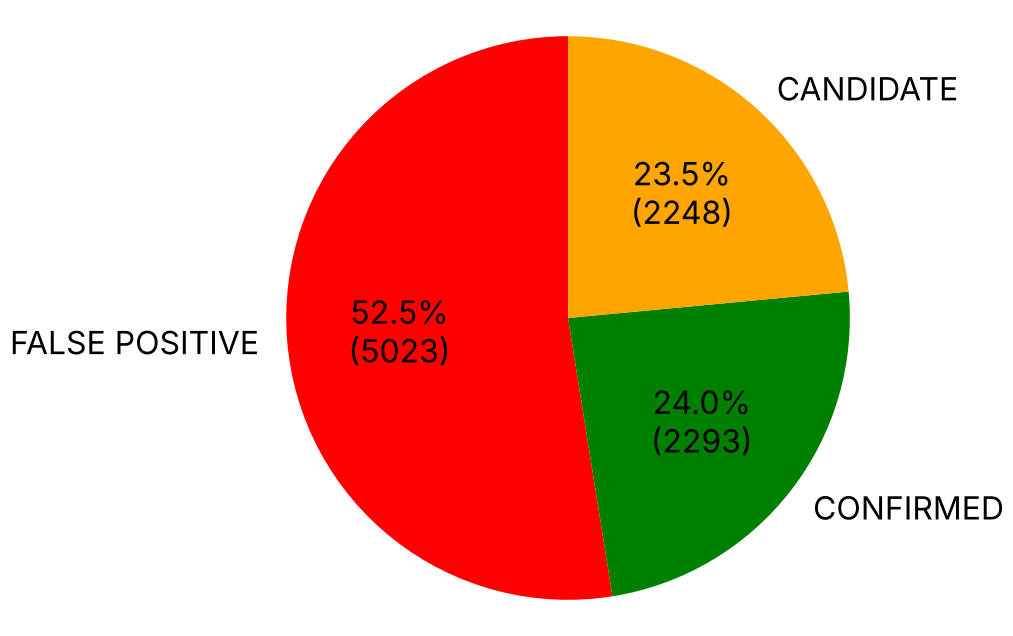

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/cumulative.csv')

counts = df['koi_disposition'].value_counts()

colors = ['red', 'green', 'orange']

plt.figure(figsize=(8, 8))
plt.pie(
    counts.values, 
    labels=counts.index, 
    autopct=lambda p: f'{p:.1f}%\n({round(p/100*counts.sum())})',
    startangle=90,
    colors=colors, 
    textprops={'fontsize': 23},
    wedgeprops={'edgecolor': 'white', 'linewidth': 0}
)
#Répartition des exoplanètes parmi les 9564 observations
#koi_distrib
plt.title("", fontsize=14, pad=20, loc='center')
plt.axis('equal')
plt.show()

La distribution est dominée par les **FALSE POSITIVE**, qui représentent 52.5 % des observations (5 022 entrées). Cette asymétrie indique que plus de la moitié des détections initiales ne correspondent pas à des signaux planétaires authentiques, ce qui souligne l’importance d’un prétraitement rigoureux avant toute approche supervisée.

Les **CANDIDATE** constituent 23.5 % du dataset (2 248 observations), formant un sous-ensemble intermédiaire dont l’incertitude est élevée et qui pourrait introduire de la variance dans les modèles de classification.

Les **CONFIRMED**, avec 24.0 % (2 293 observations), représentent la classe positive la plus fiable et servent de référence pour l’interprétation physique des signaux de transit.

Cette répartition fortement déséquilibrée entre classes devra être prise en compte dans les analyses ultérieures.


## **Analyse des distributions des variables par statut**

Afin d’examiner les différences structurelles entre les classes *CONFIRMED*, *CANDIDATE* et *FALSE POSITIVE*, nous analysons la distribution de plusieurs variables clés à l’aide d’estimations de densité (KDE).  
Cette approche permet d’évaluer la forme statistique des variables continues (asymétrie, dispersion, valeurs extrêmes) tout en comparant visuellement les profils des trois groupes.  
L’objectif est d’identifier d’éventuelles séparations naturelles entre classes, utiles aussi bien pour l’interprétation astrophysique que pour la construction de futurs modèles prédictifs.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

colors_dict = {
    'CONFIRMED': 'green',
    'CANDIDATE': 'orange',
    'FALSE POSITIVE': 'red'
}

def plot_distributions(df, columns, title, log_scale=False):
    n_cols = 2
    n_rows = (len(columns) + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() 
    
    fig.suptitle(title, fontsize=20, y=1.02)

    for i, col in enumerate(columns):
        ax = axes[i]
        has_plot = False

        print(f"Traitement de {col}...")

        for status, color in colors_dict.items():

            subset = df[df['koi_disposition'] == status][col]
            
            subset = subset.replace([np.inf, -np.inf], np.nan).dropna()

            if log_scale:
                subset = subset[subset > 0]
            
            if len(subset) > 1 and subset.nunique() > 1:
                sns.kdeplot(
                    x=subset, 
                    fill=True, 
                    alpha=0.3, 
                    color=color, 
                    ax=ax, 
                    label=status,
                    log_scale=log_scale, 
                    warn_singular=False
                )
                has_plot = True
        
        ax.set_title(f"Distribution : {col}")
        ax.set_xlabel(col)
        
        if has_plot:
            ax.legend(loc='upper right')
        else:
            ax.text(0.5, 0.5, "Données insuffisantes ou nulles", 
                    ha='center', va='center', transform=ax.transAxes, color='red')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Les graphiques de densité (KDE) ci-dessous mettent en évidence des différences fondamentales entre les planètes confirmées et les faux positifs.

*   **Période et Durée :**
    La variable [`koi_disposition`](#koi_disposition) montre que les planètes confirmées (courbe verte) se concentrent davantage sur des périodes orbitales courtes à moyennes. Les faux positifs présentent une distribution plus étalée, incluant des périodes très longues qui correspondent souvent à des éclipses binaires ou des variations stellaires lentes.
    De même, la [`koi_duration`](#koi_duration) présente un pic très net pour les planètes confirmées, suggérant une cohérence dans les temps de transit des objets planétaires réels, contrairement aux faux positifs qui sont plus dispersés.

*   **Profondeur et Rayon (Discriminants forts) :**
    C'est ici que la distinction est la plus marquante.
    *   [`koi_depth`](#koi_duration) : Les faux positifs dominent les grandes profondeurs de transit. Un transit très profond indique souvent un objet massif (comme une autre étoile éclipsant l'étoile hôte) plutôt qu'une planète.
    *   [`koi_prad`](#koi_duration) (Rayon planétaire) : La distribution des objets **CONFIRMED** est très piquée vers les petites valeurs (taille Terre ou Neptune). À l'inverse, la courbe rouge (**FALSE POSITIVE**) s'étend vers des rayons gigantesques (> 10-20 rayons terrestres), physiquement impossibles pour des planètes rocheuses ou gazeuses classiques, trahissant la présence d'étoiles compagnes.

Traitement de koi_period...
Traitement de koi_duration...
Traitement de koi_depth...


Traitement de koi_prad...
Traitement de koi_insol...


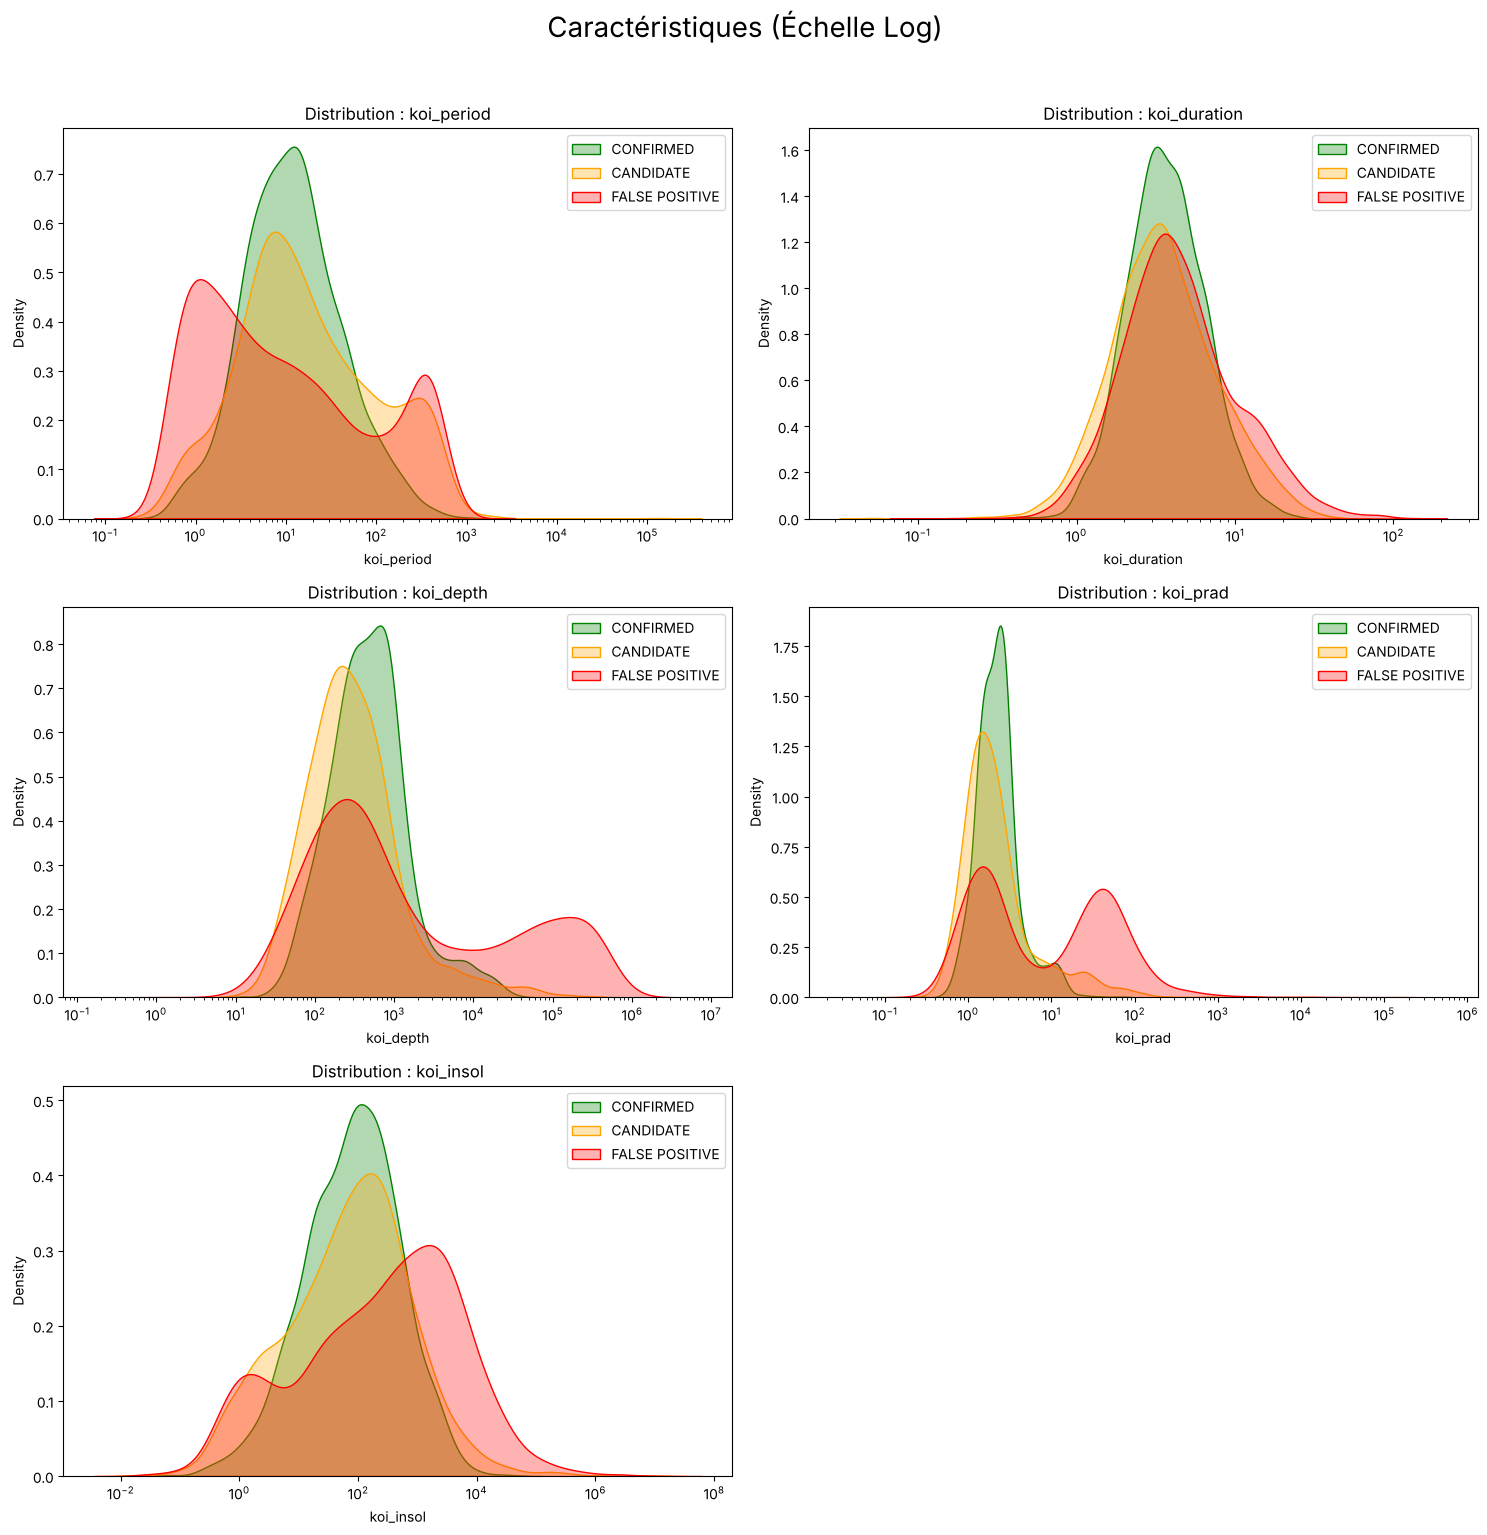

Traitement de koi_time0bk...
Traitement de koi_impact...


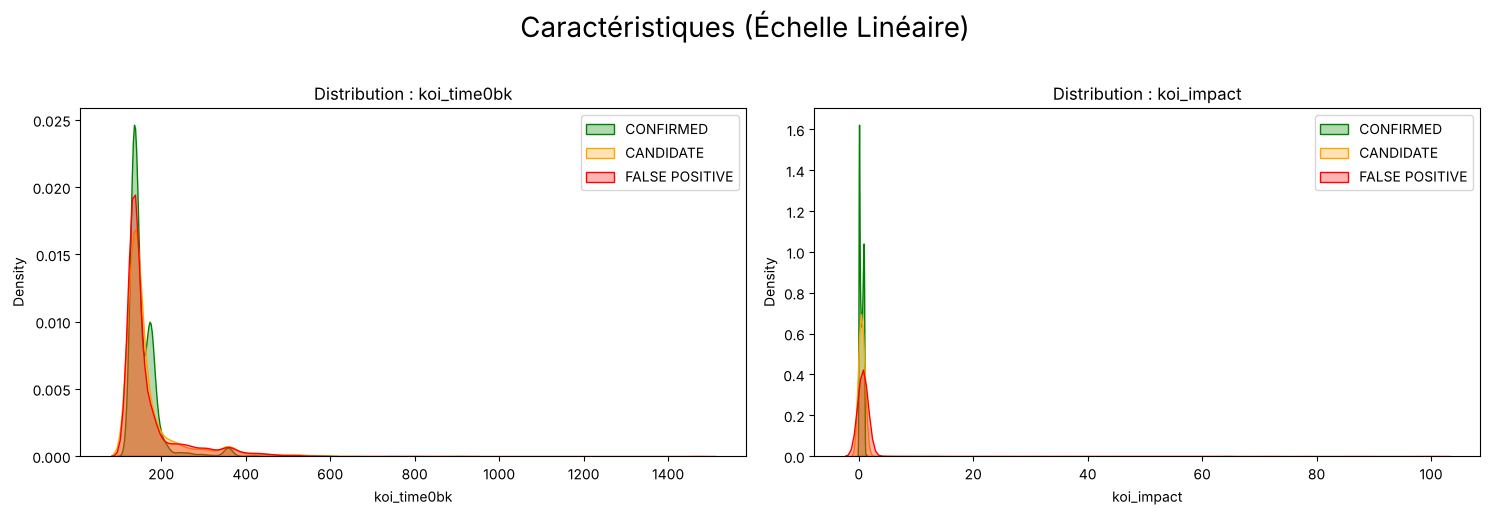

In [3]:
vars_log = [
    'koi_period',   
    'koi_duration', 
    'koi_depth',    
    'koi_prad',     
    'koi_insol'     
]

plot_distributions(df, vars_log, title="Caractéristiques (Échelle Log)", log_scale=True)

vars_linear = [
    'koi_time0bk',
    'koi_impact' 
]

plot_distributions(df, vars_linear, title="Caractéristiques (Échelle Linéaire)", log_scale=False)

L'analyse des propriétés stellaires permet de vérifier si certains types d'étoiles génèrent plus de faux positifs.

*   **Température et Gravité :**
    Les distributions de [`koi_steff`](#koi_steff) (Température) et [`koi_slogg`](#koi_slogg) (Gravité de surface) sont assez similaires entre les trois classes. Cela indique que le télescope Kepler a ciblé une population d'étoiles relativement homogène (principalement de la séquence principale, type solaire).
    Cependant, on note que les **CANDIDATE** et **CONFIRMED** suivent très fidèlement la distribution principale, tandis que les **FALSE POSITIVE** montrent de légers décrochages aux extrêmes, correspondant potentiellement à des étoiles géantes ou très froides où les mesures sont plus bruyantes.

Traitement de koi_steff...
Traitement de koi_slogg...
Traitement de koi_srad...


Traitement de koi_kepmag...


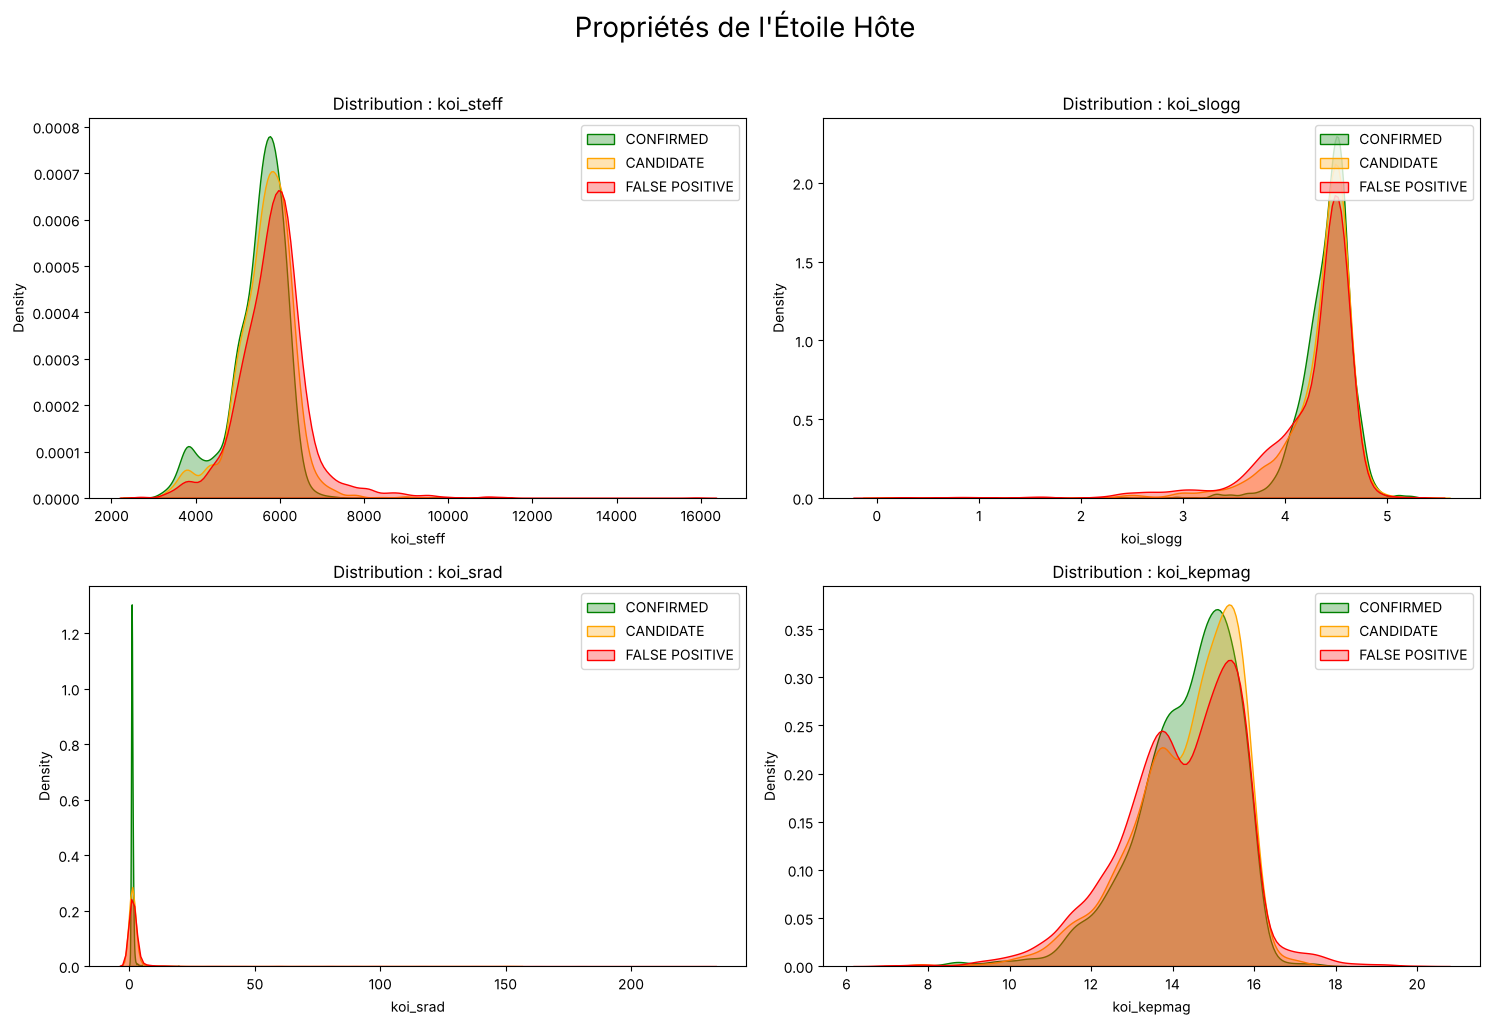

In [4]:
stellar_features = [
    'koi_steff',  # Température de l'étoile
    'koi_slogg',  # Gravité de surface
    'koi_srad',   # Rayon de l'étoile
    'koi_kepmag'  # Magnitude
]

plot_distributions(df, stellar_features, title="Propriétés de l'Étoile Hôte", log_scale=False)

## **Analyse des Flags de Faux Positifs**

Cette étape est cruciale pour la compréhension de la structure du jeu de données. Le dataset intègre quatre indicateurs binaires (« flags ») générés automatiquement par le pipeline de traitement du signal de la NASA.

L'analyse des distributions révèle une discrimination quasi absolue entre les classes :
*   **Séparation stricte :** Pour les variables [`koi_fpflag_nt`](#koi_fpflag_nt), [`koi_fpflag_ss`](#koi_fpflag_ss), [`koi_fpflag_co`](#koi_fpflag_co) et [`koi_fpflag_ec`](#koi_fpflag_ec), l'activation du flag (valeur **1**) est presque exclusivement associée à la classe **FALSE POSITIVE**.
*   **Profil des objets validés :** Les objets **CONFIRMED** (en vert) présentent systématiquement une valeur de **0** pour l'ensemble de ces quatre indicateurs.

Cette corrélation s'explique par la nature physique de ces variables, qui agissent comme des **critères techniques d'exclusion** lors de la validation :
*   **[`koi_fpflag_ss`](#koi_fpflag_ss) (Stellar Secondary) :** Indique la présence d'une éclipse secondaire, preuve que l'objet émet sa propre lumière (système binaire) et ne peut donc pas être une planète.
*   **[`koi_fpflag_co`](#koi_fpflag_co) (Centroid Offset) :** Signale un déplacement de la source lumineuse sur le capteur, caractéristique d'une contamination par une étoile d'arrière-plan.
*   **[`koi_fpflag_ec`](#koi_fpflag_ec) et [`koi_fpflag_nt`](#koi_fpflag_nt) :** Identifient respectivement une corrélation avec un objet variable voisin connu ou une morphologie de signal incohérente avec un transit.

D'un point de vue méthodologique, ces indicateurs constituent des variables explicatives légitimes. Ils sont le résultat de mesures instrumentales (inputs) utilisées par les experts pour statuer sur la classification finale (target). Un modèle prédictif s'appuiera logiquement sur ces métriques pour reproduire le processus de rejet des anomalies astrophysiques.

**Conclusion partielle :** Ces quatre variables représentent les prédicteurs dominants pour l'identification des **FALSE POSITIVE**. Toutefois, elles n'apportent aucune information discriminante pour distinguer les **CANDIDATE** des **CONFIRMED**, puisque ces deux classes sont exemptes de ces défauts techniques. La séparation de ces deux dernières catégories devra par conséquent reposer exclusivement sur l'analyse des paramètres orbitaux et stellaires continus.

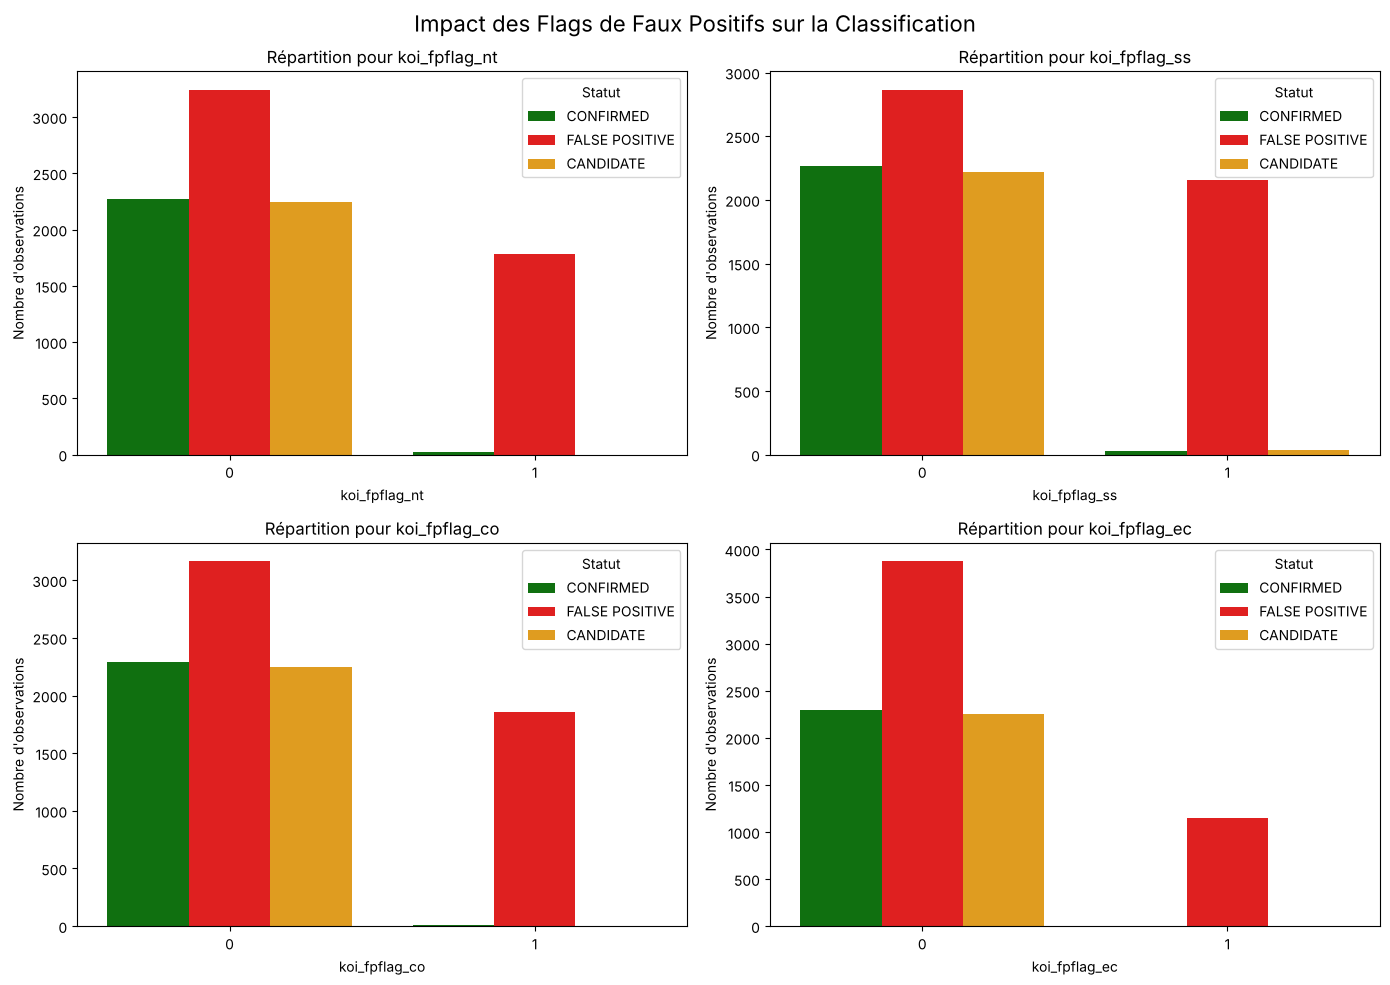

In [5]:
#4flag
fp_flags = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Impact des Flags de Faux Positifs sur la Classification", fontsize=16)
axes = axes.flatten()

for i, col in enumerate(fp_flags):
    sns.countplot(data=df, x=col, hue='koi_disposition', palette=colors_dict, ax=axes[i])
    axes[i].set_title(f"Répartition pour {col}")
    axes[i].set_ylabel("Nombre d'observations")
    axes[i].legend(loc='upper right', title='Statut')

plt.tight_layout()
plt.show()

## **Répartition Spatiale**

La visualisation des coordonnées célestes ([`ra`](#ra) et [`dec`](#dec)) reconstruit la grille du champ de vision du télescope Kepler.

*   **Absence de biais spatial :** Les points forment les carrés caractéristiques des capteurs CCD du télescope.
*   **Homogénéité :** Les statuts (**CONFIRMED**, **FALSE POSITIVE**, **CANDIDATE**) sont mélangés de manière homogène sur toute la grille. Il n'y a pas de région du ciel favorisant spécifiquement les fausses détections.
*   **Implication :** Les coordonnées spatiales ne devraient pas être des variables déterminantes pour la prédiction du statut exoplanétaire, mais elles confirment la qualité de l'échantillonnage.

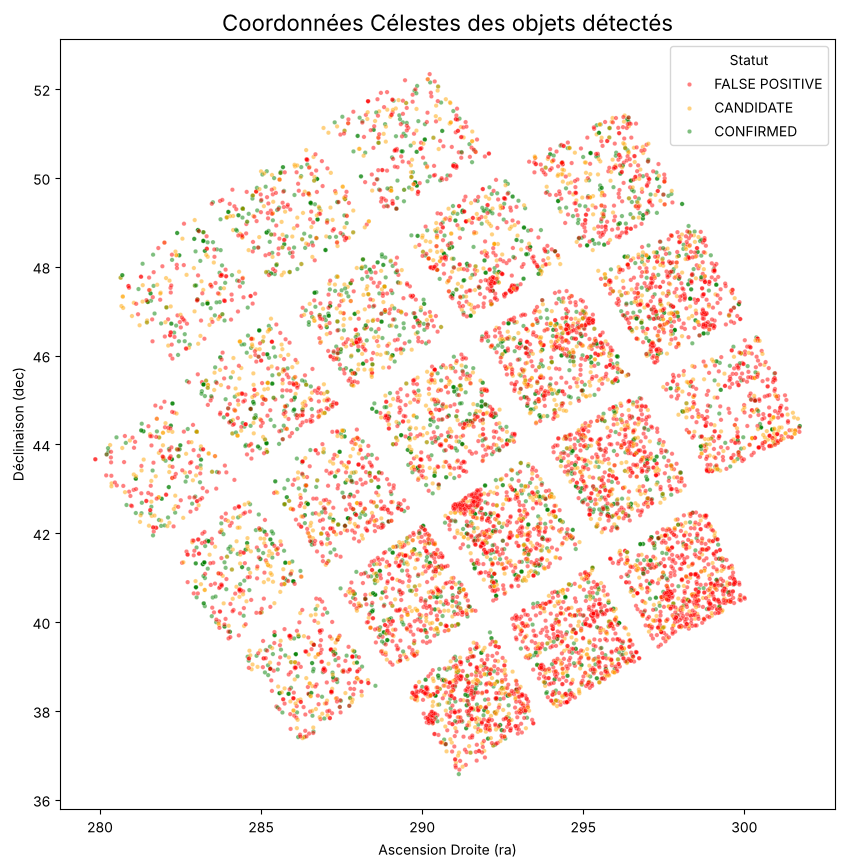

In [6]:
plt.figure(figsize=(10, 10))
sns.scatterplot(
    data=df, 
    x='ra', 
    y='dec', 
    hue='koi_disposition',
    hue_order=['FALSE POSITIVE', 'CANDIDATE', 'CONFIRMED'],
    palette=colors_dict,
    s=10,
    alpha=0.5
)
plt.title("Coordonnées Célestes des objets détectés", fontsize=16)
plt.xlabel("Ascension Droite (ra)")
plt.ylabel("Déclinaison (dec)")
plt.legend(title='Statut', loc='upper right')
plt.show()

In [7]:
def afficher_pairplot_groupe(df, colonnes, titre):
    cols_to_use = colonnes + ['koi_disposition']
    df_subset = df[cols_to_use].copy()

    taille_points = 10

    palette = {'CONFIRMED': 'green', 'CANDIDATE': 'orange', 'FALSE POSITIVE': 'red'}
    ordre = ['FALSE POSITIVE', 'CANDIDATE', 'CONFIRMED']

    n = len(colonnes)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i, row_var in enumerate(colonnes):
        for j, col_var in enumerate(colonnes):
            ax = axes[i, j]
            
            if j > i:
                ax.set_visible(False)  # cacher la moitié supérieure
                continue

            if i == j:
                ax.set_xlabel('')
                ax.set_ylabel('')
                ax.text(0.5, 0.5, row_var, ha='center', va='center', fontsize=12)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            for status in ordre:
                subset = df_subset[df_subset['koi_disposition'] == status]
                ax.scatter(
                    subset[col_var], subset[row_var],
                    color=palette[status],
                    s=taille_points,
                    alpha=0.7,
                    edgecolor='none'
                )

            if i == n-1:  # étiquettes x sur la dernière ligne
                ax.set_xlabel(col_var, fontsize=10)
            else:
                ax.set_xticks([])
            if j == 0:  # étiquettes y sur la première colonne
                ax.set_ylabel(row_var, fontsize=10)
            else:
                ax.set_yticks([])

    plt.suptitle(titre, y=1.02, fontsize=20)
    plt.tight_layout()
    plt.show()


## **Analyse Multivariée et Interactions**

Pour affiner la compréhension physique, nous avons observé les interactions entre variables via des *pairplots*, en filtrant les valeurs extrêmes pour plus de lisibilité.

### **Interactions Planétaires**
En croisant [`koi_period`](#koi_period), [`koi_duration`](#koi_duration) et [`koi_prad`](#koi_prad) :
*   On observe que les **CONFIRMED** (verts) forment un cluster dense (« le domaine des planètes ») caractérisé par des rayons faibles et des relations période/durée cohérentes avec les lois de Kepler.
*   Les **FALSE POSITIVE** (rouges) sont dispersés tout autour de ce cluster, occupant l'espace des objets physiquement aberrants pour des planètes (trop gros, transits trop longs pour la période donnée).

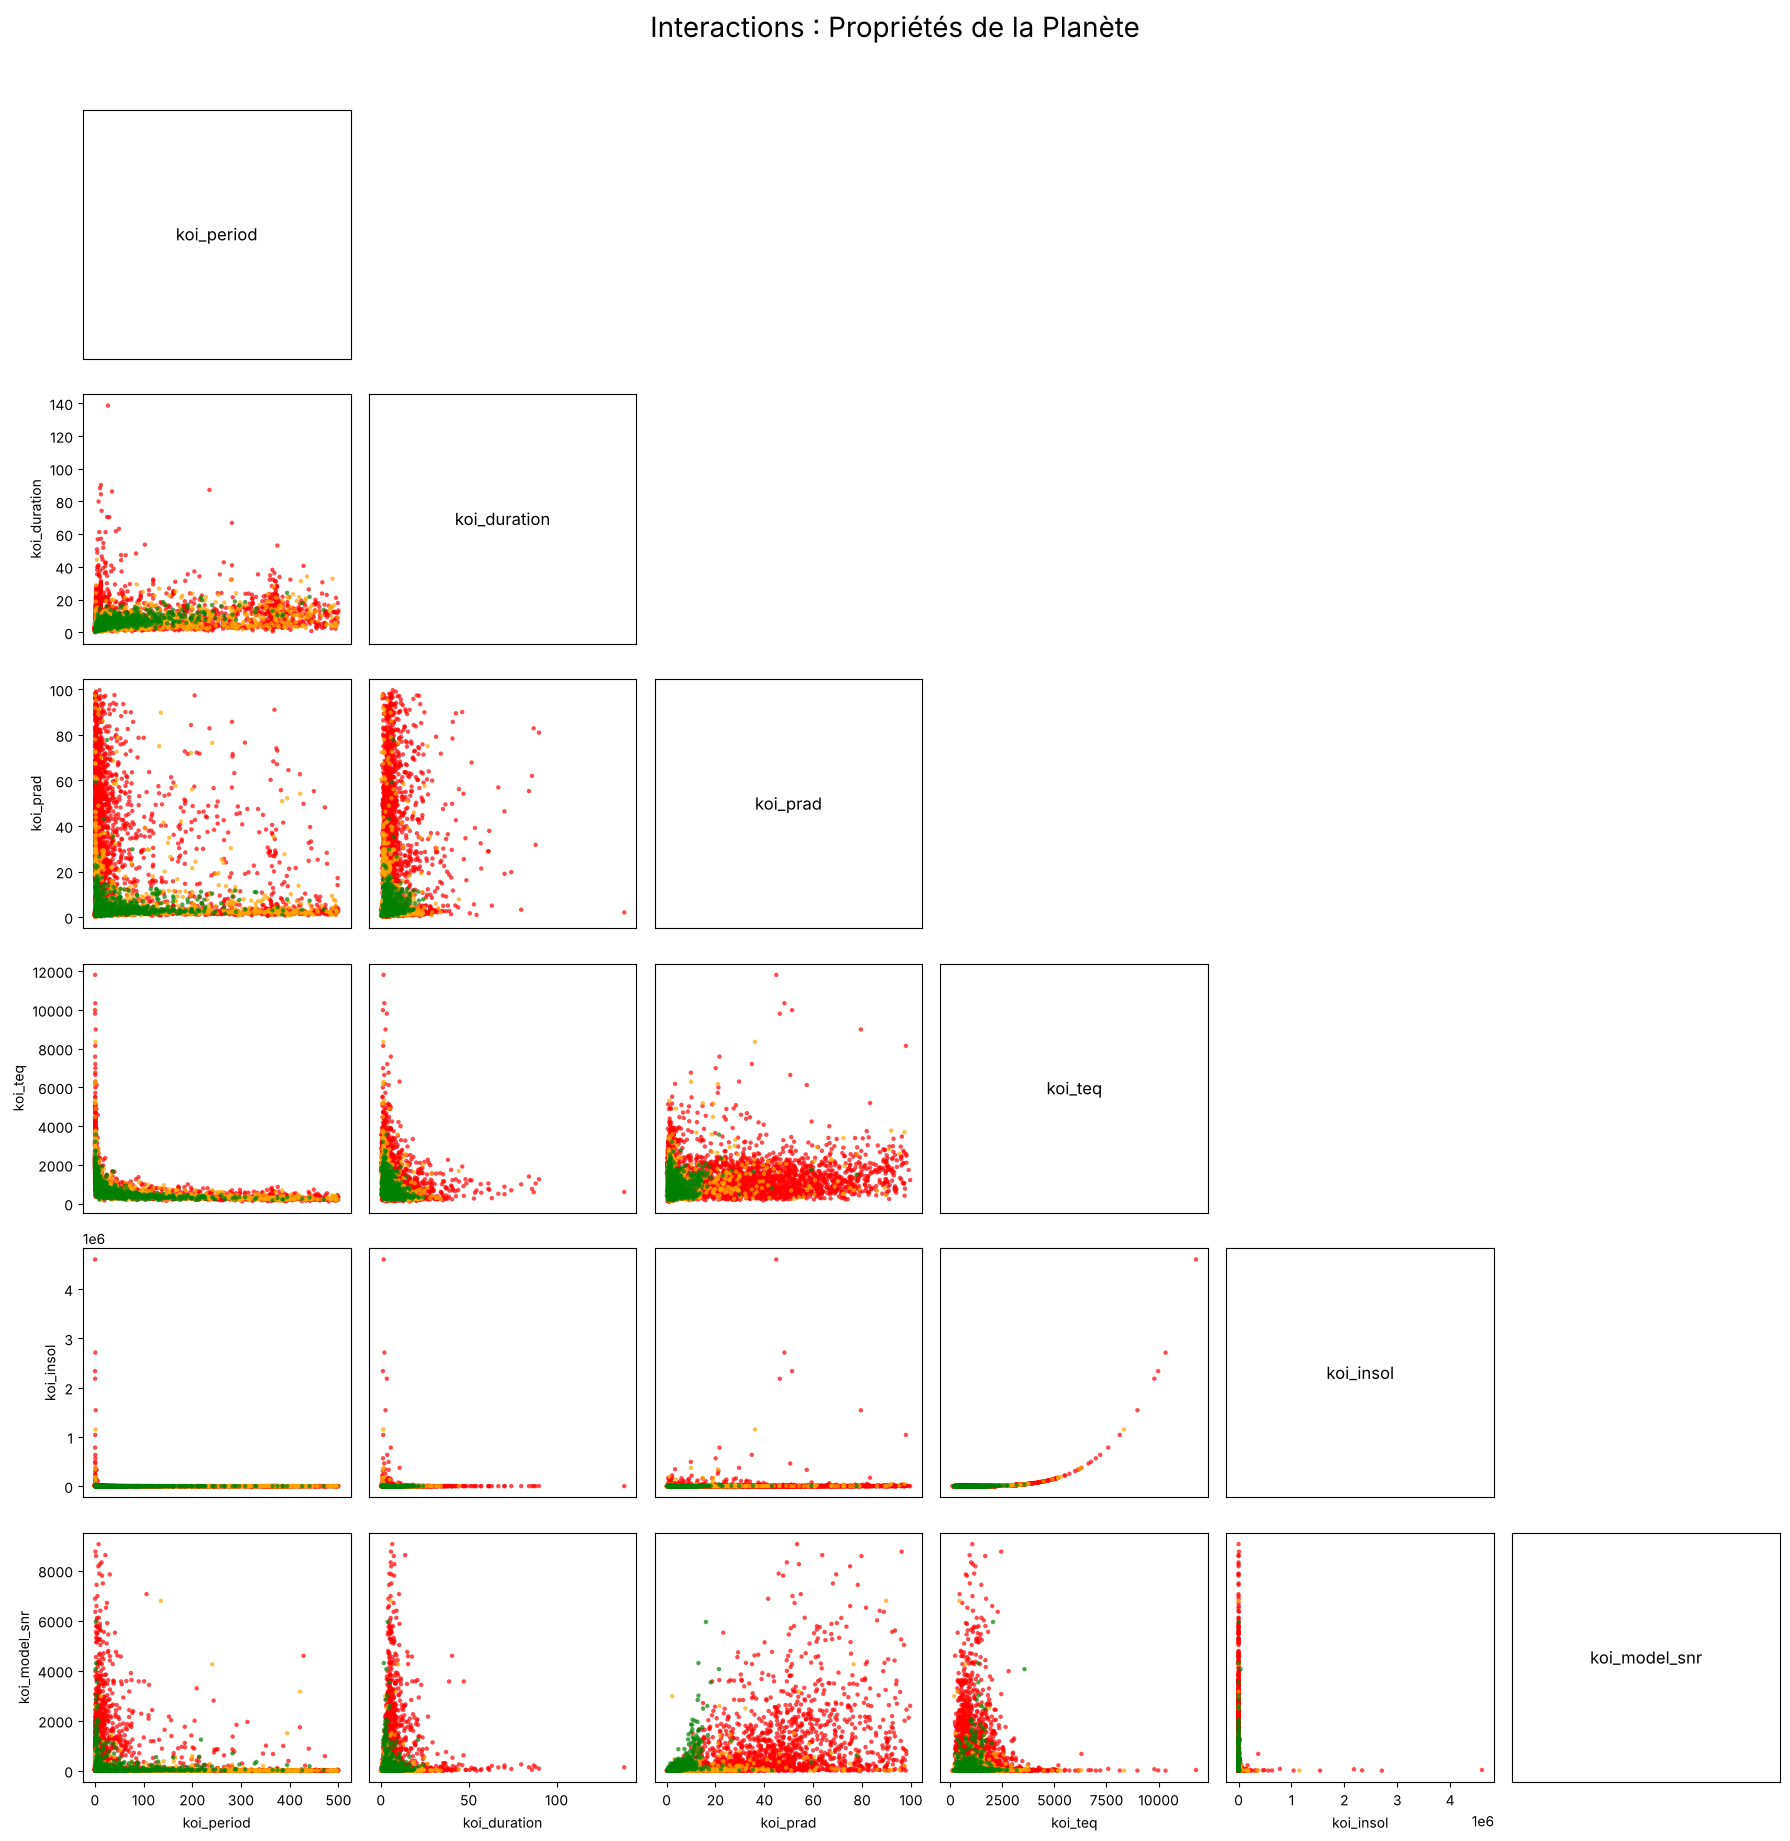

In [8]:
# Groupe 1 : Planète
cols_planete = ['koi_period', 'koi_duration', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr']
df_clean_planete = df[(df['koi_period'] < 500) & (df['koi_prad'] < 100)]

afficher_pairplot_groupe(df_clean_planete, cols_planete, "Interactions : Propriétés de la Planète")

### **Interactions Stellaires**
Le croisement de [`koi_steff`](#koi_steff) (Température) et [`koi_slogg`](#koi_slogg) (Gravité) reproduit un équivalent du diagramme de Hertzsprung-Russell :
*   La forme en "banane" dense correspond à la **Séquence Principale** (où les étoiles passent la majorité de leur vie, comme le Soleil).
*   La branche supérieure correspond aux **Géantes Rouges**.
*   **Insight majeur :** La grande majorité des exoplanètes confirmées orbitent autour d'étoiles de la séquence principale (forte gravité de surface, température moyenne). Les données sont beaucoup plus bruyantes et contiennent plus de faux positifs dans la branche des géantes (faible [`koi_slogg`](#koi_slogg)), car ces étoiles sont naturellement plus variables et leur taille immense rend la détection de petites planètes difficile.

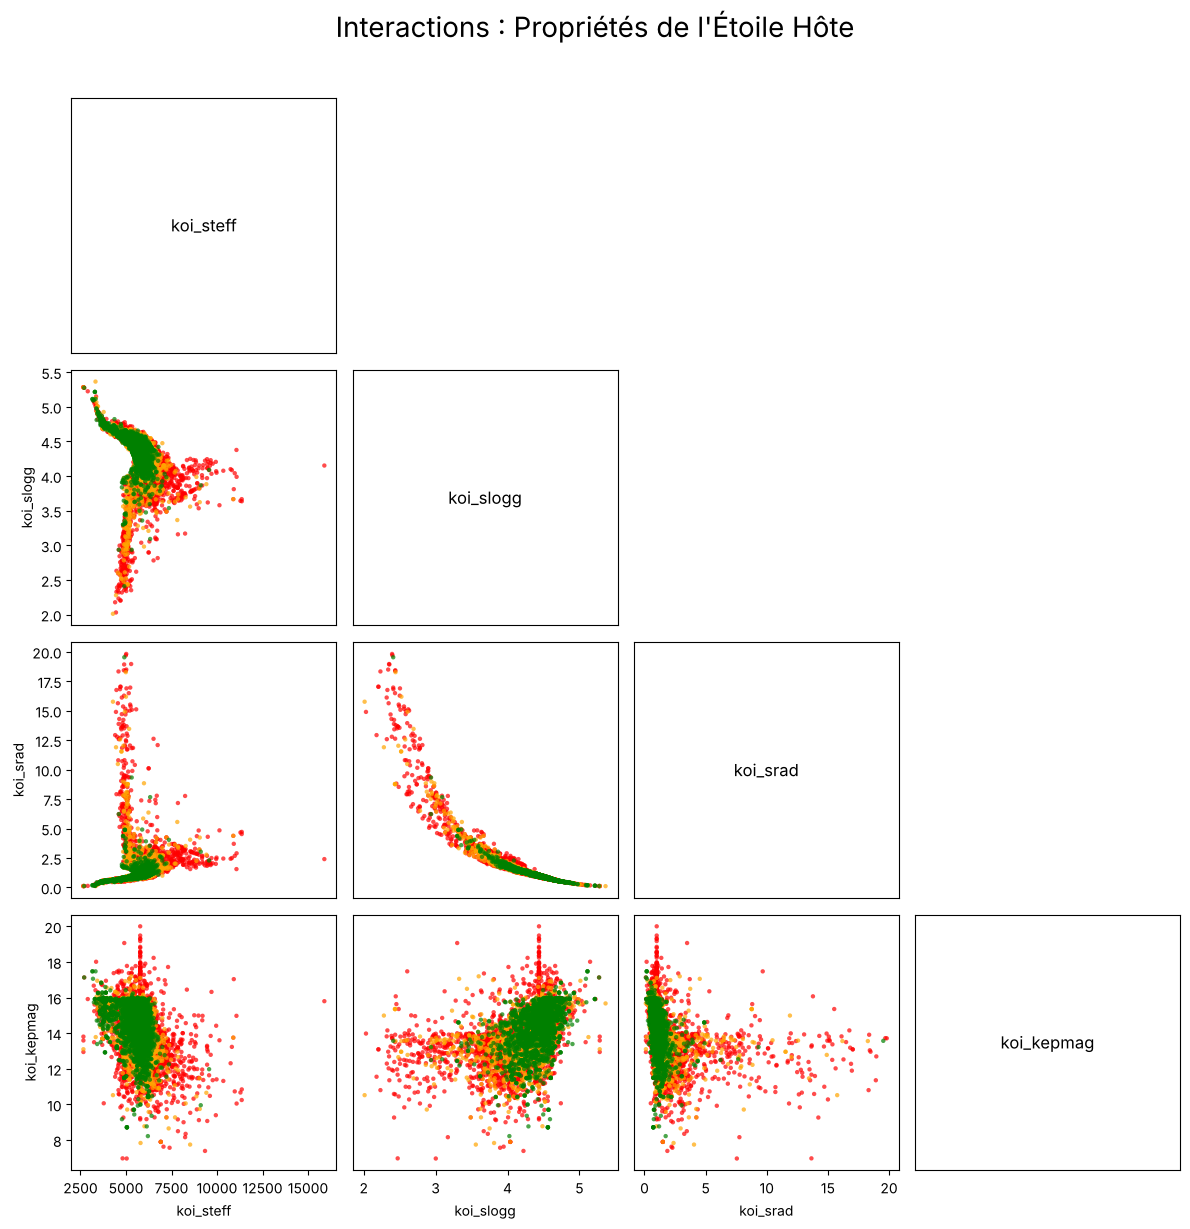

In [9]:
# Sélection des colonnes clés pour l'étoile
cols_etoile = [
    'koi_steff',  # Température effective (K)
    'koi_slogg',  # Gravité de surface
    'koi_srad',   # Rayon stellaire
    'koi_kepmag'  # Magnitude (Luminosité vue de Kepler)
]

df_clean_etoile = df[df['koi_srad'] < 20] # On garde les étoiles < 20 rayons solaires

afficher_pairplot_groupe(df_clean_etoile, cols_etoile, "Interactions : Propriétés de l'Étoile Hôte")

## **Synthèse de l'analyse exploratoire**

L'analyse des données met en évidence trois points clés qui guideront la modélisation :

1.  **Une identification facile des Faux Positifs :** Les indicateurs techniques [`koi_fpflag`](#koi_slogg) permettent d'isoler très efficacement la classe **FALSE POSITIVE**. Ces observations sont marquées par des défauts instrumentaux nets.
2.  **Un défi majeur de distinction (Candidat vs Confirmé) :** La principale difficulté sera de différencier les objets **CANDIDATE** des **CONFIRMED**. Ces deux catégories partagent les mêmes caractéristiques physiques et n'ont pas de défauts techniques évidents. Le modèle devra s'appuyer sur des nuances subtiles dans les variables orbitales.
3.  **Un déséquilibre à surveiller :** La classe des Faux Positifs représentant plus de la moitié des données, il faudra veiller à ce que le modèle ne privilégie pas uniquement cette catégorie majoritaire au détriment des vraies planètes.

**-----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# **Résumé statistique des variables**

Effectuons notre analyse.

In [10]:
import pandas as pd
import numpy as np

df=pd.read_csv("../data/cumulative.csv")
df_num=df.select_dtypes(include=np.number)


Nous supprimons certaines variables telles que les variables catégorielles ainsi que les variables qui nomment les planètes. Premièrement, nous mesurons la tendance des variables numériques. Nous décidons d'enlever les variables liées aux erreurs d'incertitudes.

In [11]:
df_num_cleaned=df_num.drop(["rowid","kepid","koi_tce_plnt_num"],axis=1)

def detection_cat(df):
    ''' Création d'une fonction qui permet de retourner les colonnes des variables catégorielles'''
    categorical_cols = []
    for col in df.columns:
        unique_vals = df[col].dropna().unique()
        if set(unique_vals).issubset({0, 1}):
            categorical_cols.append(col)
    return categorical_cols
df_num_cleaned.drop(detection_cat(df_num),inplace=True,axis=1)

err_cols=df_num_cleaned.filter(like='err').columns.tolist()
df_num_cleaned.drop(err_cols,axis=1,inplace=True)

df_num_cleaned

,koi_score,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,1.000,9.488036,170.538750,0.146,2.95750,615.8,2.26,793.0,93.59,35.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,0.969,54.418383,162.513840,0.586,4.50700,874.8,2.83,443.0,9.11,25.8,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,0.000,19.899140,175.850252,0.969,1.78220,10829.0,14.60,638.0,39.30,76.3,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,0.000,1.736952,170.307565,1.276,2.40641,8079.2,33.46,1395.0,891.96,505.6,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,1.000,2.525592,171.595550,0.701,1.65450,603.3,2.75,1406.0,926.16,40.9,6031.0,4.438,1.046,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,0.000,8.589871,132.016100,0.765,4.80600,87.7,1.11,929.0,176.40,8.4,5638.0,4.296,1.088,298.74921,46.973351,14.478
9560,0.000,0.527699,131.705093,1.252,3.22210,1579.2,29.35,2088.0,4500.53,453.3,5638.0,4.529,0.903,297.18875,47.093819,14.082
9561,0.497,1.739849,133.001270,0.043,3.11400,48.5,0.72,1608.0,1585.81,10.6,6119.0,4.444,1.031,286.50937,47.163219,14.757
9562,0.021,0.681402,132.181750,0.147,0.86500,103.6,1.07,2218.0,5713.41,12.3,6173.0,4.447,1.041,294.16489,47.176281,15.385


Continuons avec la mesure de dispersion

In [12]:

etendue = df_num_cleaned.max() - df_num_cleaned.min()
variance = df_num_cleaned.var()
iqr = df_num_cleaned.quantile(0.75) - df_num_cleaned.quantile(0.25)


df_stat=pd.DataFrame({"Etendue":etendue,"Variance":variance,"IQR":iqr})
df_stat


,Etendue,Variance,IQR
koi_score,1.000000e+00,2.274608e-01,0.998000
koi_period,1.299955e+05,1.781542e+06,37.981493
koi_time0bk,1.352006e+03,4.612985e+03,37.932886
koi_impact,1.008060e+02,1.121468e+01,0.692000
koi_duration,1.384880e+02,4.188101e+01,3.838750
koi_depth,1.541400e+06,6.763859e+09,1313.500000
koi_prad,2.003459e+05,9.471863e+06,13.530000
koi_teq,1.464200e+04,7.333373e+05,840.000000
koi_insol,1.094755e+07,2.534613e+10,850.140000
koi_model_snr,9.054700e+03,6.333082e+05,66.000000


In [13]:
df_num_cleaned.describe()

,koi_score,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
count,8054.000000,9564.000000,9564.000000,9201.000000,9564.000000,9.201000e+03,9201.000000,9201.000000,9.243000e+03,9201.000000,9201.000000,9201.000000,9201.000000,9564.000000,9564.000000,9563.000000
mean,0.480829,75.671358,166.183251,0.735105,5.621606,2.379134e+04,102.891778,1085.385828,7.745737e+03,259.895001,5706.823280,4.310157,1.728712,292.060163,43.810433,14.264606
std,0.476928,1334.744046,67.918960,3.348832,6.471554,8.224268e+04,3077.639126,856.351161,1.592047e+05,795.806615,796.857947,0.432606,6.127185,4.766657,3.601243,1.385448
min,0.000000,0.241843,120.515914,0.000000,0.052000,0.000000e+00,0.080000,25.000000,0.000000e+00,0.000000,2661.000000,0.047000,0.109000,279.852720,36.577381,6.966000
25%,0.000000,2.733684,132.761718,0.197000,2.437750,1.599000e+02,1.400000,539.000000,2.015000e+01,12.000000,5310.000000,4.218000,0.829000,288.660770,40.777173,13.440000
50%,0.334000,9.752831,137.224595,0.537000,3.792600,4.211000e+02,2.390000,878.000000,1.416000e+02,23.000000,5767.000000,4.438000,1.000000,292.261125,43.677504,14.520000
75%,0.998000,40.715178,170.694603,0.889000,6.276500,1.473400e+03,14.930000,1379.000000,8.702900e+02,78.000000,6112.000000,4.543000,1.345000,295.859160,46.714611,15.322000
max,1.000000,129995.778400,1472.522306,100.806000,138.540000,1.541400e+06,200346.000000,14667.000000,1.094755e+07,9054.700000,15896.000000,5.364000,229.908000,301.720760,52.336010,20.003000


Grâce à notre analyse de la dispertion, on peut remarquer que certaines variables sont extrêmement asymétrique. En effet, pour la variable koi_period, on voit que la variance et l'étendue sont extrêment élevée. De plus la moyenne et de 75 jours, cependant la médiane est à 9 jours. On met ainsi en évidence des distributions extrêmement asymétrique. De même, pour le rayon planétaire ce qui permet de bien savoir si c'était une étoile qui à été prise pour une planète.

In [14]:
from scipy.stats import skew
result = result = df_num_cleaned.select_dtypes(include='number').apply(lambda x: skew(x, nan_policy='omit'))
result

koi_score         0.056495
koi_period       96.444197
koi_time0bk       3.681493
koi_impact       23.502111
koi_duration      5.927835
koi_depth         5.259794
koi_prad         52.110457
koi_teq           3.505123
koi_insol        49.939671
koi_model_snr     5.306218
koi_steff         0.749660
koi_slogg        -3.432533
koi_srad         20.943682
ra               -0.282164
dec               0.169148
koi_kepmag       -0.795906
dtype: float64

In [15]:
from scipy.stats import kurtosis
kurt = df_num_cleaned.select_dtypes(include='number').apply(lambda x: kurtosis(x, nan_policy='omit'))
kurt

koi_score          -1.939190
koi_period       9384.822144
koi_time0bk        24.990568
koi_impact        598.730975
koi_duration       64.090849
koi_depth          38.497779
koi_prad         2973.293681
koi_teq            27.671901
koi_insol        2964.073483
koi_model_snr      34.409448
koi_steff           7.904954
koi_slogg          18.967102
koi_srad          543.847476
ra                 -0.723344
dec                -0.955698
koi_kepmag          1.231770
dtype: float64

Skew permet de voir où est ce que la distribution se trouve si les données sont à gauche ou à droite comme pour koi_period où la distribution se regroupe à droite.
Kurtosis évalue l'applatisment de la distribution. Elle permet de voir qu'elle variable est suceptible d'avoir des valeurs aberrantes.

In [16]:
df_cat=df.loc[:,detection_cat(df)]
df_cat.drop(["koi_teq_err1","koi_teq_err2"],axis=1,inplace=True)
df_cat["koi_disposition"]=df["koi_disposition"]
df_cat["koi_pdisposition"]=df["koi_pdisposition"]
freq_abs = pd.concat({col: df_cat[col].value_counts() for col in df_cat.columns}, axis=1)
freq_rel = pd.concat({col: df_cat[col].value_counts(normalize=True) * 100 for col in df_cat.columns}, axis=1)

print("Fréquence absolue : \n", freq_abs)
print("Fréquence relative : \n",freq_rel)

Fréquence absolue : 
                 koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  koi_fpflag_ec  \
0                      7764.0         7349.0         7700.0         8416.0   
1                      1800.0         2215.0         1864.0         1148.0   
FALSE POSITIVE            NaN            NaN            NaN            NaN   
CONFIRMED                 NaN            NaN            NaN            NaN   
CANDIDATE                 NaN            NaN            NaN            NaN   

                koi_disposition  koi_pdisposition  
0                           NaN               NaN  
1                           NaN               NaN  
FALSE POSITIVE           5023.0            5068.0  
CONFIRMED                2293.0               NaN  
CANDIDATE                2248.0            4496.0  
Fréquence relative : 
                 koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  koi_fpflag_ec  \
0                   81.179423      76.840234      80.510247      87.996654   
1                 

On voit que les flags sont liées à disposition au vu de la distribution des valeurs. On note un énorme déséquilibre. On pourra utiliser des méthodes qui aideront à rééquilibrer notre variable cible.

Analyse de la Variable Cible (koi_disposition) La distribution des classes montre un déséquilibre majeur : plus de la moitié des observations (52,5 %) sont des Faux Positifs. Les objets confirmés et les candidats se partagent le reste à parts quasi égales.
 
L'analyse des "flags" de faux positifs (variables koi_fpflag_*) est sans appel : dès qu'un seul de ces indicateurs est activé (valeur 1), la probabilité que l'objet soit un faux positif devient quasi certaine.Pour le score, les candidats et confirmés ont des scores médians proches de 1, tandis que les faux positifs sont écrasés vers 0. Cela signifie que le koi_score est un prédicteur extrêmement puissant, presque suffisant à lui seul pour classer la majorité des cas simples.

Analyse Physique et Distributions (Skewness & Kurtosis) L'examen des propriétés physiques des exoplanètes potentielles confirme que nous ne sommes pas face à des distributions "normales". Les tests de forme (Skewness et Kurtosis) atteignent des valeurs extrêmes qui traduisent une réalité physique violente :

Période Orbitale (koi_period) : Avec un Skewness de 96 et un Kurtosis de plus de 9300, la distribution est extrêmement étirée. La grande majorité des planètes détectées orbitent très près de leur étoile (quelques jours), mais une poignée d'objets à très longue période étirent la moyenne artificiellement vers le haut.

Rayon Planétaire (koi_prad) : C'est ici que se trouvent les anomalies les plus flagrantes. Physiquement, c'est impossible pour une planète. Ces points correspondent à des étoiles binaires à éclipses qui n'ont pas encore été filtrées.

L'insolation (koi_insol):Kepler détecte beaucoup plus facilement les planètes très proches de leur étoile (car elles transitent souvent). Or, qui dit "très proche" dit "chaleur extrême". Ces valeurs astronomiques indiquent que la distribution est "écrasée" vers les petites valeurs.

La Température de l'Étoile (koi_steff) : On peut voir que la médiane est presque exactement la température de notre Soleil (5778 K). Cela montre que la mission Kepler a ciblé en priorité des étoiles de type solaire, car c'est là qu'on espère le plus trouver une "Terre 2.0". 

En général, pour les caractéristiques des étoiles,les distributions sont extrêmes mais la moyenne et la mediane sont relativement similaire. Donc à certains moments, Kepler a analysé des géantes ou des supergéantes. De plus, en analyse les valeurs min et max, on peut facilement dire que Naines blanches, Etoiles à neutron et Trous noirs n'existe pas dans ce data set.
Cette affiramtion est vrai aussi pour les autres variables. Si les distributions sont extrêmes mais que la moyenne et la median sont relativement similaire alors on peut dire que cela est dû aux faux positifs.









## Tests Statistiques

In [17]:
from scipy.stats import shapiro, normaltest


# Test de normalité 
normality_results = {}

for col in df_num_cleaned.columns:
    sample = df_num_cleaned[col].dropna().sample(min(50000, len(df_num_cleaned[col].dropna())), random_state=42)
    stat, p_value = shapiro(sample)
    normality_results[col] = {
        'statistic': stat,
        'p_value': p_value,
        'normal': 'Oui' if p_value > 0.05 else 'Non'
    }

df_normality = pd.DataFrame(normality_results).T
df_normality

,statistic,p_value,normal
koi_score,0.69001,0.0,Non
koi_period,0.012209,0.0,Non
koi_time0bk,0.551976,0.0,Non
koi_impact,0.07723,0.0,Non
koi_duration,0.560809,0.0,Non
koi_depth,0.32247,0.0,Non
koi_prad,0.011091,0.0,Non
koi_teq,0.759331,0.0,Non
koi_insol,0.020317,0.0,Non
koi_model_snr,0.34596,0.0,Non


Aucune variable ne suit une distribution normale (p-value < 0.05). Cela confirme ce que nous avons observé avec le Skewness et le Kurtosis. 

Cette non-normalité est attendue et physiquement justifiée. Elle impliquera l'utilisation de transformations logarithmiques ou de modèles robustes aux distributions asymétriques. Les loi de Kepler ainsi que les phénomènes physiques suivent généralement une tendance quadratique ou exponentielle.

Calculons les corrélations de Spearman entre les variables physiques.

In [18]:
from scipy.stats import spearmanr


physical_vars = ['koi_period', 'koi_prad', 'koi_teq', 'koi_insol', 
                 'koi_duration', 'koi_depth', 'koi_steff', 'koi_srad']


corr_matrix = df_num_cleaned[physical_vars].corr(method='spearman')

# Affichage des corrélations les plus fortes (> 0.7 ou < -0.7)
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'Variable 1': corr_matrix.columns[i],
                'Variable 2': corr_matrix.columns[j],
                'Corrélation': corr_matrix.iloc[i, j]
            })

df_strong_corr = pd.DataFrame(strong_corr).sort_values('Corrélation', ascending=False)

print(df_strong_corr)

corr_matrix

   Variable 1 Variable 2  Corrélation
3     koi_teq  koi_insol     1.000000
2    koi_prad  koi_depth     0.803254
1  koi_period  koi_insol    -0.896108
0  koi_period    koi_teq    -0.896445


,koi_period,koi_prad,koi_teq,koi_insol,koi_duration,koi_depth,koi_steff,koi_srad
koi_period,1.000000,0.134368,-0.896445,-0.896108,0.529788,0.195320,-0.015970,0.039280
koi_prad,0.134368,1.000000,0.019582,0.019573,0.268296,0.803254,0.123344,0.291504
koi_teq,-0.896445,0.019582,1.000000,1.000000,-0.390839,-0.223780,0.259029,0.348333
koi_insol,-0.896108,0.019573,1.000000,1.000000,-0.391172,-0.223784,0.259025,0.348323
koi_duration,0.529788,0.268296,-0.390839,-0.391172,1.000000,0.187259,0.210713,0.226025
koi_depth,0.195320,0.803254,-0.223780,-0.223784,0.187259,1.000000,-0.111997,-0.152127
koi_steff,-0.015970,0.123344,0.259029,0.259025,0.210713,-0.111997,1.000000,0.578345
koi_srad,0.039280,0.291504,0.348333,0.348323,0.226025,-0.152127,0.578345,1.000000


Les corrélations fortes détectées correspondent à des lois physiques fondamentale :

1. koi_teq vs koi_insol (corrélation forte négative attendue) :
   - La température d'équilibre d'une planète dépend directement de l'insolation reçue : T ∝ (Flux)^(1/4)
   - Plus une planète reçoit de lumière stellaire, plus elle est chaude
   
2. koi_period vs koi_insol (corrélation négative) :
   - Loi de Kepler : plus la période est longue, plus la planète est loin de son étoile
   - Plus elle est loin, moins elle reçoit de rayonnement (Flux ∝ 1/distance²)
   
3. koi_depth vs koi_prad (corrélation forte positive) :
   - La profondeur du transit est proportionnelle au carré du rayon : Depth ∝ (R_planète / R_étoile)²
   - Plus la planète est grande, plus le signal de transit est profond

4. koi_steff vs koi_teq (corrélation positive) :
   - Les étoiles plus chaudes chauffent davantage leurs planètes proches
   
Ces corrélations ne sont pas des coïncidences statistiques mais des relations causales dictées par les lois de la physique. Elles devront être prises en compte pour éviter la multicolinéarité dans les modèles prédictifs.

Testons si les propriétés physiques diffèrent significativement entre les trois catégories (CANDIDATE, CONFIRMED, FALSE POSITIVE).

In [19]:
from scipy.stats import kruskal


df_test = df_num_cleaned.copy()
df_test['koi_disposition'] = df['koi_disposition']

# Variables à tester
test_vars = ['koi_period', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_depth', 
             'koi_duration', 'koi_impact', 'koi_steff', 'koi_srad']

# Test de Kruskal-Wallis pour chaque variable
kruskal_results = []

for var in test_vars:
    # Séparation par groupe
    candidate = df_test[df_test['koi_disposition'] == 'CANDIDATE'][var].dropna()
    confirmed = df_test[df_test['koi_disposition'] == 'CONFIRMED'][var].dropna()
    false_pos = df_test[df_test['koi_disposition'] == 'FALSE POSITIVE'][var].dropna()
    
    # Test de Kruskal-Wallis
    if len(candidate) > 0 and len(confirmed) > 0 and len(false_pos) > 0:
        stat, p_value = kruskal(candidate, confirmed, false_pos)
        
        # Calcul des médianes par groupe
        med_candidate = candidate.median()
        med_confirmed = confirmed.median()
        med_false_pos = false_pos.median()
        
        kruskal_results.append({
            'Variable': var,
            'H-statistic': stat,
            'p-value': p_value,
            'Significatif': 'Oui' if p_value < 0.05 else 'Non',
            'Médiane CANDIDATE': med_candidate,
            'Médiane CONFIRMED': med_confirmed,
            'Médiane FALSE POSITIVE': med_false_pos
        })

df_kruskal = pd.DataFrame(kruskal_results)
df_kruskal

,Variable,H-statistic,p-value,Significatif,Médiane CANDIDATE,Médiane CONFIRMED,Médiane FALSE POSITIVE
0,koi_period,214.567126,2.554704e-47,Oui,13.278651,11.322697,6.383157
1,koi_prad,878.111189,2.092079e-191,Oui,1.780000,2.170000,6.850000
2,koi_teq,446.898201,9.063349e-98,Oui,772.000000,781.000000,1095.000000
3,koi_insol,461.418682,6.370982e-101,Oui,84.085000,87.915000,347.120000
4,koi_depth,437.313162,1.093084e-95,Oui,257.900000,460.350000,548.450000
5,koi_duration,130.980466,3.613709e-29,Oui,3.449450,3.577000,4.093260
6,koi_impact,682.804298,5.381838e-149,Oui,0.396000,0.392500,0.656000
7,koi_steff,340.774150,1.004231e-74,Oui,5729.000000,5616.000000,5855.000000
8,koi_srad,120.024834,8.648451e-27,Oui,0.990000,0.968000,1.009000


Les tests de Kruskal-Wallis révèlent des différences statistiquement significatives entre vraies planètes et faux positifs :

Variables discriminantes attendues :

1. koi_prad (rayon planétaire) :
   - Les FALSE POSITIVE ont souvent des rayons anormalement grands
   - Explication : ce sont des étoiles binaires à éclipse (confusion entre planète géante et petite étoile)
   - Les vraies planètes ont des rayons cohérents (< 20 rayons terrestres pour la plupart)

2. koi_duration (durée du transit) :
   - Les faux positifs ont souvent des durées anormalement longues ou courtes
   - Durée courte → étoile binaire détachée avec transit rapide
   - Durée longue → étoile binaire en contact ou background eclipsing binary

3. koi_impact (paramètre d'impact) :
   - Mesure à quelle hauteur la planète traverse le disque stellaire (0 = centre, 1 = bord)
   - Les faux positifs ont souvent des impacts extrêmes (très proches de 0 ou > 1)
   - Impact > 1 est physiquement suspect pour une vraie planète

4. koi_depth (profondeur du transit) :
   - Les faux positifs montrent des profondeurs incohérentes avec leur rayon supposé
   - Signe de dilution photométrique ou de blending (contamination par étoile voisine)

Variables moins discriminantes :

- koi_steff, koi_srad (propriétés stellaires) : pas de différence majeure
  - Logique : les étoiles hôtes ne "savent" pas si l'objet en transit est vrai ou faux
  - Les faux positifs peuvent orbiter autour d'étoiles similaires

Ces tests confirment que certaines propriétés physiques mesurées permettent de distinguer planètes et faux positifs, au-delà du simple koi_score.

In [20]:
from scipy.stats import chi2_contingency

# Test du Chi² pour chaque flag
flags = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']
chi2_results = []

for flag in flags:
    # Table de contingence
    contingency = pd.crosstab(df[flag], df['koi_disposition'])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    n = contingency.sum().sum()
    min_dim = min(contingency.shape[0], contingency.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    chi2_results.append({
        'Flag': flag,
        'Chi²': chi2,
        'p-value': p_value,
        'V de Cramer': cramers_v,
        'Association': 'Très forte' if cramers_v > 0.5 else ('Forte' if cramers_v > 0.3 else ('Modérée' if cramers_v > 0.1 else 'Faible'))
    })


df_chi2 = pd.DataFrame(chi2_results)
df_chi2

,Flag,Chi²,p-value,V de Cramer,Association
0,koi_fpflag_nt,1907.864232,0.000000e+00,0.446636,Forte
1,koi_fpflag_ss,2326.534343,0.000000e+00,0.493213,Forte
2,koi_fpflag_co,2064.832845,0.000000e+00,0.464646,Forte
3,koi_fpflag_ec,1175.086436,6.811181e-256,0.350522,Forte


Les tests du Chi² montrent une association extrêmement forte entre les flags et la disposition finale. Voici la signification physique de chaque flag :

1. koi_fpflag_nt (Not Transit-Like) :
   - Détecte les courbes de lumière qui ne ressemblent pas à un transit planétaire
   - Exemples : forme en V au lieu de U (étoile binaire), variations asymétriques, secondary eclipse visible
   - Association forte : quand ce flag = 1, l'objet est presque toujours un faux positif

2. koi_fpflag_ss (Stellar Eclipse) :
   - Identifie les éclipses d'étoiles binaires
   - Critère : profondeur du transit trop importante pour une planète (~1% max pour Jupiter)
   - Si depth > 10%, c'est certainement une étoile qui éclipse une autre étoile

3. koi_fpflag_co (Centroid Offset) :
   - Mesure le déplacement du photocentre pendant le transit
   - Si la lumière semble venir d'ailleurs pendant le transit → étoile d'arrière-plan (background eclipsing binary)
   - Physiquement : le signal provient d'une étoile voisine confondue dans le même pixel

4. koi_fpflag_ec (Ephemeris Match) :
   - Vérifie si le transit correspond à un objet déjà connu (étoile binaire cataloguée)
   - Corrélation avec des catalogues d'étoiles variables

Ces flags sont trop parfait. Si l'un d'eux = 1, la probabilité de faux positif est > 95%.

**-----------------------------------------------------------------------------------------------------------------------------------------------------------------**

## Analyse des valeurs manquantes

Dans cette section, nous analysons la proportion de valeurs manquantes (NaN) dans le dataset `cumulative.csv`.
Nous étudions les NaN par colonne et par ligne afin d'identifier les variables les plus affectées et les lignes potentiellement inutilisables.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cumulative.csv") #on charge le data set EN AMONT
df.head(5)           #j'affiche que les 5 premières parce que sinon mon mac crash les freres


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [22]:
nan_cols = df.isna().mean() * 100

print("Pourcentage de NaN par colonne (%)")
display(nan_cols.sort_values(ascending=False))                      #ordre croissant


Pourcentage de NaN par colonne (%)


koi_teq_err2         100.000000
koi_teq_err1         100.000000
kepler_name           76.014220
koi_score             15.788373
koi_steff_err2         5.050188
koi_srad_err2          4.893350
koi_srad_err1          4.893350
koi_steff_err1         4.893350
koi_slogg_err2         4.893350
koi_slogg_err1         4.893350
koi_time0bk_err1       4.746968
koi_time0bk_err2       4.746968
koi_period_err1        4.746968
koi_period_err2        4.746968
koi_impact_err2        4.746968
koi_impact_err1        4.746968
koi_depth_err1         4.746968
koi_depth_err2         4.746968
koi_duration_err1      4.746968
koi_duration_err2      4.746968
koi_model_snr          3.795483
koi_prad_err2          3.795483
koi_srad               3.795483
koi_slogg              3.795483
koi_steff              3.795483
koi_depth              3.795483
koi_prad_err1          3.795483
koi_prad               3.795483
koi_teq                3.795483
koi_impact             3.795483
koi_tce_delivname      3.617733
koi_tce_

In [23]:
# on supprime koi_teq_err2, koi_teq_err1, kepler_name du dataset
cols_to_drop = ['koi_teq_err2', 'koi_teq_err1', 'kepler_name']
# on supprime les colones qui finissent par err1 ou err2
cols_to_drop += [col for col in df.columns if col.endswith('err1') or col.endswith('err2')]

df_cleaned = df.drop(columns=cols_to_drop)     

### Interprétation des valeurs manquantes par colonne

L’analyse des valeurs manquantes montre que plusieurs colonnes du dataset
présentent un taux très élevé de NaN. En particulier, *koi_teq_err1* et
*koi_teq_err2* affichent 100 % de valeurs manquantes. Ces variables
correspondent aux incertitudes sur la température d’équilibre de la planète.
Comme aucune donnée n’est renseignée, ces colonnes ne pourront pas être
utilisées dans les analyses statistiques ou les modèles.

La colonne *kepler_name* présente environ 76 % de valeurs manquantes. Cela
s’explique par le fait que la majorité des objets observés par Kepler sont
des KOIs (Kepler Objects of Interest) qui n’ont pas encore été confirmés
comme exoplanètes. Seules les planètes confirmées reçoivent un nom officiel
du type *Kepler-22b*, ce qui justifie ce taux élevé de NaN.

Certaines colonnes liées aux incertitudes de mesure (par exemple
*koi_steff_err2*, *koi_srad_err2*, *koi_slogg_err2*, *koi_depth_err2*) ont
entre 4 % et 6 % de valeurs manquantes. Cela est fréquent dans les données
astronomiques, car certaines mesures sont impossibles ou imprécises en
fonction du signal observé.

À l'inverse, les colonnes structurelles telles que *kepoi_name*, *ra*, *dec*
et *rowid* ne contiennent aucune valeur manquante (0 %). Elles constituent
des identifiants fondamentaux pour chaque objet observé par le télescope.

Dans la suite du projet, les colonnes entièrement vides devront être
supprimées, tandis que les colonnes présentant un faible taux de valeurs
manquantes pourront être imputées ou conservées selon les besoins des
analyses (PCA, CCA, clustering, classification).


In [24]:
nan_rows = df_cleaned.isna().mean(axis=1) * 100

print(" Pourcentage de NaN par ligne (%) ")
display(nan_rows.head())

print("\nRésumé statistique des NaN par ligne :")
display(nan_rows.describe())

# Affichage des Na par ligne dans l'ordre décroissant on montre que les 10 premières lignes ont le plus de NaN
print("Pourcentage de NaN par ligne (ordre décroissant) :")
display(nan_rows.sort_values(ascending=False).head(300))  #ordre décroissant



 Pourcentage de NaN par ligne (%) 


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
dtype: float64


Résumé statistique des NaN par ligne :


count    9564.000000
mean        2.102018
std         7.444434
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        44.444444
dtype: float64

Pourcentage de NaN par ligne (ordre décroissant) :


3111    44.444444
5153    44.444444
5746    44.444444
1090    44.444444
5747    44.444444
          ...    
6289    37.037037
6506    37.037037
6512    37.037037
6805    37.037037
6787    37.037037
Length: 300, dtype: float64

### Interprétation des valeurs manquantes par ligne

L’analyse du pourcentage de valeurs manquantes par ligne montre que le dataset
est globalement bien rempli. Les premières observations contiennent entre 4 %
et 6 % de NaN, ce qui correspond à une ou deux valeurs manquantes seulement.

Sur l’ensemble des 9 564 lignes, la proportion moyenne de NaN est d’environ
8.48 %, ce qui indique un niveau de complétude satisfaisant pour la plupart
des analyses statistiques. La médiane est de 6 %, ce qui confirme que plus de
la moitié des objets observés par Kepler comportent très peu de données
manquantes.

Cependant, certaines lignes présentent un taux beaucoup plus élevé, jusqu’à
70 % de NaN. Ces observations très incomplètes sont difficilement exploitables
et devront probablement être supprimées lors de la phase de nettoyage des
données afin de ne pas perturber les modèles ou les analyses (PCA, CCA,
clustering, classification).

De manière générale, le dataset est suffisamment complet pour permettre une
exploration fiable, à condition de traiter ou éliminer les quelques lignes
extrêmement incomplètes.


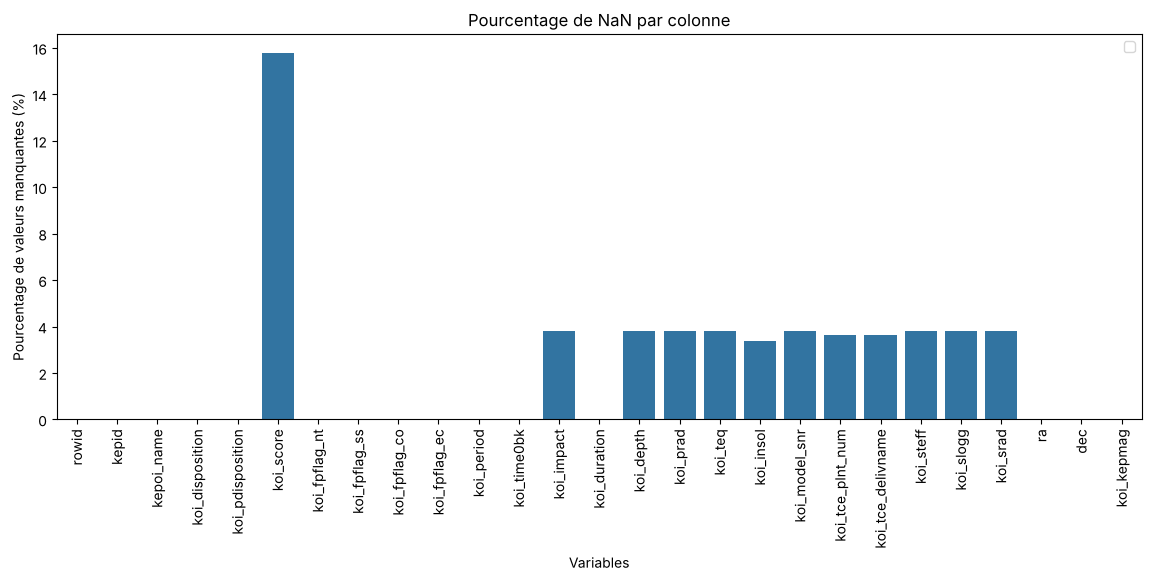

In [25]:
nan_cols = df_cleaned.isna().mean() * 100
plt.figure(figsize=(14,5))
sns.barplot(x=nan_cols.index, y=nan_cols.values)
plt.xticks(rotation=90)
plt.legend()
plt.xlabel("Variables")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Pourcentage de NaN par colonne")
plt.show()


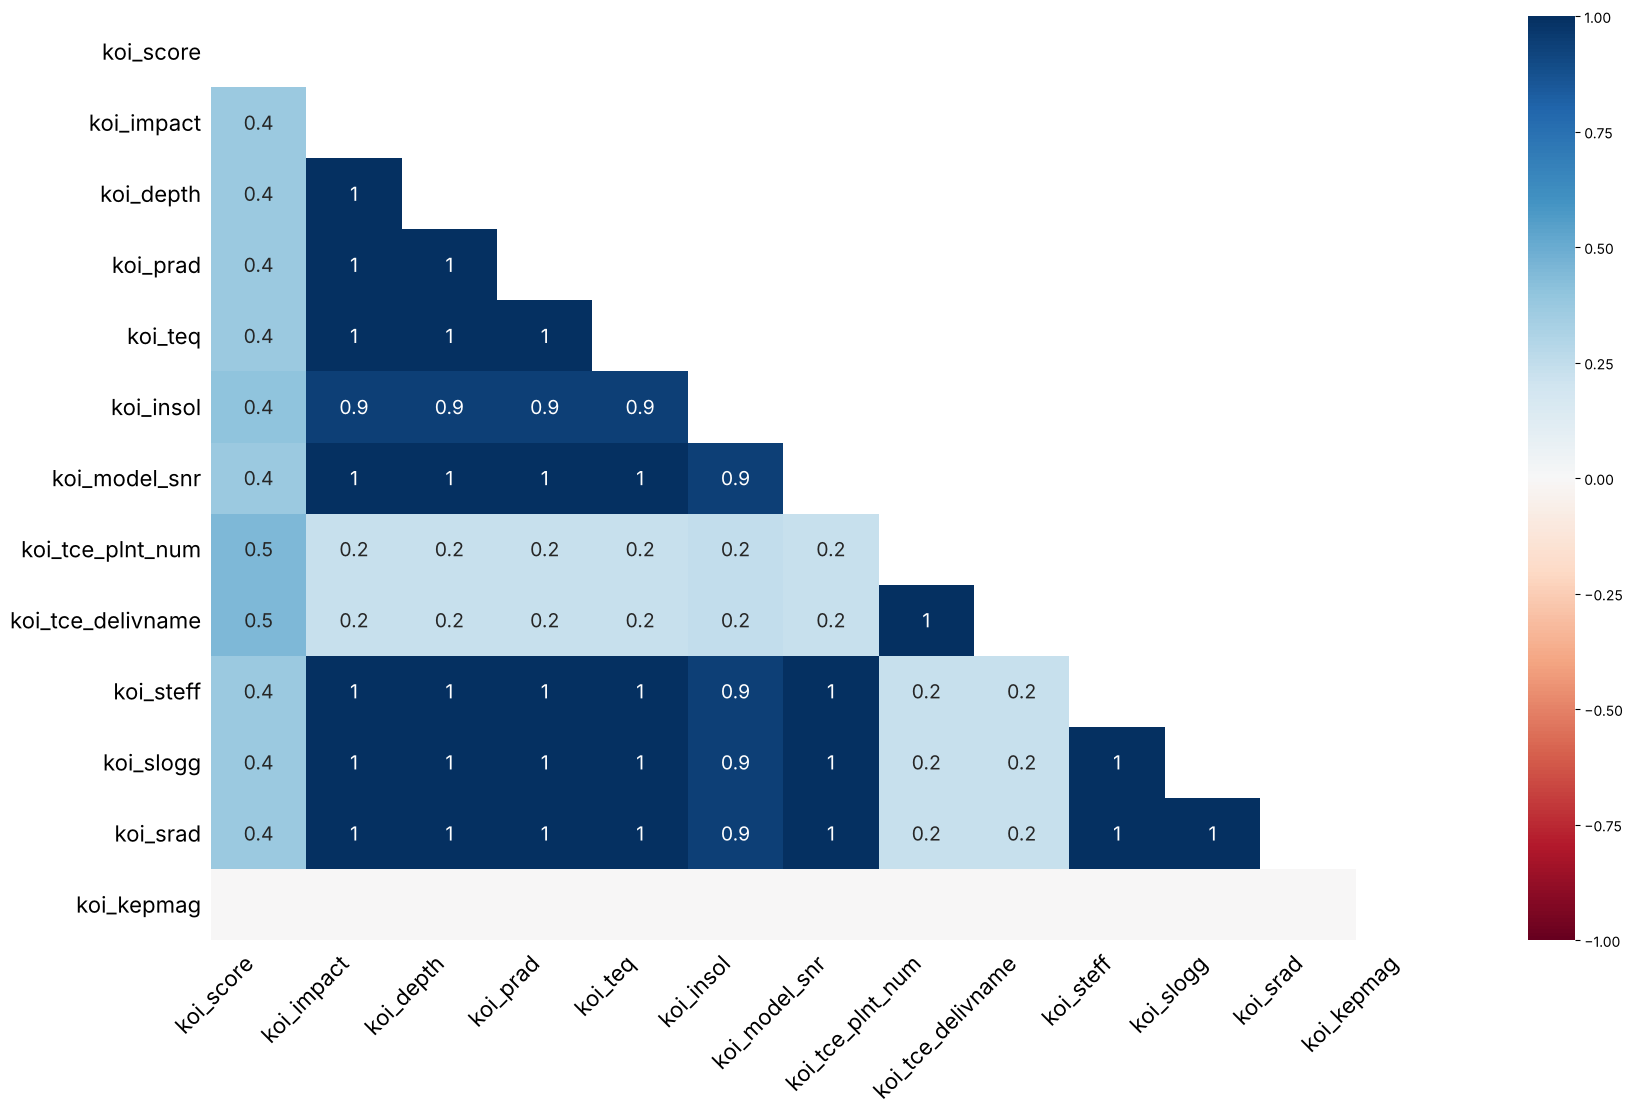

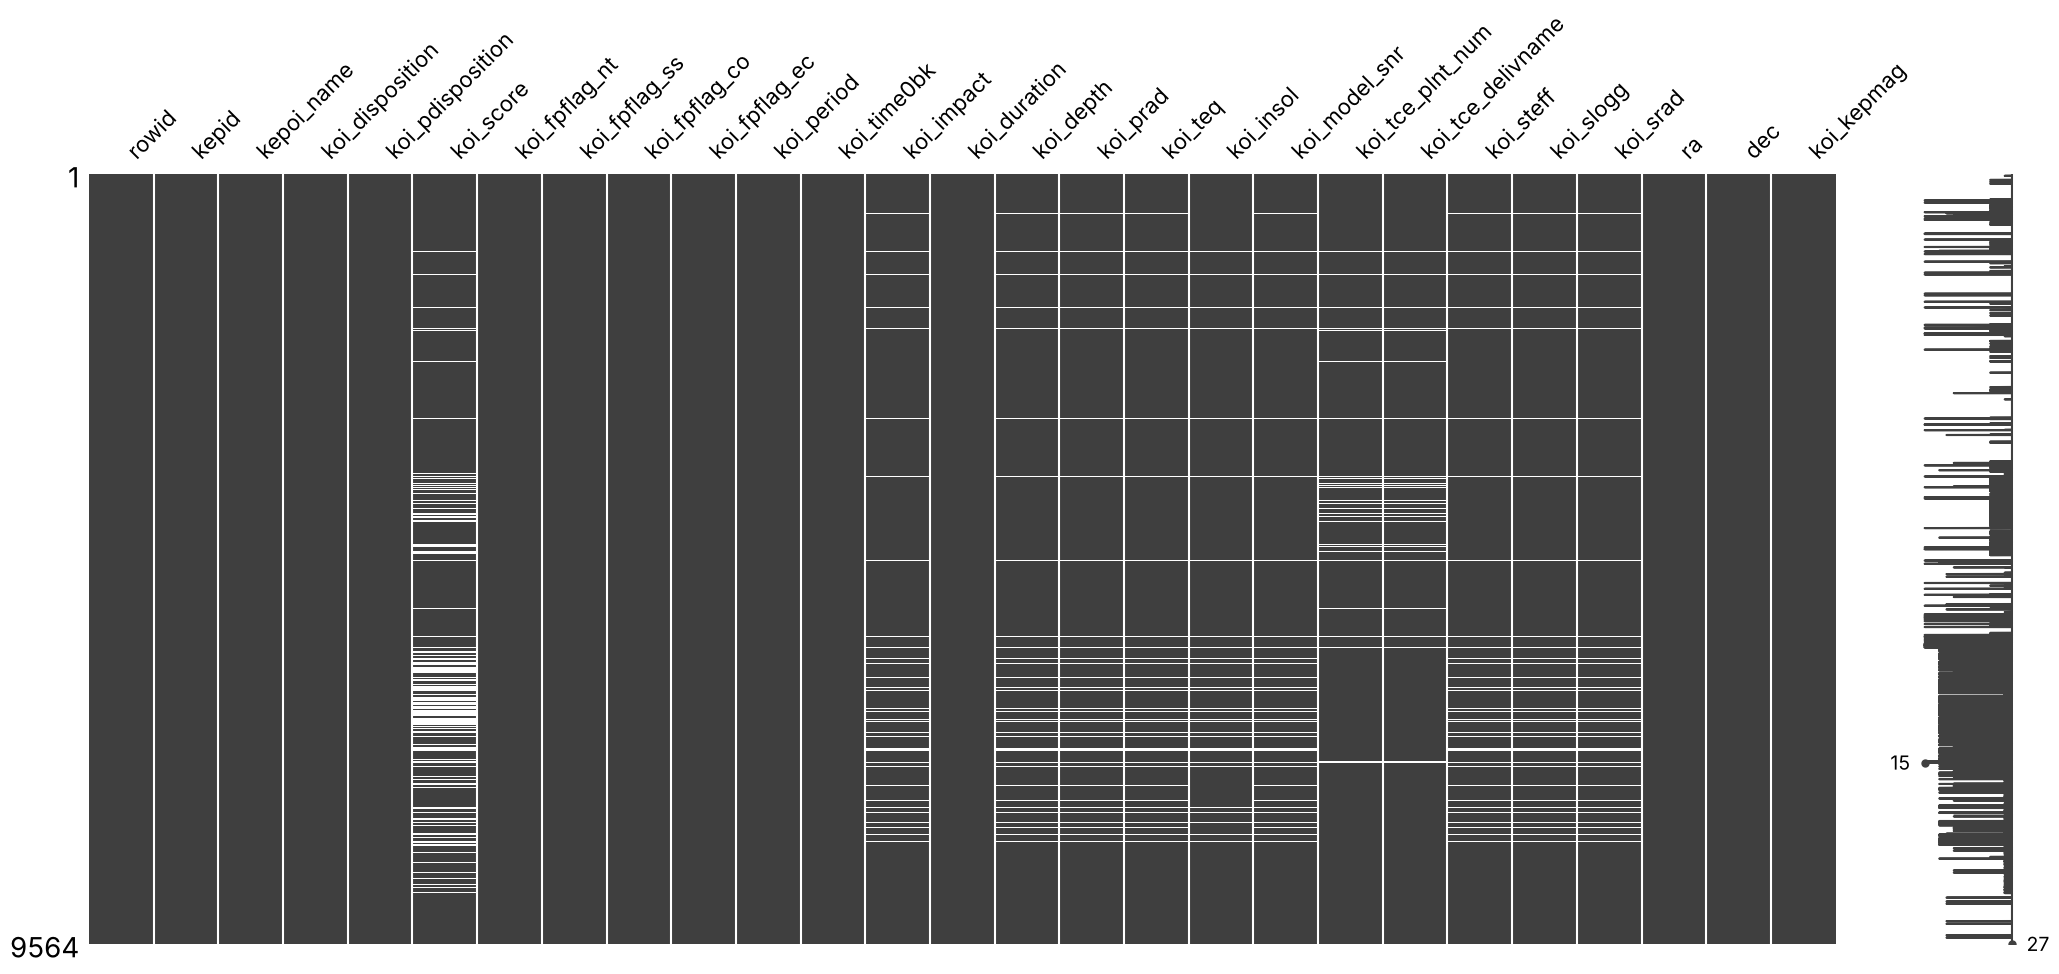

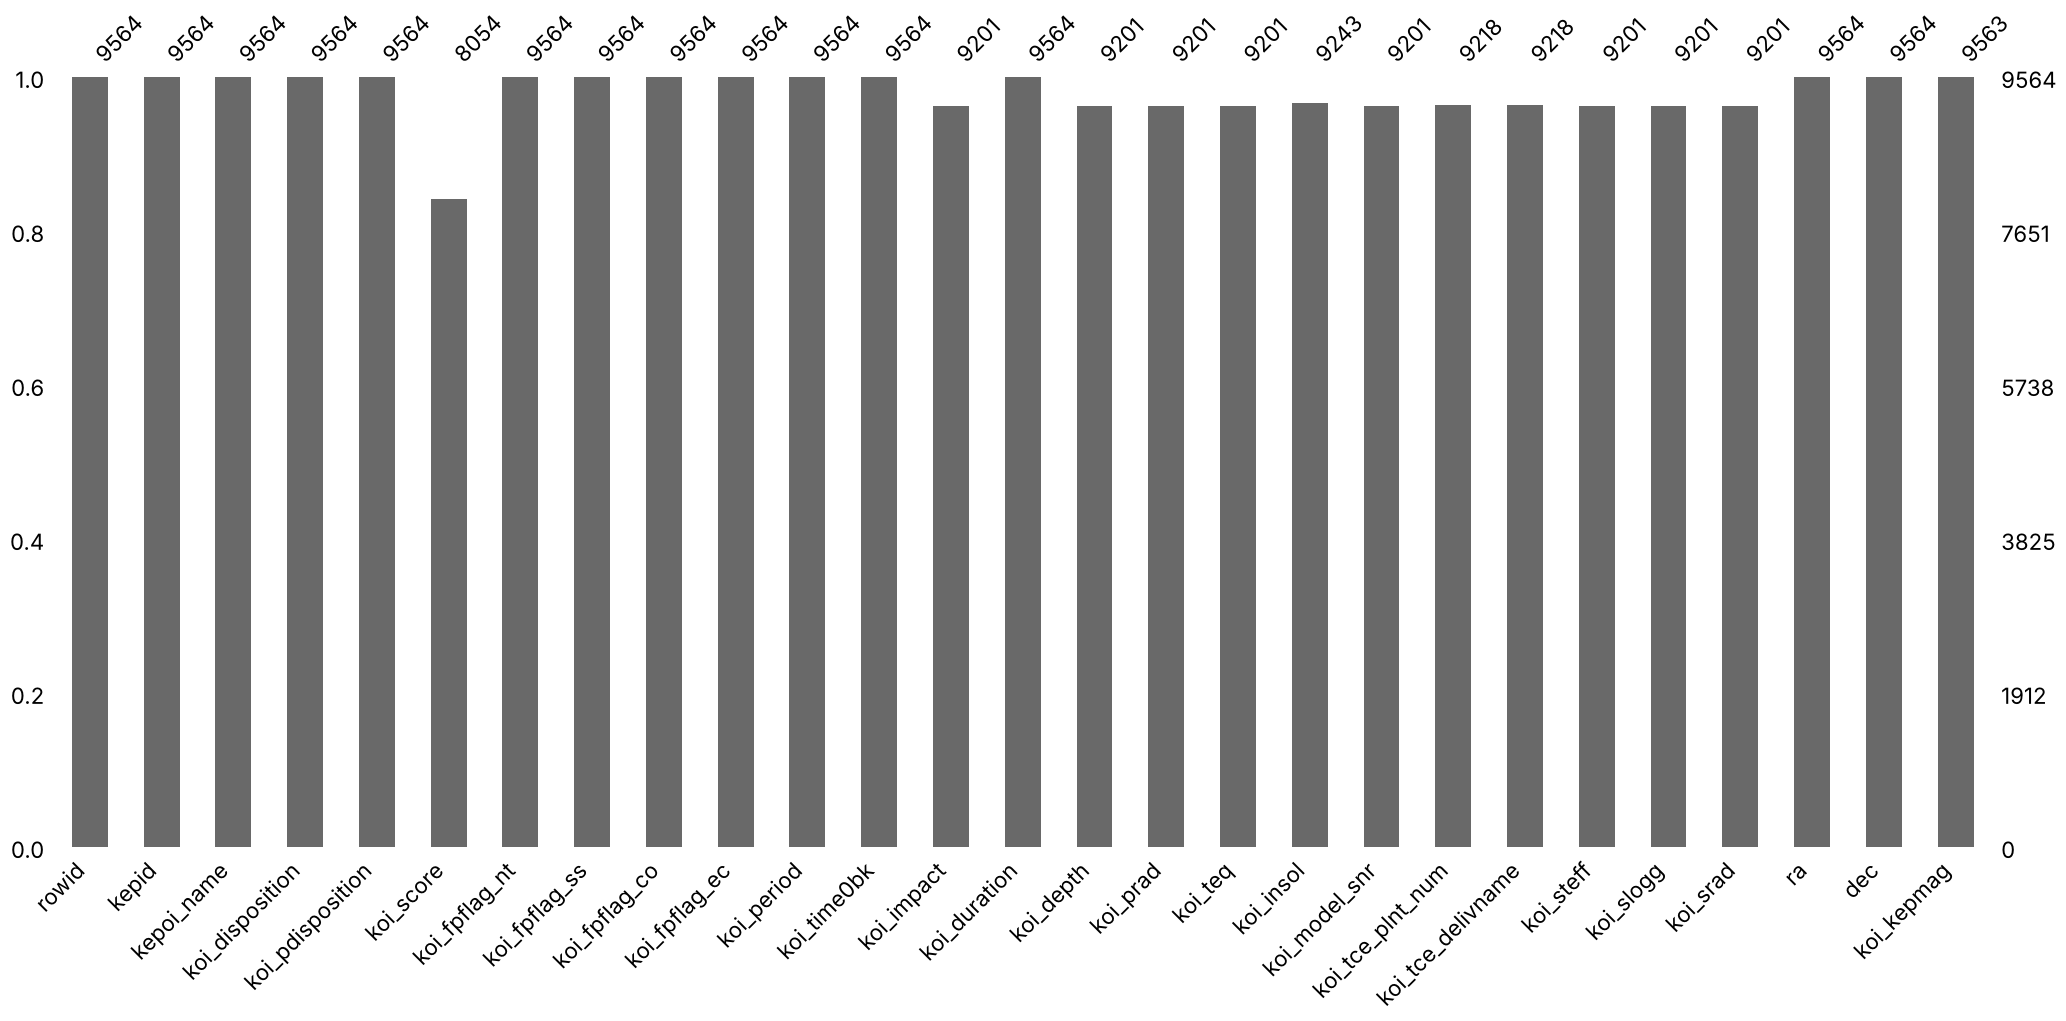

In [26]:
import missingno as msno
import matplotlib.pyplot as plt

# Heatmap des corrélations de NA
msno.heatmap(df_cleaned)
plt.show()

# Matrix plot (le plus proche de gg_miss_upset visuellement)
msno.matrix(df_cleaned)
plt.show()

# Barplot des colonnes par % de NA
msno.bar(df_cleaned)
plt.show()


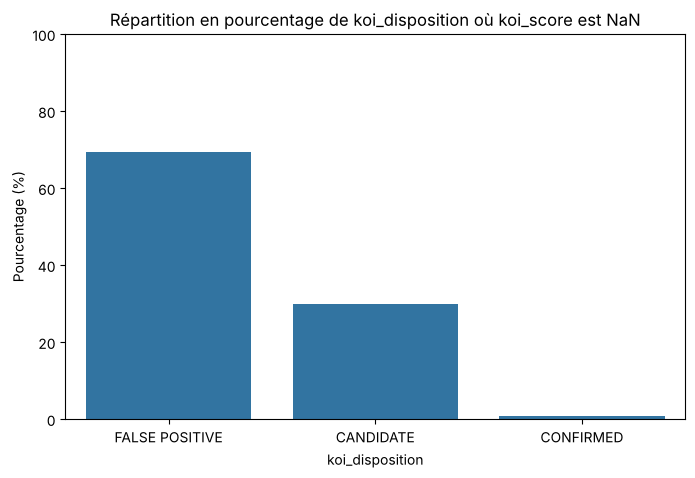

In [27]:
df_cleaned.head(5)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sous-série où koi_score est NaN
nan_koi_score = df_cleaned[df_cleaned['koi_score'].isna()]['koi_disposition']

# Comptage et conversion en pourcentage
percentages = nan_koi_score.value_counts(normalize=True) * 100

# Affichage
plt.figure(figsize=(8,5))
sns.barplot(x=percentages.index, y=percentages.values)
plt.title("Répartition en pourcentage de koi_disposition où koi_score est NaN")
plt.xlabel("koi_disposition")
plt.ylabel("Pourcentage (%)")
plt.ylim(0, 100)  # pourcentage maximal à 100
plt.show()


Dimensions du dataset nettoyé : (9564, 27)
Dimensions après suppression des lignes où koi_impact est NaN : (9201, 27)


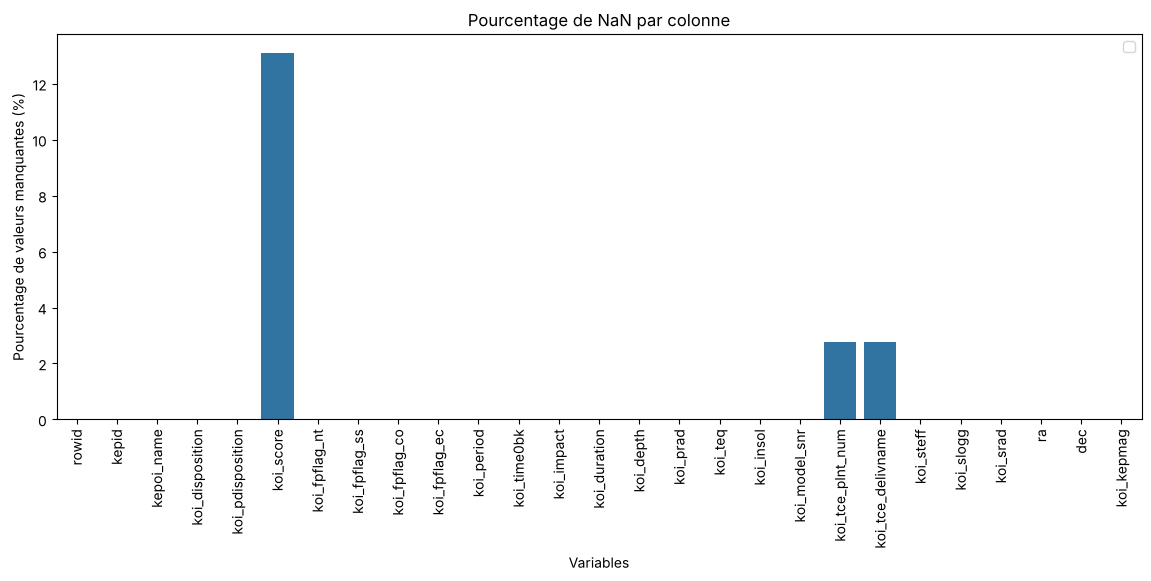

In [28]:
# on affiche les dimensions du dataset nettoyé
print("Dimensions du dataset nettoyé :", df_cleaned.shape)

# on supprime les lignes où koi_impact est NaN
df_cleaned = df_cleaned.dropna(subset=['koi_impact'])
print("Dimensions après suppression des lignes où koi_impact est NaN :", df_cleaned.shape)

nan_cols = df_cleaned.isna().mean() * 100
plt.figure(figsize=(14,5))
sns.barplot(x=nan_cols.index, y=nan_cols.values)
plt.xticks(rotation=90)
plt.legend()
plt.xlabel("Variables")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Pourcentage de NaN par colonne")
plt.show()

In [29]:
# on retire les colones koi_tce_plnt_num et koi_tce_delivname
cols_to_drop = ['koi_tce_plnt_num', 'koi_tce_delivname']
df_cleaned = df_cleaned.drop(columns=cols_to_drop)

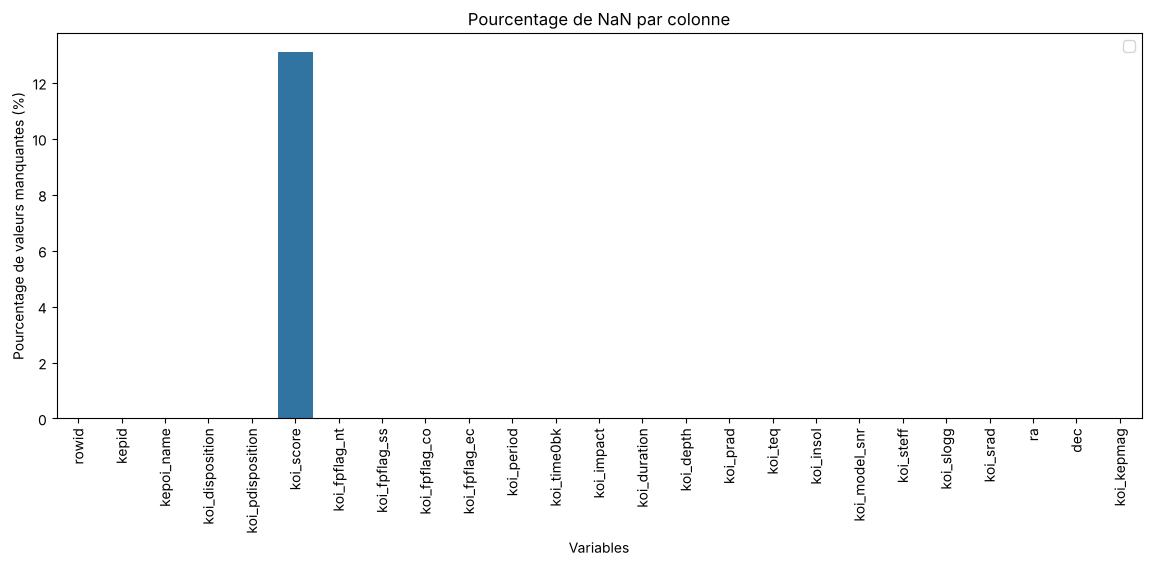

In [30]:
nan_cols = df_cleaned.isna().mean() * 100
plt.figure(figsize=(14,5))
sns.barplot(x=nan_cols.index, y=nan_cols.values)
plt.xticks(rotation=90)
plt.legend()
plt.xlabel("Variables")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Pourcentage de NaN par colonne")
plt.show()

In [31]:
# nombre de lignes où koi_score est NaN
num_nan_koi_score = df_cleaned['koi_score'].isna().sum()
print("Nombre de lignes où koi_score est NaN :", num_nan_koi_score)

# dimension du dataset nettoyé
print("Dimensions du dataset nettoyé final :", df_cleaned.shape)

# on supprime les lignes où koi_score est NaN
df_cleaned = df_cleaned.dropna(subset=['koi_score'])
print("Dimensions après suppression des lignes où koi_score est NaN :", df_cleaned.shape)

# on supprime les lignes où koi_kepmag est NaN
df_cleaned = df_cleaned.dropna(subset=['koi_kepmag'])
print("Dimensions après suppression des lignes où koi_kepmag est NaN :", df_cleaned.shape)

Nombre de lignes où koi_score est NaN : 1206
Dimensions du dataset nettoyé final : (9201, 25)
Dimensions après suppression des lignes où koi_score est NaN : (7995, 25)
Dimensions après suppression des lignes où koi_kepmag est NaN : (7994, 25)


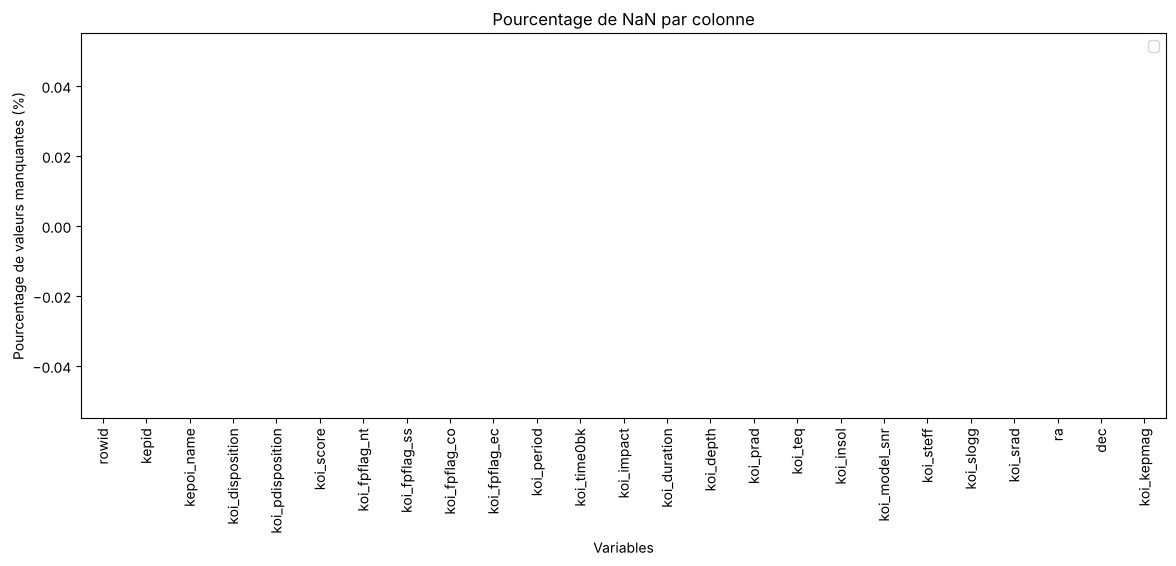

In [32]:
nan_cols = df_cleaned.isna().mean() * 100
plt.figure(figsize=(14,5))
sns.barplot(x=nan_cols.index, y=nan_cols.values)
plt.xticks(rotation=90)
plt.legend()
plt.xlabel("Variables")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Pourcentage de NaN par colonne")
plt.show()

In [33]:
# exportation du dataset nettoyé final
df_cleaned.to_csv("../data/cumulative_cleaned.csv", index=False)

### Interprétation du graphique : Pourcentage de NaN par colonne

Le graphique du pourcentage de valeurs manquantes par colonne met en évidence 
plusieurs comportements caractéristiques du dataset Kepler :

####  1. Colonnes entièrement vides (100 % de NaN)
Les variables *koi_teq_err1* et *koi_teq_err2* présentent 100 % de valeurs 
manquantes. Il s'agit des incertitudes associées à la température d’équilibre 
des planètes. Comme aucune donnée n’est renseignée pour ces colonnes, elles 
ne pourront pas être exploitées et devront être supprimées lors du nettoyage.

####  2. Colonne fortement incomplète (~76 % de NaN)
La variable *kepler_name* affiche environ 76 % de valeurs manquantes. Cela est 
normal : seuls les objets confirmés comme exoplanètes reçoivent un nom officiel 
de type *Kepler-22b*. Les KOIs (Kepler Objects of Interest) non confirmés, qui 
représentent la majorité du dataset, n’ont pas de nom, ce qui explique ce 
taux élevé de NaN.

####  3. Colonne partiellement incomplète (~15 % de NaN)
La variable *koi_score* présente environ 15 % de NaN. Le score n’est attribué 
qu’à certaines observations et peut être manquant lorsque la classification ou 
l'évaluation de l’objet n’a pas été finalisée. Cette colonne reste exploitable, 
mais nécessitera une imputation ou un traitement particulier.

####  4. Colonnes modérément incomplètes (4–6 % de NaN)
De nombreuses colonnes représentant les incertitudes de mesure 
(*koi_srad_err*, *koi_steff_err*, *koi_slogg_err*, *koi_depth_err*, etc.)
présentent entre 4 % et 6 % de NaN. Ce niveau de données manquantes est 
attendu dans un contexte d’observation astronomique et peut généralement être 
géré par une imputation simple ou par une suppression des lignes concernées 
selon les besoins des analyses.

####  5. Colonnes entièrement complètes (0 % de NaN)
Les variables structurelles telles que *kepoi_name*, *ra*, *dec* et *rowid* 
ne contiennent aucune valeur manquante. Elles constituent des identifiants 
fondamentaux, nécessaires pour repérer et indexer chaque objet observé.

### Conclusion 

Le dataset est globalement exploitable, avec une proportion modérée de données 
manquantes dans la majorité des variables. Seules quelques colonnes sont 
totalement inutilisables et devront être supprimées. Cette analyse permet de 
préparer efficacement les étapes suivantes du projet : imputation, nettoyage, 
sélection de variables et application de méthodes avancées (PCA, CCA, 
clustering, classification).

Pour moi, on supprime au-delà de 40 % sauf la colonne name ( mais elle sert a r de toute facon valider si vous êtes ok)


**-----------------------------------------------------------------------------------------------------------------------------------------------------------------**

## Variables catégorielles : valeurs et fréquences

In [34]:
import pandas as pd

# 1. Chargement du dataset
df = pd.read_csv('../data/cumulative.csv')

# 2. Sélection des colonnes à analyser
# A. Automatique : toutes les colonnes contenant du texte
cat_cols = list(df.select_dtypes(include=['object']).columns)

# B. Manuel : ajout des colonnes de drapeaux (entiers binaires 0/1)
flag_cols = ['koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']

# C. Fusion des deux listes
all_cat_cols = cat_cols + flag_cols

print(f"Variables catégorielles détectées : {all_cat_cols}\n")



Variables catégorielles détectées : ['kepoi_name', 'kepler_name', 'koi_disposition', 'koi_pdisposition', 'koi_tce_delivname', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']



Nous allons supprimer les variables : 
- **kepler_name** car ne donne des nom qu'aux objects confirmés comme exo-planète
- **rowid** car objet deja identifié par kepoi_name
- **kepid** par les mêmes arguments
- **koi_teq_err1** car vide 
- **koi_teq_err2** car vide 

In [35]:
all_cat_cols = ['kepoi_name', 'koi_disposition', 'koi_pdisposition', 'koi_tce_delivname', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec']

# 3. Boucle pour afficher les fréquences
for col in all_cat_cols:
    print(f"--- {col} ---")
    
    # Compte des valeurs brutes
    counts = df[col].value_counts()
    
    # Calcul des pourcentages
    percentages = df[col].value_counts(normalize=True) * 100
    
    # Création d'un petit tableau récapitulatif pour l'affichage
    summary = pd.DataFrame({'Fréquence': counts, 'Pourcentage (%)': percentages})
    
    # On affiche seulement les 10 premières valeurs si il y en a trop (ex: noms)
    if len(summary) > 10:
        print(f"Top 10 valeurs les plus fréquentes (sur {len(summary)} total) :")
        print(summary.head(10))
    else:
        print(summary)
    
    print("\n" + "="*40 + "\n")

--- kepoi_name ---
Top 10 valeurs les plus fréquentes (sur 9564 total) :
            Fréquence  Pourcentage (%)
kepoi_name                            
K00752.01           1         0.010456
K00752.02           1         0.010456
K00753.01           1         0.010456
K00754.01           1         0.010456
K00755.01           1         0.010456
K00756.01           1         0.010456
K00756.02           1         0.010456
K00756.03           1         0.010456
K00114.01           1         0.010456
K00757.01           1         0.010456


--- koi_disposition ---
                 Fréquence  Pourcentage (%)
koi_disposition                            
FALSE POSITIVE        5023        52.519866
CONFIRMED             2293        23.975324
CANDIDATE             2248        23.504810


--- koi_pdisposition ---
                  Fréquence  Pourcentage (%)
koi_pdisposition                            
FALSE POSITIVE         5068        52.990381
CANDIDATE              4496        47.009619


--- 

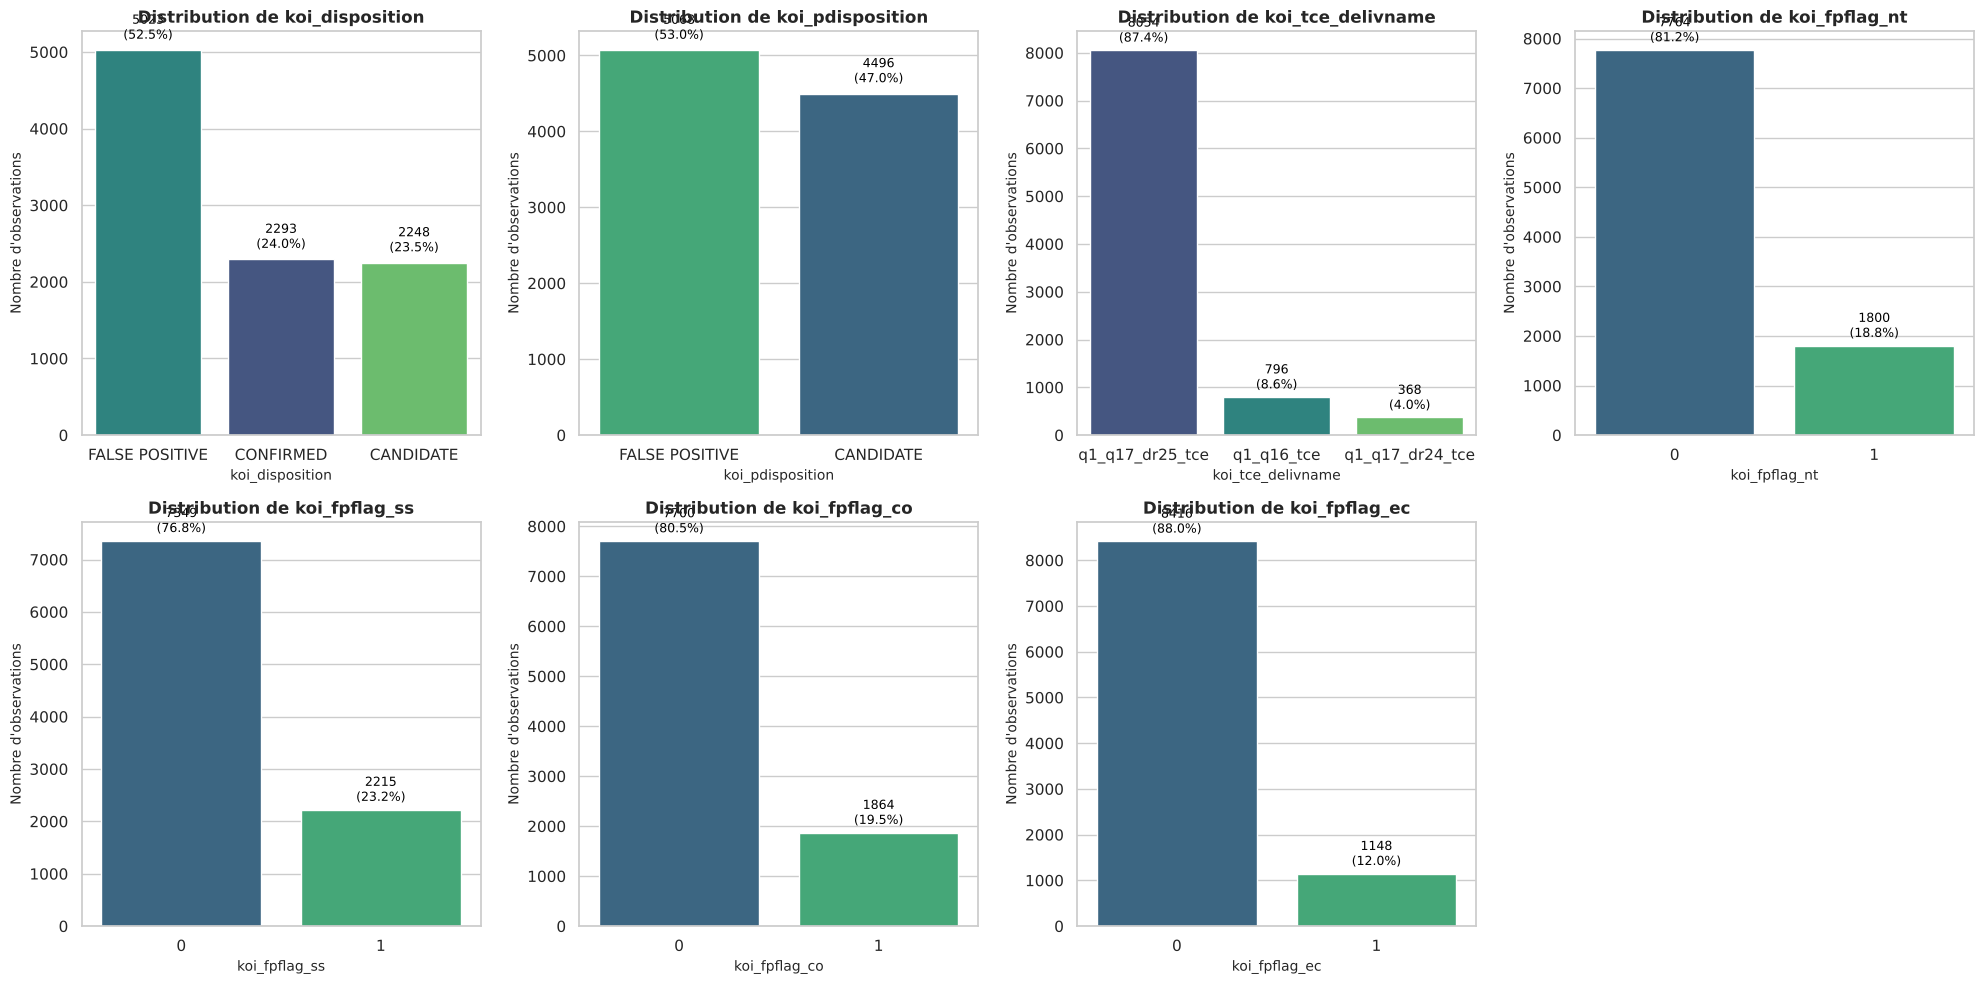

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement des données
df = pd.read_csv('../data/cumulative.csv')

# 2. Liste des variables à visualiser
# On combine les variables textuelles et les drapeaux binaires
cols_to_plot = [
    'koi_disposition', 'koi_pdisposition', 'koi_tce_delivname', # Catégorielles
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec' # Drapeaux (Flags)
]

# 3. Configuration de la figure
# Grille de 2 lignes sur 4 colonnes pour loger les 7 graphiques
plt.figure(figsize=(20, 10))
sns.set_theme(style="whitegrid")

# 4. Boucle de création des graphiques
for i, col in enumerate(cols_to_plot):
    # Positionnement du subplot (i+1 car les indices matplotlib commencent à 1)
    plt.subplot(2, 4, i + 1)
    
    # Création du diagramme à barres
    # hue=col : Requis par les nouvelles versions de Seaborn pour la couleur
    # dodge=False : Garde les barres larges et centrées
    ax = sns.countplot(
        x=col, 
        data=df, 
        order=df[col].value_counts().index, # Tri du plus fréquent au moins fréquent
        palette='viridis',
        hue=col,
        dodge=False
    )
    
    # Suppression de la légende automatique (inutile ici)
    if ax.legend_:
        ax.legend_.remove()
    
    # Mise en forme
    plt.title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Nombre d\'observations', fontsize=10)
    
    # Rotation des étiquettes pour les variables textuelles
    if df[col].dtype == 'object':
        plt.xticks(rotation=45)
    
    # Ajout des annotations (Chiffres et Pourcentages)
    total = len(df[col].dropna())
    for p in ax.patches:
        height = p.get_height()
        # On s'assure que la barre existe avant d'écrire
        if pd.notna(height) and height > 0:
            ax.text(p.get_x() + p.get_width()/2.,   # Position X (centre de la barre)
                    height + (total*0.01),          # Position Y (légèrement au-dessus)
                    f'{int(height)}\n({height/total:.1%})', # Texte: Valeur + (Pourcentage)
                    ha="center", va="bottom", fontsize=9, color='black')

# 5. Nettoyage du dernier emplacement vide (le 8ème subplot)
plt.subplot(2, 4, 8)
plt.axis('off')

# 6. Affichage final optimisé
plt.tight_layout()
plt.show()

- Pour **koi_disposition** :

La variable cible koi_disposition, indiquant le statut officiel de l'objet, révèle un déséquilibre marqué où plus de la moitié des détections (52,5 %) sont classées comme "Faux Positifs", tandis que les planètes confirmées et les candidats potentiels se partagent le reste à parts quasi égales (~24 % chacun).

- Pour **koi_pdisposition** : 

L'histogramme de koi_pdisposition illustre le tri binaire initial effectué par le pipeline automatique, qui sépare les données en deux groupes de taille comparable (47 % de Candidats contre 53 % de Faux Positifs), regroupant ainsi les futures confirmations et les cas incertains sous la même étiquette préliminaire "Candidate".

- Pour **koi_tce_delivname** : 

La variable koi_tce_delivname montre une très forte homogénéité de la source des données, puisque l'écrasante majorité des observations (87,4 %) provient de la version "DR25" (Data Release 25), qui correspond à l'analyse finale et la plus aboutie de la mission Kepler.


- Pour **koi_fpflag_nt** (Not Transit) : 

Ce drapeau est le moins fréquent des quatre (activé dans 18,8 % des cas), indiquant que la grande majorité des signaux détectés présentent bien la forme caractéristique en "U" d'un transit, et ne sont pas rejetés pour cause de forme aberrante.

- Pour **koi_fpflag_ss** (Stellar Eclipse) : 

Activé pour 23,2 % des observations, ce drapeau révèle qu'une part significative des faux positifs est due à des phénomènes d'éclipses stellaires (probablement des étoiles binaires) qui imitent le signal d'une exoplanète.

- Pour **koi_fpflag_co** (Centroid Offset) : 

Avec 19,5 % d'activation, ce drapeau signale qu'environ un cinquième des candidats sont rejetés car la source du signal lumineux s'est déplacée (contamination par une étoile d'arrière-plan), ce qui est un artefact courant dans la photométrie de précision.

- Pour **koi_fpflag_ec** (Ephemeris Match) : 

Ce drapeau est le plus rare (12,0 %), ce qui suggère que la contamination par des objets connus partageant la même période ou orbite (correspondance d'éphémérides) est une cause d'erreur moins fréquente que les problèmes de forme du signal ou de binarité.

**-----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# Boxplots et valeurs aberrantes
Analyse des boxplots et repérage des valeurs aberrantes dans le jeu de données.

In [37]:
import pandas as pd
df=pd.read_csv('../data/cumulative.csv')
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


Récupération des variables numériques

In [38]:
# Récupérer seulement les colonnes numériques
df_numeric = df.select_dtypes(include=['number'])

# Afficher les premières lignes des colonnes numériques
df_numeric.head()

df_numeric_columns = df_numeric.columns.tolist()
df_numeric_columns

['rowid',
 'kepid',
 'koi_score',
 'koi_fpflag_nt',
 'koi_fpflag_ss',
 'koi_fpflag_co',
 'koi_fpflag_ec',
 'koi_period',
 'koi_period_err1',
 'koi_period_err2',
 'koi_time0bk',
 'koi_time0bk_err1',
 'koi_time0bk_err2',
 'koi_impact',
 'koi_impact_err1',
 'koi_impact_err2',
 'koi_duration',
 'koi_duration_err1',
 'koi_duration_err2',
 'koi_depth',
 'koi_depth_err1',
 'koi_depth_err2',
 'koi_prad',
 'koi_prad_err1',
 'koi_prad_err2',
 'koi_teq',
 'koi_teq_err1',
 'koi_teq_err2',
 'koi_insol',
 'koi_insol_err1',
 'koi_insol_err2',
 'koi_model_snr',
 'koi_tce_plnt_num',
 'koi_steff',
 'koi_steff_err1',
 'koi_steff_err2',
 'koi_slogg',
 'koi_slogg_err1',
 'koi_slogg_err2',
 'koi_srad',
 'koi_srad_err1',
 'koi_srad_err2',
 'ra',
 'dec',
 'koi_kepmag']

Les variables numériques retenues sont : koi_score, koi_impact, koi_duration, koi_depth, koi_prad, koi_teq, koi_srad, koi_slogg, koi_insol.

## Boxplots

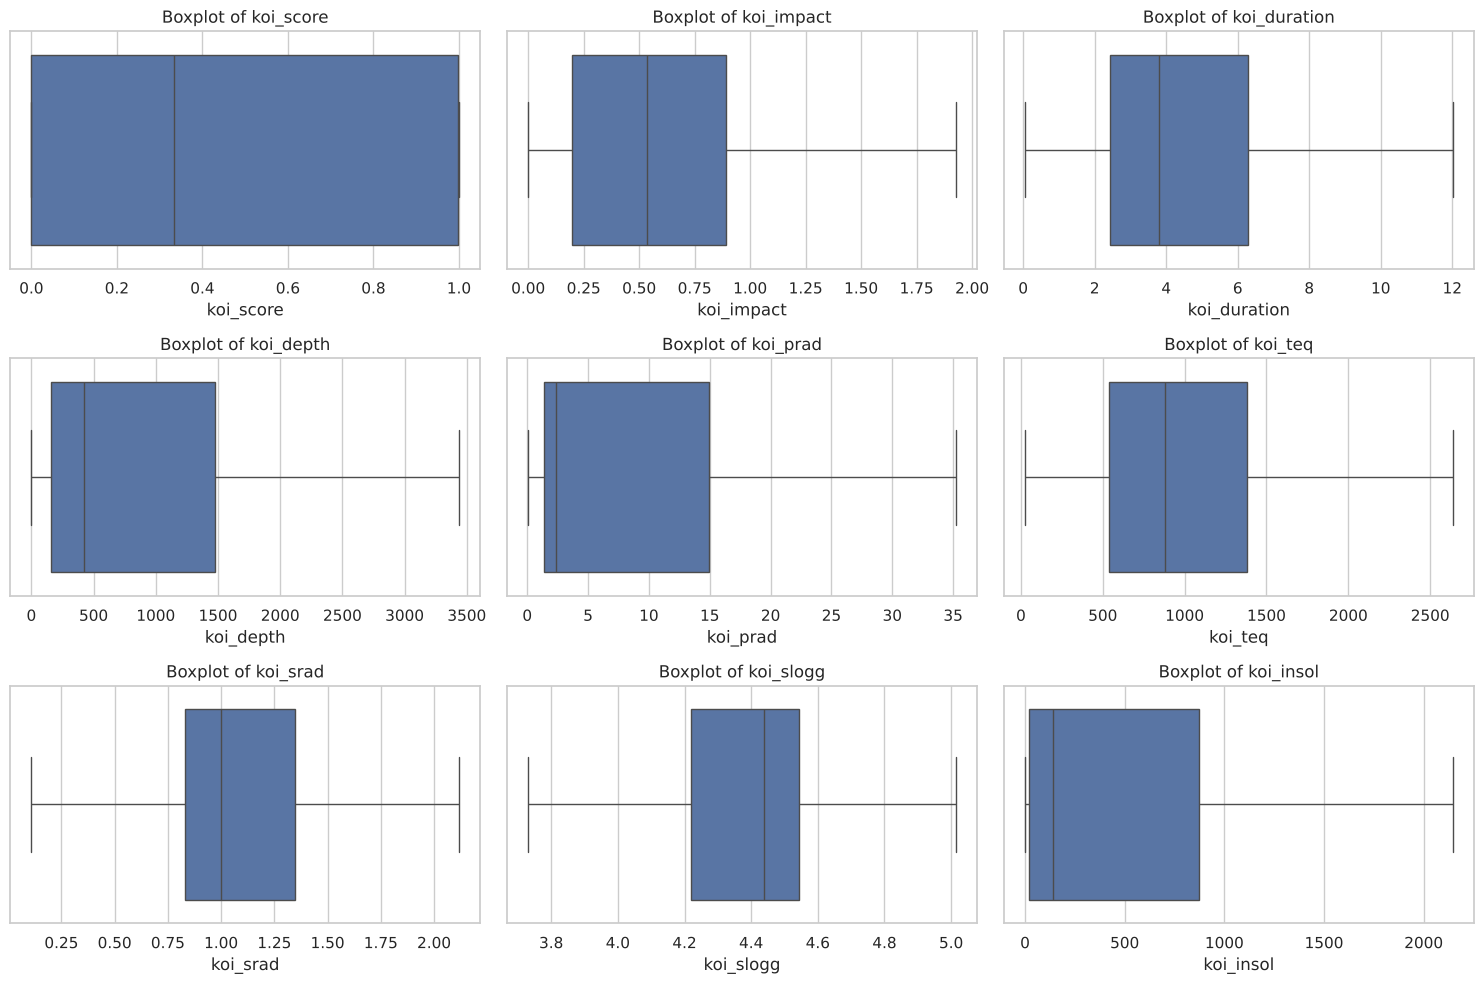

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des variables à analyser
columns = ['koi_score', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 
           'koi_teq', 'koi_srad', 'koi_slogg', 'koi_insol']

# Configuration de la taille de la figure pour afficher les boxplots
plt.figure(figsize=(15, 10))

# Afficher un boxplot pour chaque colonne
for i, col in enumerate(columns, 1):
    plt.subplot(3, 3, i)  # 3 lignes, 3 colonnes
    sns.boxplot(x=df[col], showfliers=False)  # Ne pas afficher les outliers
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

# Ajuster l'espacement entre les sous-graphes
plt.tight_layout()
plt.show()

### Interprétation des boxplots

#### Variable `koi_score`
- Nature : variable continue bornée entre 0 et 1.
- Statistiques : Q1 = 0, médiane ~ 0.33, Q3 = 1.
- Analyse : distribution polarisée aux extrémités (beaucoup de valeurs proches de 0 ou 1), expliquant l'écart interquartile maximal.

#### Variable `koi_impact`
- Nature : variable continue positive (valeurs généralement entre 0 et ~2).
- Statistiques : Q1 ~ 0.2, médiane ~ 0.55, Q3 ~ 0.9.
- Analyse : asymétrie à droite indiquant une plus grande dispersion vers des valeurs élevées, malgré une boîte centrale concentrée sous 0.9.

#### Variable `koi_duration`
- Nature : durée du transit, variable continue positive.
- Analyse : forte asymétrie positive (longue queue à droite), indiquant des durées exceptionnellement longues pour une minorité d'événements.

#### Variable `koi_depth`
- Nature : profondeur du transit.
- Analyse : distribution très asymétrique à droite : la majorité des transits sont peu profonds, quelques valeurs extrêmes indiquent possibles erreurs ou événements stellaires (éclipses profondes).

#### Variable `koi_prad`
- Nature : rayon planétaire.
- Analyse : forte asymétrie à droite ; la plupart des objets ont un petit rayon tandis que certains points extrêmes suggèrent des erreurs ou des faux positifs (objets impossiblement grands).

#### Variable `koi_teq`
- Nature : température d'équilibre (en Kelvin).
- Analyse : asymétrie positive avec une longue queue vers de hautes températures, compatible avec la présence d'objets très chauds (ou d'erreurs de mesure).

#### Variable `koi_srad`
- Nature : rayon stellaire (en rayons solaires).
- Analyse : distribution centrée autour de 1, avec une légère asymétrie positive due à la présence d'étoiles plus grandes que le Soleil.

#### Variable `koi_slogg`
- Nature : log(g) de la gravité de surface stellaire.
- Analyse : asymétrie négative (queue à gauche) : la majorité correspond à des étoiles de type naine, les valeurs faibles renvoient aux géantes.

#### Variable `koi_insol`
- Nature : flux d'insolation sur la planète.
- Analyse : très asymétrique à droite : la plupart des valeurs sont faibles à modérées, mais quelques cas extrêmes indiquent des objets extrêmement irradiés (ou des erreurs).

# Valeurs aberrantes
Pour visualiser les valeurs aberrantes, afficher les boxplots avec les points (outliers).

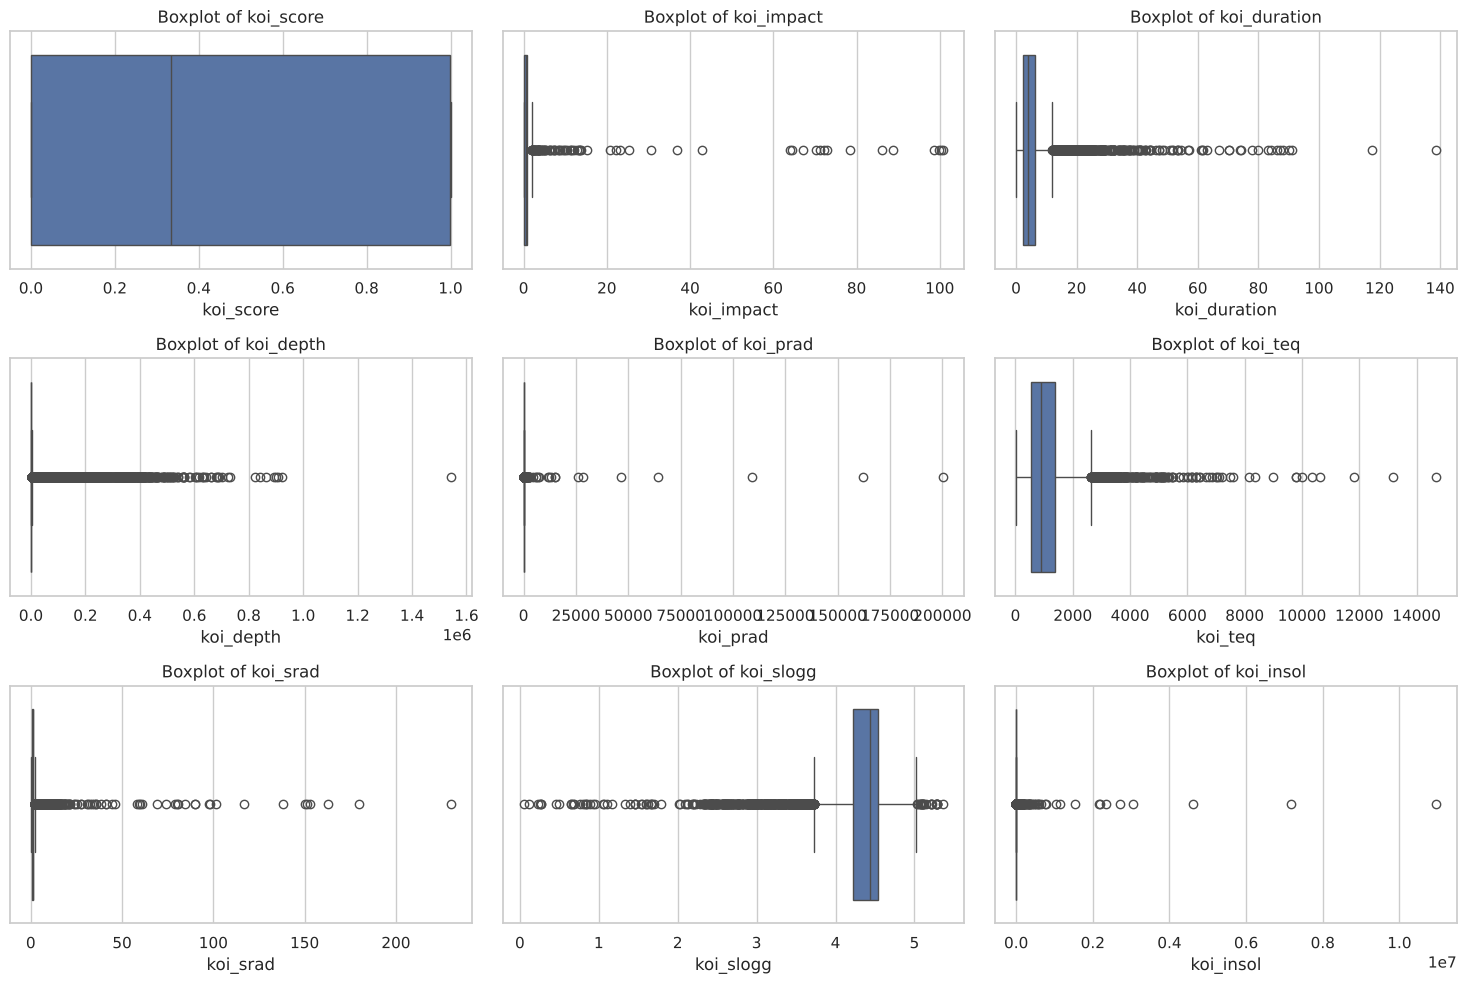

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des variables à
columns = ['koi_score', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 
           'koi_teq', 'koi_srad', 'koi_slogg', 'koi_insol']

# Configuration de la taille de la figure pour afficher les boxplots
plt.figure(figsize=(15, 10))

# Afficher un boxplot pour chaque colonne
for i, col in enumerate(columns, 1):
    plt.subplot(3, 3, i)  # 3 lignes, 3 colonnes
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

# Ajuster l'espacement entre les sous-graphes
plt.tight_layout()
plt.show()

## Analyse détaillée des valeurs aberrantes (9 variables)

L'analyse visuelle de la grille de boxplots révèle que la quasi-totalité des variables physiques souffrent d'un écrasement de distribution dû à des valeurs extrêmes (outliers) disproportionnées.

### 1. Les "Absurdités" Physiques (Nettoyage prioritaire)
Ces variables contiennent des valeurs qui défient la physique planétaire ou résultent d'erreurs de mesure manifestes :

* `koi_prad` (Rayon planétaire) : C'est le cas le plus critique. La boîte est invisible. Des points atteignent 200 000 rayons terrestres. Pour référence, le Soleil fait ~109 rayons terrestres. Ces objets sont plus gros que des étoiles, ce sont donc des erreurs ou des faux positifs évidents.
* `koi_insol` (Insolation) : Des valeurs grimpent jusqu'à 10^7 (10 millions de fois le flux terrestre). Aucune exoplanète observable ne peut survivre à un tel flux sans être vaporisée ou être en réalité une étoile.
* `koi_depth` : Des valeurs très élevées (≈ 1,5 million) indiquent probablement une éclipse d’étoiles binaires ou une erreur, car une planète bloque normalement bien moins de 1 % de la lumière.

### 2. Les Anomalies Géométriques
* `koi_impact` : La médiane est proche de 0, mais des valeurs montent jusqu'à 100. Géométriquement, un paramètre d'impact > 1 signifie (généralement) que la planète ne passe pas devant l'étoile ("grazing transit" ou non-transit). Ces valeurs indiquent des configurations orbitales douteuses. () 
(C'est une aberration physique car le télescope Kepler fonctionne par la méthode des transits (il détecte l'ombre d'une planète passant devant l'étoile), or un impact de 100 signifie que l'objet passe géométriquement très loin à côté de l'étoile sans jamais bloquer sa lumière, ce qui rend toute détection impossible)

### 3. Les Outliers Stellaires (Géantes vs Naines)
Ici, les outliers ne sont pas forcément des erreurs, mais représentent une population d'étoiles différente (Géantes) par rapport à la majorité (Naines type Soleil) :

* `koi_srad` (Rayon étoile) : Une majorité autour de 1 (Soleil), mais des outliers > 200. Ce sont des étoiles géantes rouges.
* `koi_slogg` (Gravité) : Comportement inversé. Les outliers partent vers la gauche (valeurs faibles < 3). Cela correspond physiquement aux étoiles géantes mentionnées ci-dessus (très volumineuses = faible gravité de surface).
* `koi_teq` (Température) : Des températures atteignant 14 000 K. C'est plus chaud que la plupart des étoiles (le Soleil est à 5778 K). Il s'agit probablement d'étoiles compagnons très chaudes et non de planètes.

### 4. La Distribution Étalée (Naturelle)
* `koi_duration` : La distribution est moins écrasée que les autres. Les outliers (jusqu'à 140h) sont rares mais possibles pour des planètes à orbite très large.

### 5. L'Exception "Propre"
* `koi_score` : C'est la seule variable sans valeurs aberrantes. Elle occupe toute la plage [0, 1] de manière valide, ce qui confirme son rôle de variable de classification (probabilité) et non de mesure physique.

# Distribution
Analyse des distributions des variables sélectionnées.

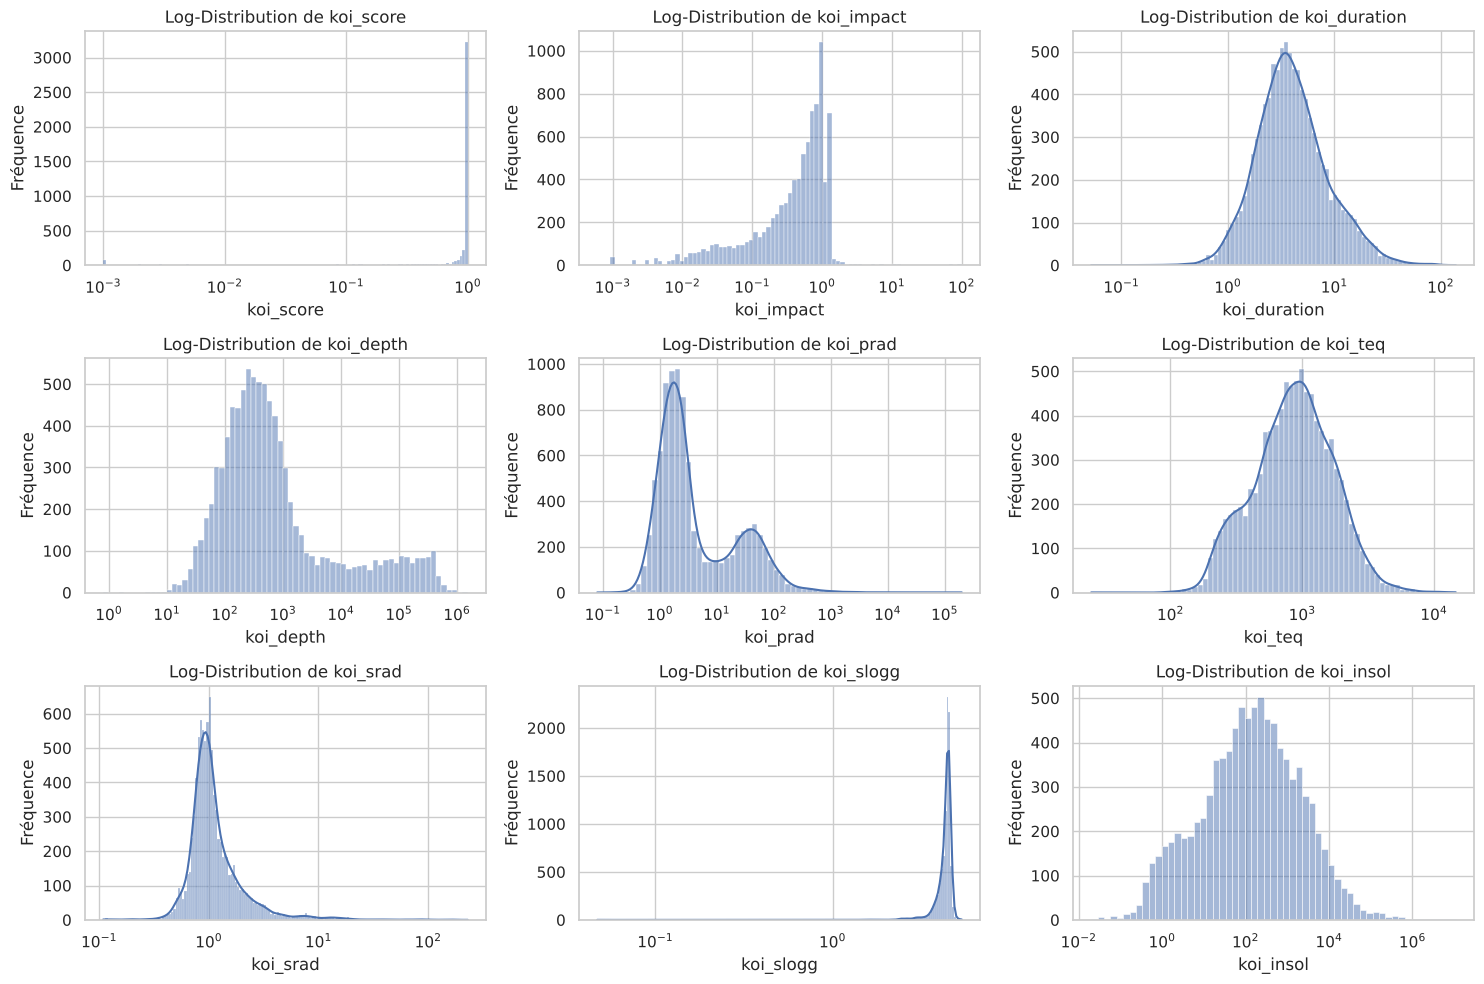

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de la taille de la figure
plt.figure(figsize=(15, 10))

# Tracer un histogramme avec échelle logarithmique
for i, col in enumerate(columns, 1):
    plt.subplot(3, 3, i)  # 3 lignes, 3 colonnes
    
    # log_scale=True permet de gérer les écarts immenses et facilite le calcul du KDE
    # NOTE: Les valeurs <= 0 seront ignorées ou averties par Seaborn en mode log
    sns.histplot(df[col], kde=True, log_scale=True)
    
    plt.title(f'Log-Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

## Analyse des distributions (histogrammes et densités)

Les histogrammes confirment deux comportements principaux :

1) Distributions écrasées :
- `koi_prad`, `koi_depth`, `koi_insol` et `koi_impact` présentent un axe X étiré par des outliers extrêmes, ce qui écrase la visibilité de la distribution principale.

2) Distributions asymétriques :
- `koi_teq` et `koi_duration` montrent une forte asymétrie positive (queue à droite), typique de lois log-normales en astrophysique.

Cas particulier :
- `koi_score` : distribution bimodale (pics proches de 0 et 1), indiquant peu de cas ambigus.
- `koi_slogg` : asymétrie négative liée à la présence conjointe d'étoiles naines et géantes.

Conclusion : aucune variable ne suit une loi normale; il faudra appliquer des transformations ou filtrages adaptés avant modélisation.

# Heatmap

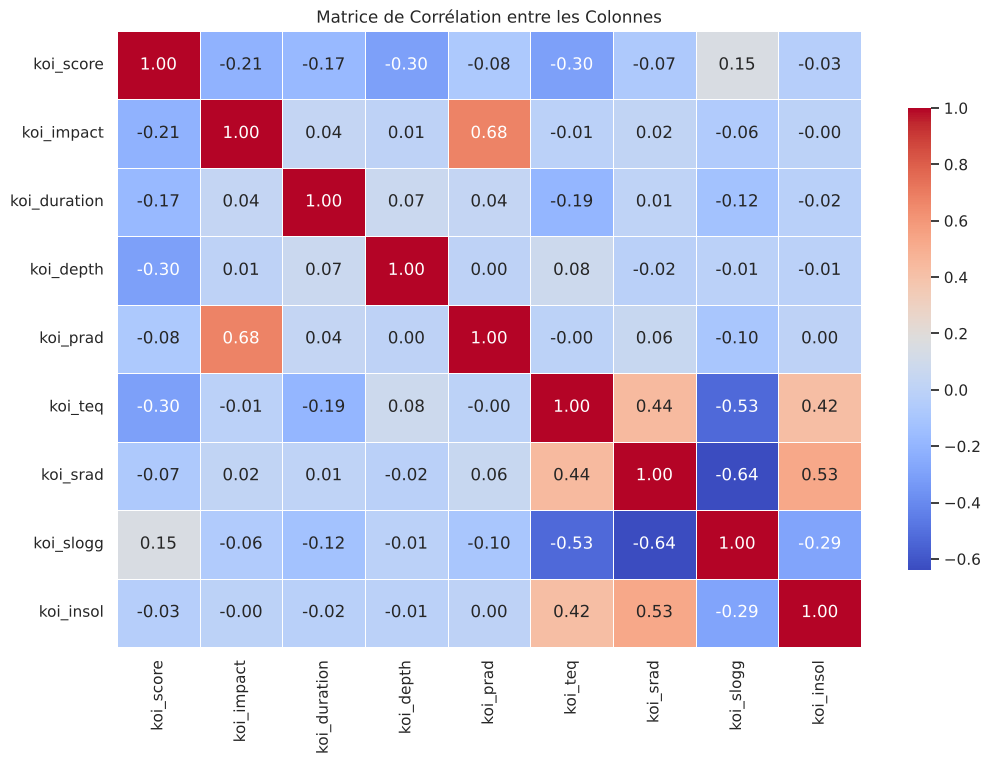

In [42]:
# Calculer la matrice de corrélation pour les colonnes sélectionnées
corr_matrix = df[columns].corr()

# Créer la heatmap
plt.figure(figsize=(12, 8))  # Taille de la figure
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.75})

# Ajouter un titre
plt.title('Matrice de Corrélation entre les Colonnes')

# Afficher la heatmap
plt.show()

### Analyse de la matrice de corrélation

Cette matrice met en évidence des dépendances linéaires :

- Multicolinéarité physique : lien notable entre `koi_impact` et `koi_prad`.
- Paramètres stellaires fortement corrélés : `koi_srad` est inversement corrélé à `koi_slogg` (cohérent physiquement).
- Lien avec la cible (`koi_score`) : corrélations linéaires modérées à faibles (|r| ≤ 0.3). `koi_depth` et `koi_teq` semblent les plus discriminants (corrélations négatives), indiquant que la frontière décisionnelle est probablement non linéaire.

Encodage

On encode les 3 variables catégorielles retenues.

In [43]:
#koi disposition
df_encoded = pd.get_dummies(df, columns=['koi_disposition'], prefix='target', dtype=int)
df_encoded[['target_CANDIDATE', 'target_CONFIRMED', 'target_FALSE POSITIVE']].head()


,target_CANDIDATE,target_CONFIRMED,target_FALSE POSITIVE
0,0,1,0
1,0,1,0
2,0,0,1
3,0,0,1
4,0,1,0


In [44]:
#disposititon
df = pd.get_dummies(df, columns=['koi_pdisposition'], prefix='p_disposition', dtype=int)
df[['p_disposition_CANDIDATE', 'p_disposition_FALSE POSITIVE']].head()

,p_disposition_CANDIDATE,p_disposition_FALSE POSITIVE
0,1,0
1,1,0
2,0,1
3,0,1
4,1,0


In [45]:
df = pd.get_dummies(df, columns=['koi_tce_delivname'], prefix='tce', dtype=int)
new_cols = [col for col in df.columns if col.startswith('tce_')]
df[new_cols].head()

,tce_q1_q16_tce,tce_q1_q17_dr24_tce,tce_q1_q17_dr25_tce
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1


**-----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# **PCA**

--- Asymétrie (Skewness) ---
Si > 1 : log recommandé ; si > 10 : log nécessaire
koi_prad         73.430607
koi_insol        48.023834
koi_srad         20.640316
koi_impact       14.956023
koi_duration      6.599953
koi_time0bk       5.101800
koi_model_snr     4.948080
koi_depth         4.484273
koi_period        4.002212
koi_teq           3.635795
koi_fpflag_nt     2.354357
koi_fpflag_ec     2.133796
koi_fpflag_co     1.365084
koi_fpflag_ss     1.054572
koi_steff         0.748787
dec               0.164375
koi_score         0.044192
ra               -0.302521
koi_kepmag       -0.845721
koi_slogg        -3.662029
dtype: float64 



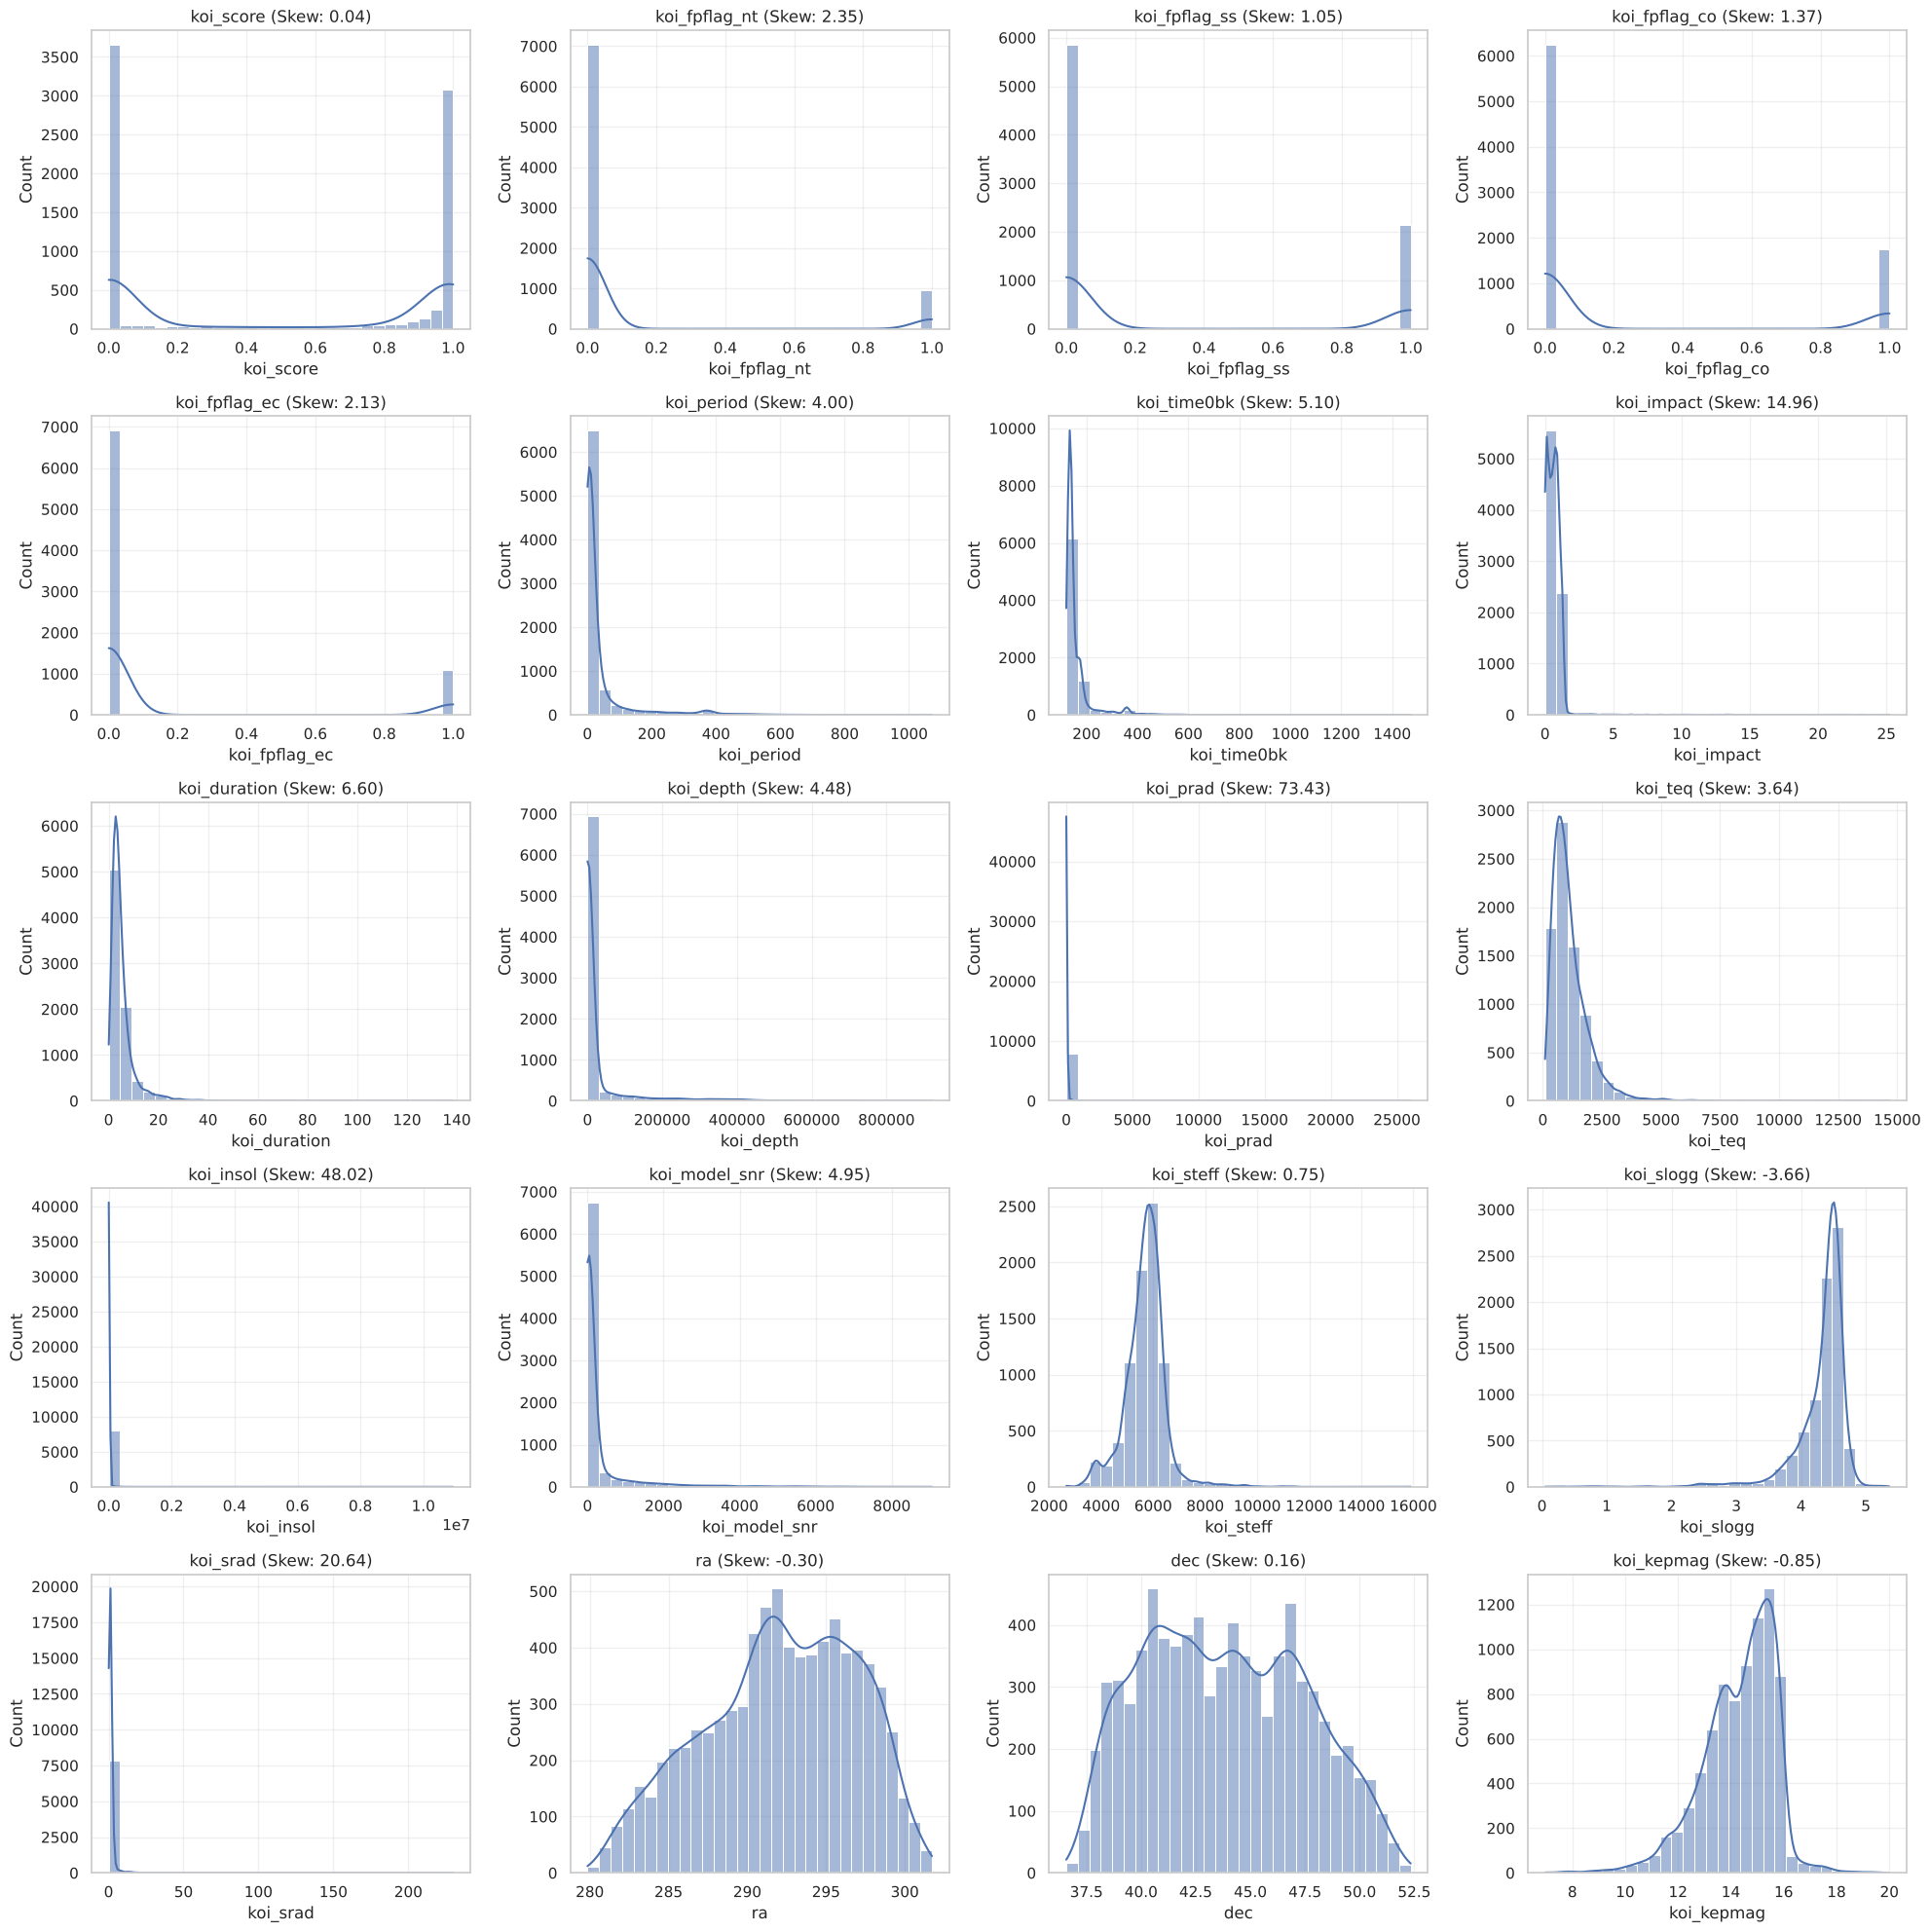

--- Vérification des extrêmes ---
                       mean          50%          75%           max  \
koi_fpflag_nt      0.118964     0.000000     0.000000  1.000000e+00   
koi_fpflag_co      0.218164     0.000000     0.000000  1.000000e+00   
koi_fpflag_ec      0.135226     0.000000     0.000000  1.000000e+00   
koi_insol       8124.301745   183.325000  1003.577500  1.094755e+07   
koi_prad          27.918302     2.470000    19.702500  2.604290e+04   
koi_depth      26648.655679   449.150000  1996.200000  9.216700e+05   
koi_srad           1.713651     0.997000     1.316000  2.299080e+02   
koi_model_snr    294.795334    27.500000   100.075000  9.054700e+03   
koi_period        37.117158     7.582527    23.815564  1.071233e+03   
koi_impact         0.618850     0.582500     0.909000  2.522400e+01   
koi_duration       5.370080     3.733650     5.959750  1.385400e+02   
koi_teq         1142.014761   938.000000  1435.000000  1.466700e+04   
koi_time0bk      157.654472   135.954945   

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/cumulative_cleaned.csv")

features = [
    'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth',
    'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff',
    'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag'
]

skewness = df[features].skew().sort_values(ascending=False)
print("--- Asymétrie (Skewness) ---")
print("Si > 1 : log recommandé ; si > 10 : log nécessaire")
print(skewness, "\n")

all_cols = features
n_cols = 4
n_rows = (len(all_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 4 * n_rows))
for i, col in enumerate(all_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"{col} (Skew: {df[col].skew():.2f})")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("--- Vérification des extrêmes ---")
desc = df[features].describe().T
desc['Ratio_Max_75%'] = desc['max'] / desc['75%']
print(desc[['mean', '50%', '75%', 'max', 'Ratio_Max_75%']].sort_values('Ratio_Max_75%', ascending=False))

--- Application de log1p sur 20 variables (TOUTES) ---
Transformations terminées.

--- Skewness après log ---
koi_srad         4.442882
koi_time0bk      2.759113
koi_fpflag_nt    2.354357
koi_fpflag_ec    2.133796
koi_fpflag_co    1.365084
koi_model_snr    1.182805
koi_prad         1.129003
koi_impact       1.066659
koi_fpflag_ss    1.054572
koi_depth        1.050652
koi_duration     0.949876
koi_period       0.763897
koi_insol        0.191798
dec              0.044004
koi_score        0.016450
koi_teq          0.000197
ra              -0.331712
koi_steff       -0.614870
koi_kepmag      -1.315328
koi_slogg       -6.398777
dtype: float64 

--- Vérification des extrêmes (après log) ---
                   mean       50%       75%        max  Ratio_Max_75%
koi_fpflag_nt  0.082460  0.000000  0.000000   0.693147            inf
koi_fpflag_co  0.151219  0.000000  0.000000   0.693147            inf
koi_fpflag_ec  0.093732  0.000000  0.000000   0.693147            inf
koi_srad       0.793197  0.

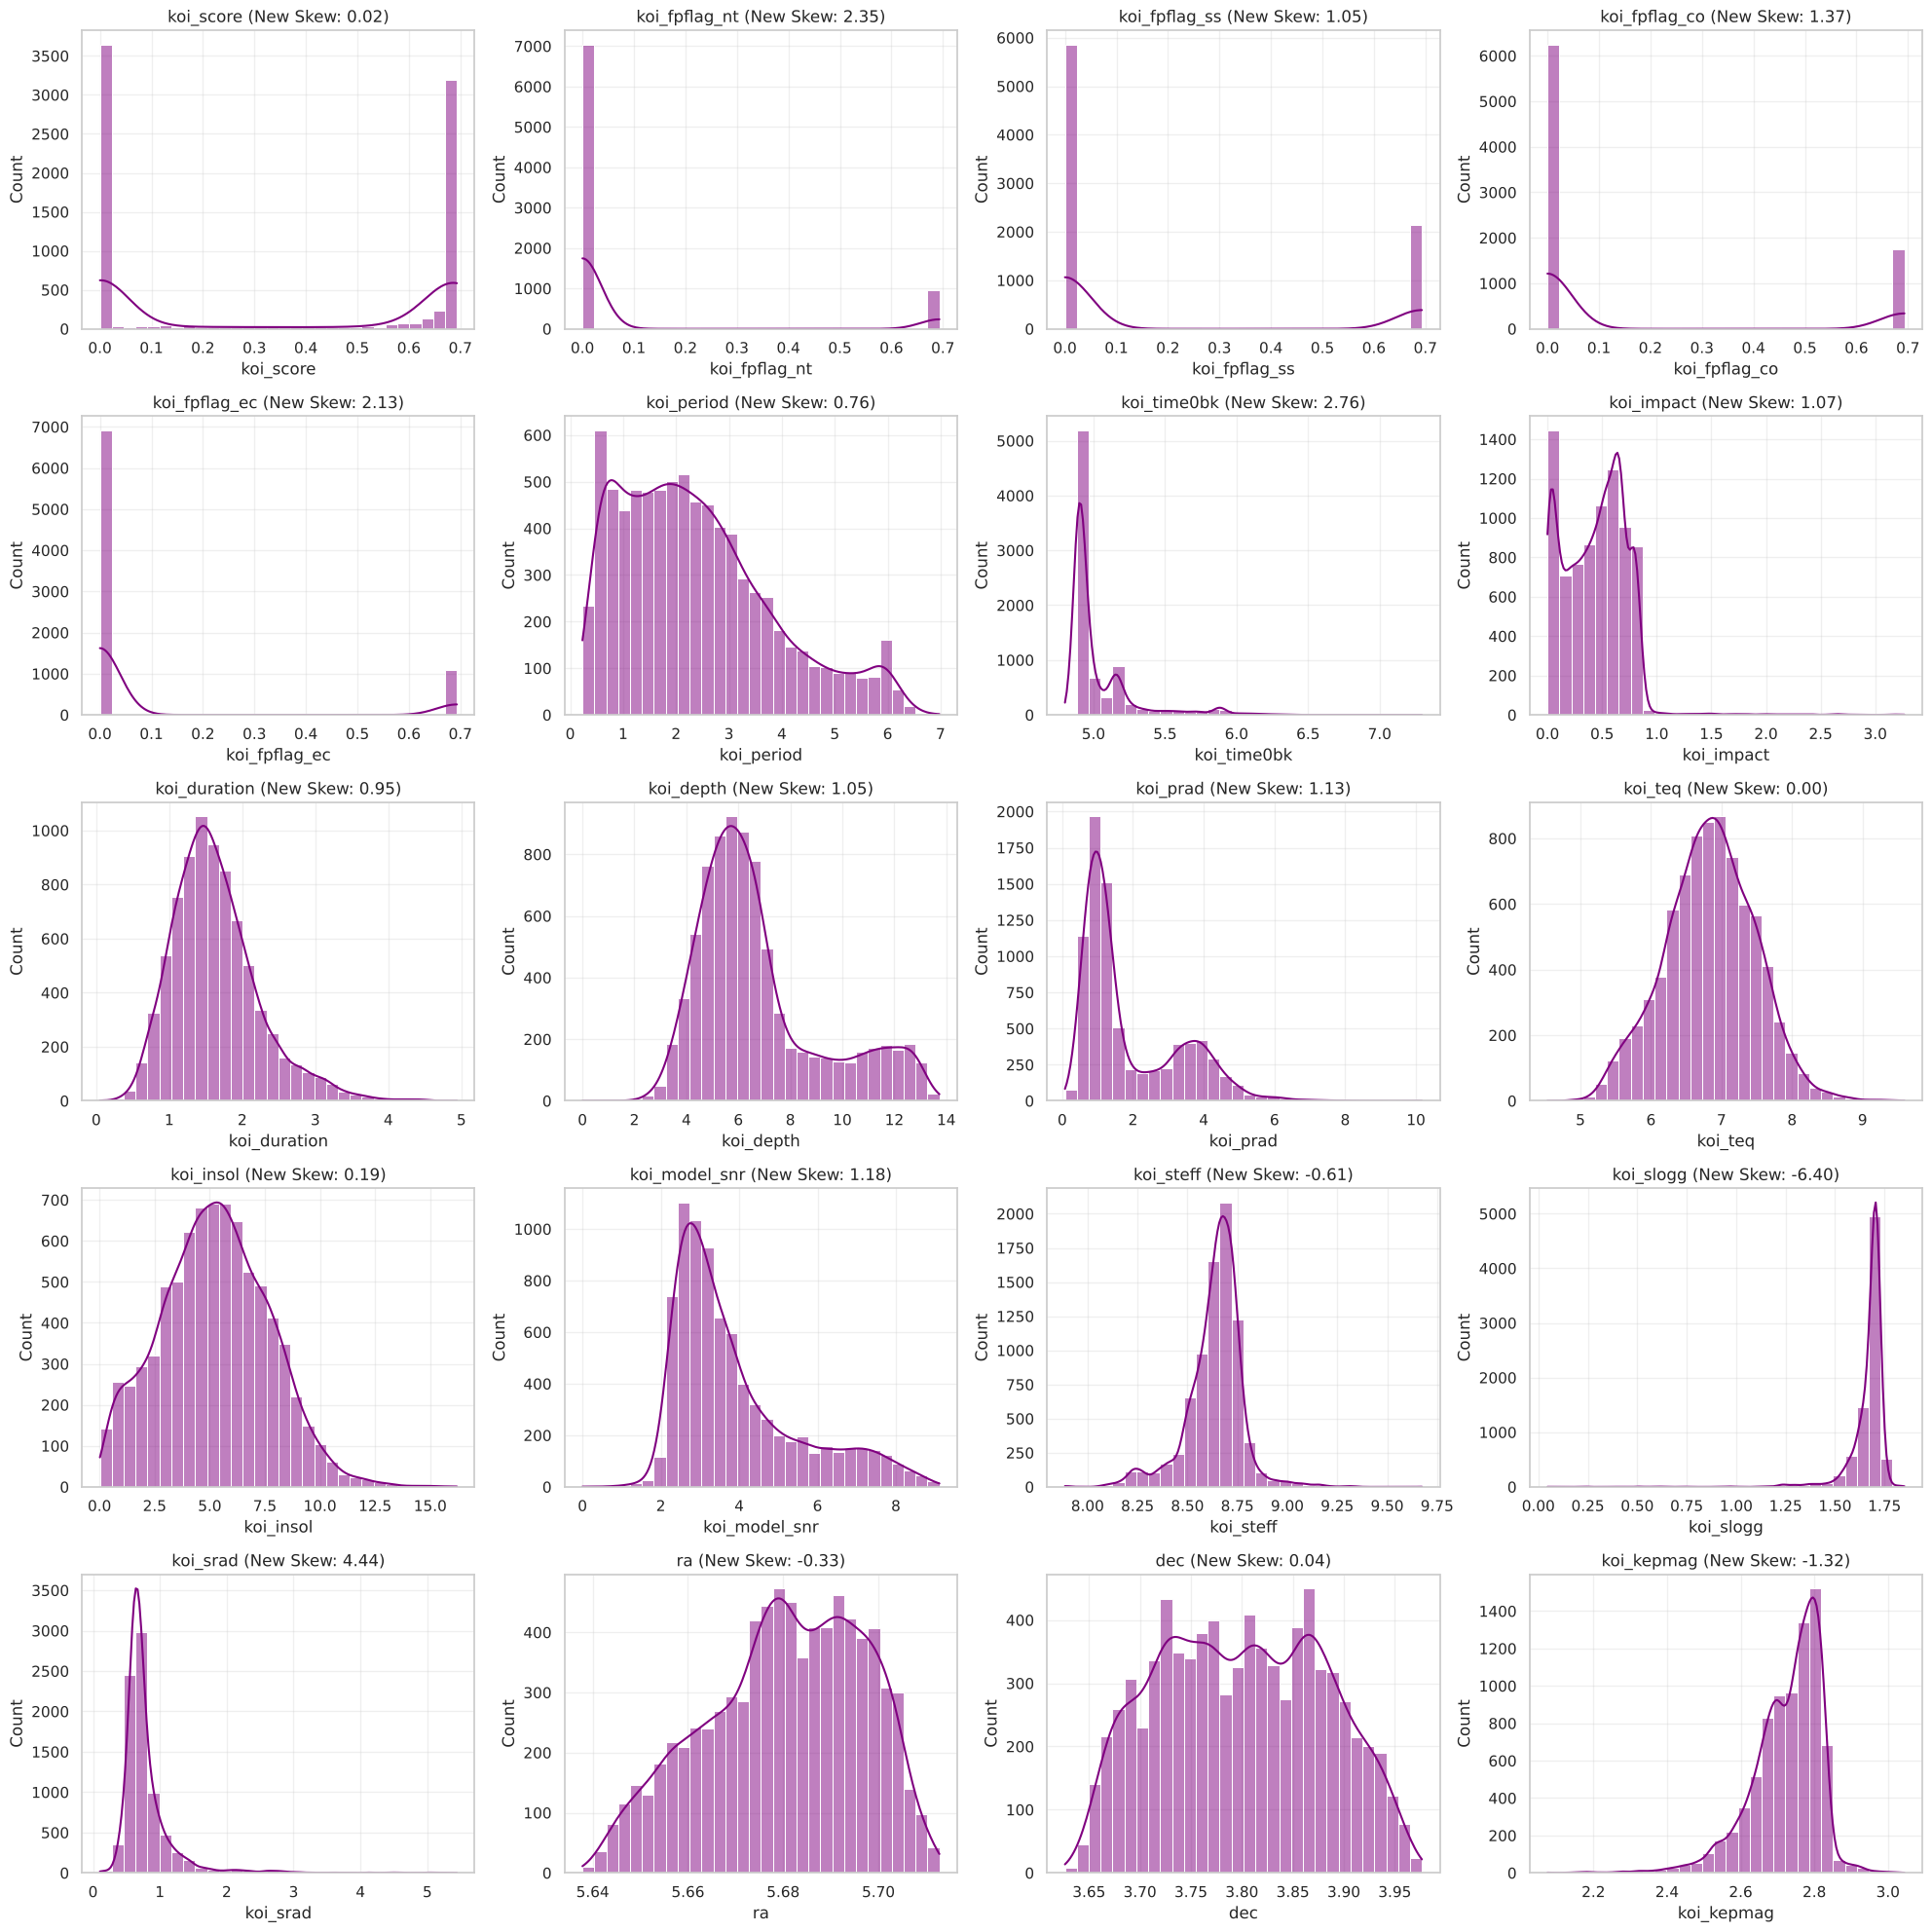

In [47]:
features = [
    'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth',
    'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff',
    'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag'
]


cols_to_log = features

print(f"--- Application de log1p sur {len(cols_to_log)} variables (TOUTES) ---")
for col in cols_to_log:
    # Sécurité : Si une variable a des valeurs <= -1 (ex: dec), le log donnerait NaN.
    # On décale donc la distribution pour qu'elle commence à 0.
    if df[col].min() <= -1:
        print(f"  > Décalage de '{col}' (min={df[col].min()}) pour permettre le log.")
        df[col] = df[col] - df[col].min()
    
    df[col] = np.log1p(df[col])
print("Transformations terminées.\n")

skewness_new = df[features].skew().sort_values(ascending=False)
print("--- Skewness après log ---")
print(skewness_new, "\n")

print("--- Vérification des extrêmes (après log) ---")
desc = df[features].describe().T
desc['Ratio_Max_75%'] = desc['max'] / desc['75%']
print(desc[['mean', '50%', '75%', 'max', 'Ratio_Max_75%']].sort_values('Ratio_Max_75%', ascending=False))

all_cols = features
n_cols = 4
n_rows = (len(all_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(20, 4 * n_rows))
for i, col in enumerate(all_cols):
    plt.subplot(n_rows, n_cols, i+1)
    # Couleur changée pour distinguer visuellement
    sns.histplot(df[col], kde=True, bins=30, color='purple')
    plt.title(f"{col} (New Skew: {df[col].skew():.2f})")
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Les valeurs -inf sont normales (division par zéro).

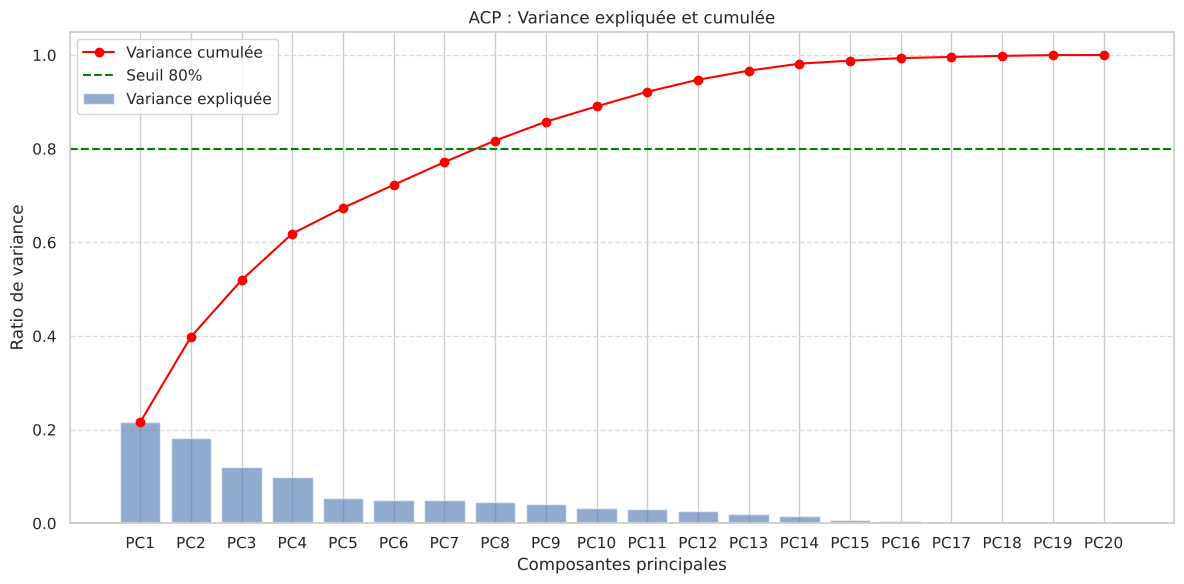

--> Conserver 8 composantes pour 80% d'information.



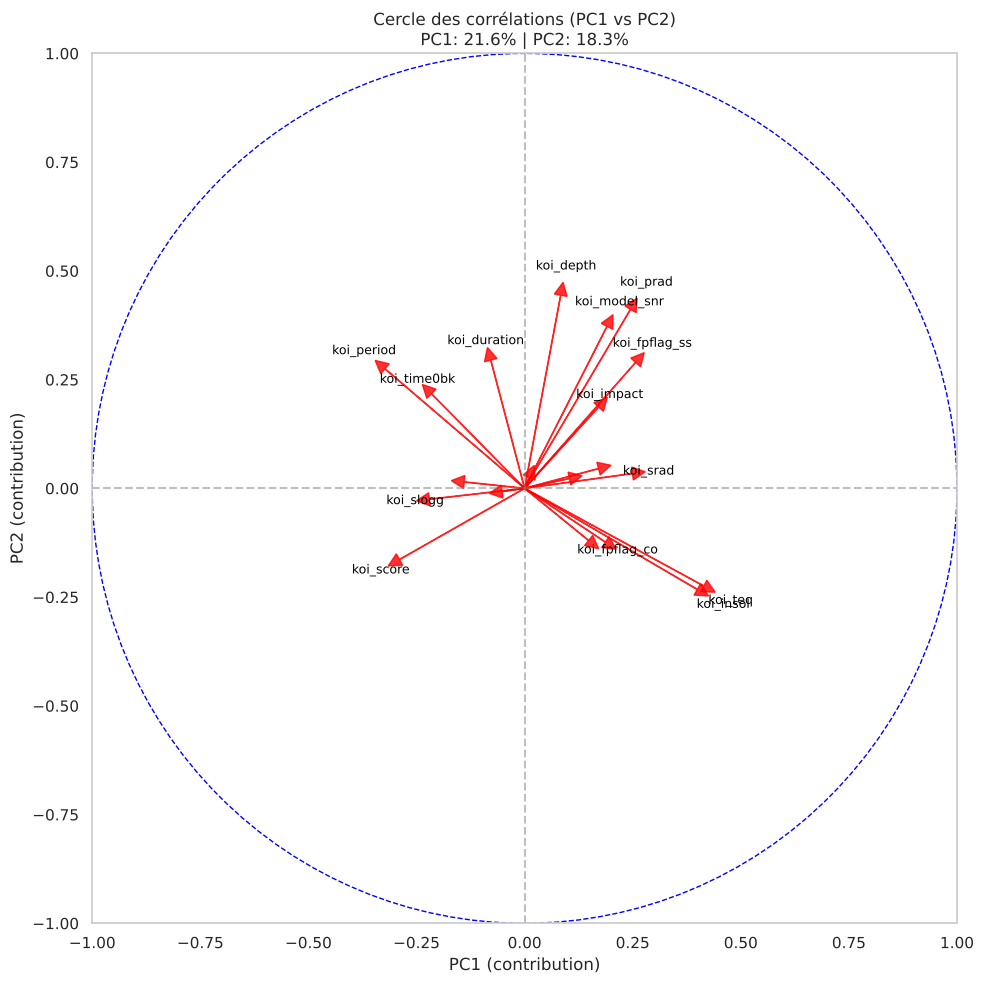

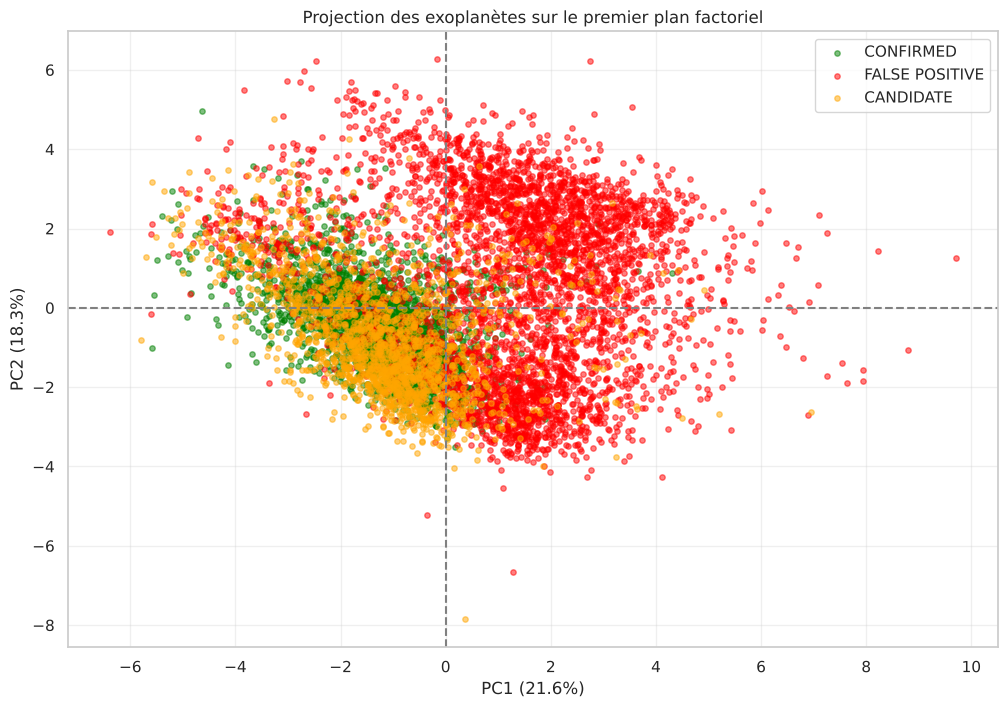

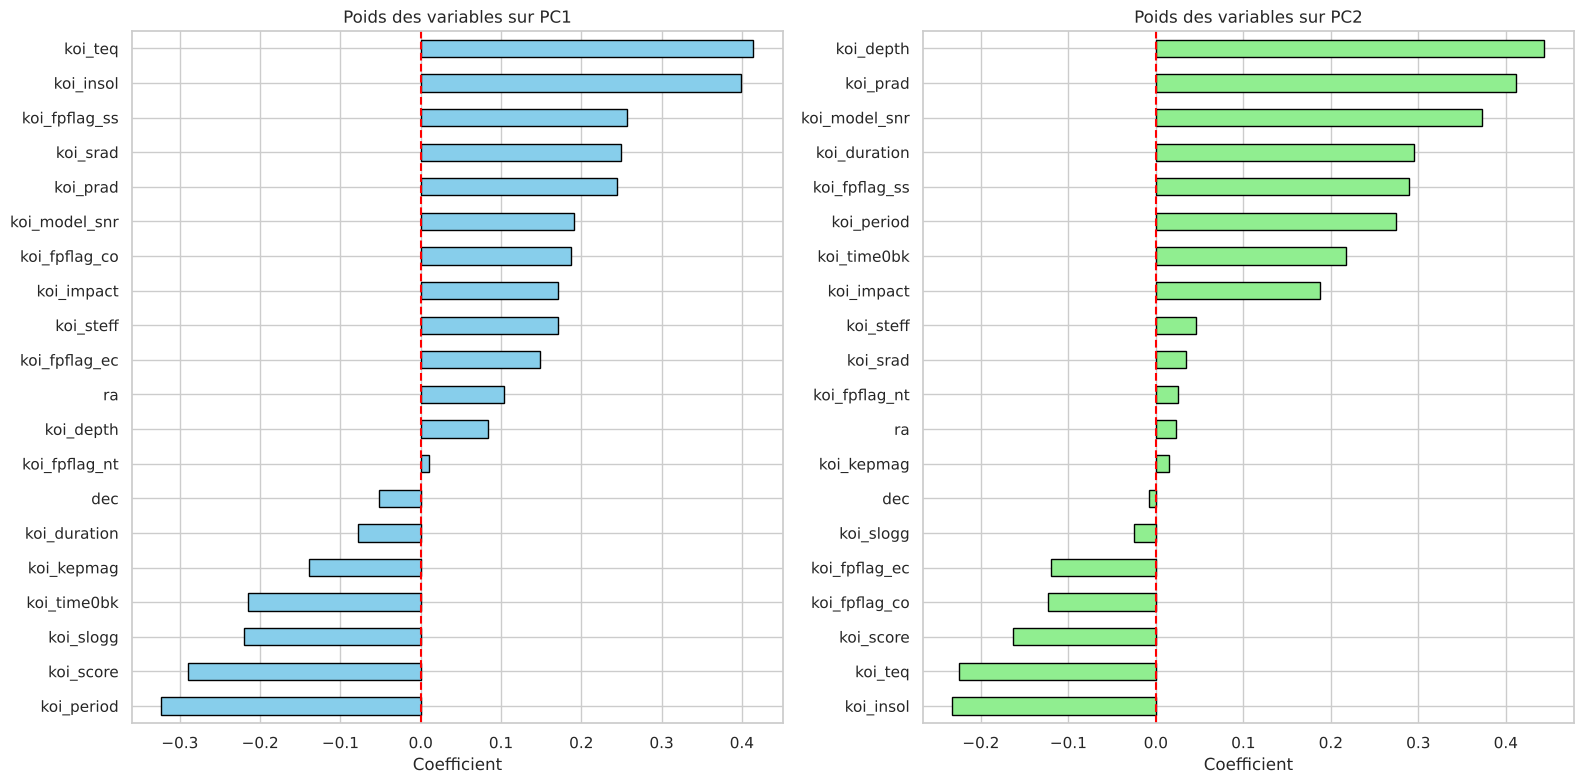


--- Tableau des Cos² (Qualité de représentation) ---
                 PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
koi_score      0.361  0.098  0.015  0.332  0.001  0.000  0.017  0.005
koi_fpflag_nt  0.000  0.002  0.111  0.240  0.025  0.009  0.113  0.465
koi_fpflag_ss  0.285  0.306  0.112  0.000  0.005  0.000  0.000  0.054
koi_fpflag_co  0.151  0.056  0.027  0.449  0.027  0.003  0.004  0.055
koi_fpflag_ec  0.095  0.052  0.013  0.442  0.005  0.002  0.010  0.072


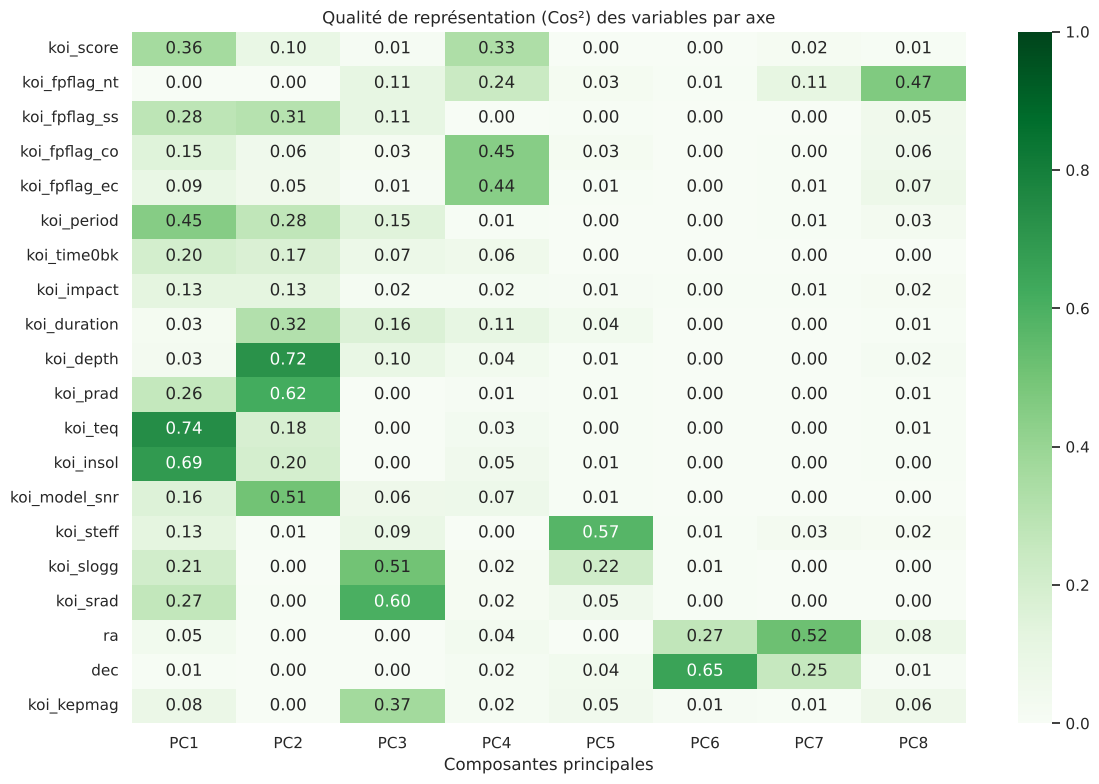

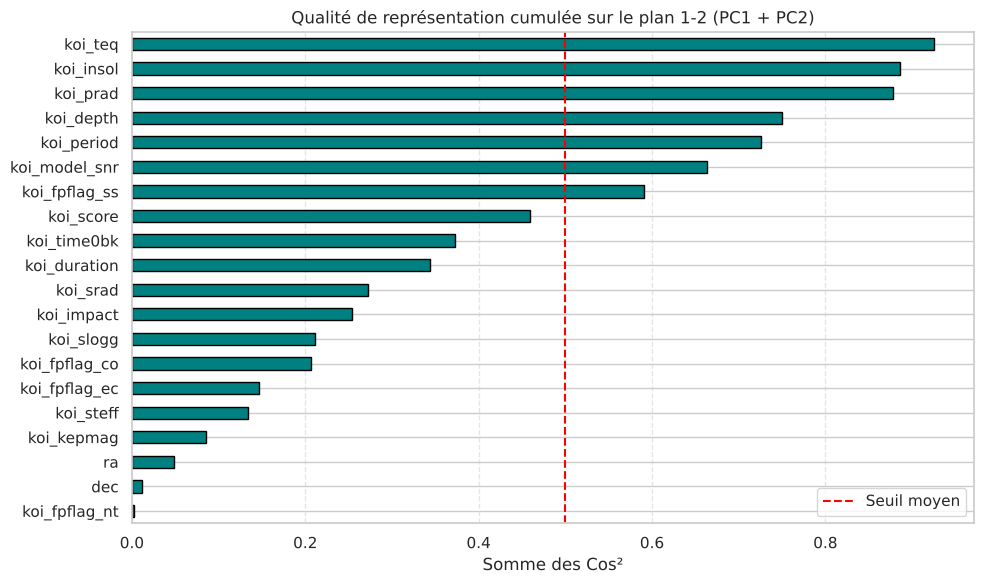


--- Tableau des Contributions (%) ---
Interprétation : Si la valeur est > au seuil moyen, la variable est déterminante.
                PC1   PC2   PC3    PC4   PC5   PC6    PC7    PC8
koi_score      8.37  2.68  0.62  16.76  0.08  0.00   1.72   0.58
koi_fpflag_nt  0.01  0.06  4.57  12.11  2.28  0.96  11.63  50.64
koi_fpflag_ss  6.59  8.38  4.64   0.00  0.43  0.00   0.05   5.90
koi_fpflag_co  3.49  1.53  1.10  22.63  2.45  0.29   0.43   5.99
koi_fpflag_ec  2.19  1.44  0.53  22.29  0.49  0.25   1.00   7.84


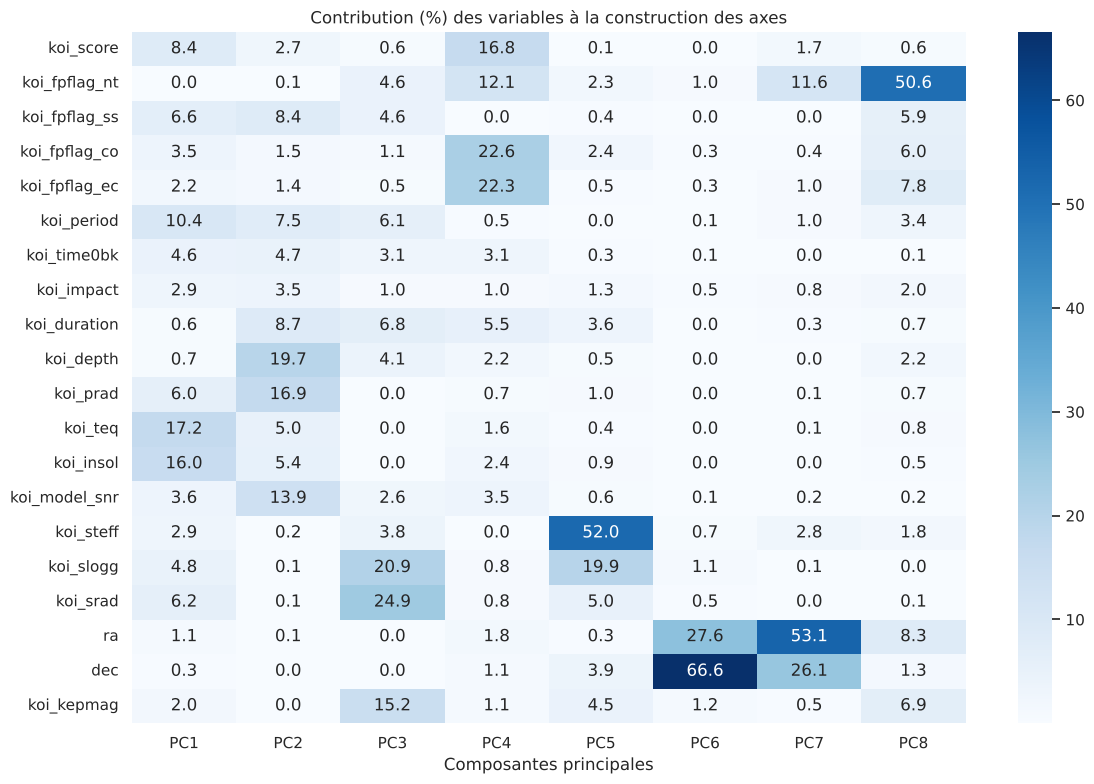

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Préparation
# df est déjà chargé plus haut
features = [
    'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth',
    'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff',
    'koi_slogg', 'koi_srad', 'ra', 'dec', 'koi_kepmag'
]

X = df[features].copy()
y = df['koi_disposition']

cols_to_log = [
    'koi_insol', 'koi_prad', 'koi_depth', 'koi_srad',
    'koi_model_snr', 'koi_period', 'koi_impact',
    'koi_duration', 'koi_teq', 'koi_time0bk'
]
for col in cols_to_log:
    X[col] = np.log1p(X[col])

X = X.dropna()
y = y.loc[X.index]

# Standardisation et PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_projected = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Scree plot
plt.figure(figsize=(12, 6))
bar_labels = [f'PC{i+1}' for i in range(len(features))]
plt.bar(bar_labels, explained_variance, alpha=0.6, label='Variance expliquée')
plt.plot(bar_labels, cumulative_variance, marker='o', color='red', label='Variance cumulée')
plt.axhline(y=0.80, color='green', linestyle='--', label='Seuil 80%')
plt.title('ACP : Variance expliquée et cumulée')
plt.xlabel('Composantes principales')
plt.ylabel('Ratio de variance')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"--> Conserver {n_components_80} composantes pour 80% d'information.\n")

# Cercle des corrélations (PC1 vs PC2)
pcs = pca.components_
plt.figure(figsize=(10, 10))
plt.xlim(-1, 1); plt.ylim(-1, 1)
for i, (x, y_val) in enumerate(zip(pcs[0, :], pcs[1, :])):
    plt.arrow(0, 0, x, y_val, head_width=0.03, head_length=0.03, color='red', alpha=0.8)
    if np.sqrt(x**2 + y_val**2) > 0.2:
        plt.text(x * 1.15, y_val * 1.15, features[i], color='black', ha='center', va='center', fontsize=9)
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.title(f'Cercle des corrélations (PC1 vs PC2)\nPC1: {explained_variance[0]:.1%} | PC2: {explained_variance[1]:.1%}')
plt.xlabel('PC1 (contribution)'); plt.ylabel('PC2 (contribution)')
plt.grid(); plt.tight_layout(); plt.show()

# Projection des individus
plt.figure(figsize=(12, 8))
categories = y.unique()
if len(categories) > 4:
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
else:
    colors = ['green', 'red', 'orange', 'blue']
for i, cat in enumerate(categories):
    mask = (y == cat)
    color = colors[i] if i < len(colors) else 'black'
    plt.scatter(X_projected[mask, 0], X_projected[mask, 1], label=cat, alpha=0.5, s=15, color=color)
plt.axhline(0, color='grey', linestyle='--'); plt.axvline(0, color='grey', linestyle='--')
plt.xlabel(f'PC1 ({explained_variance[0]:.1%})'); plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')
plt.title('Projection des exoplanètes sur le premier plan factoriel')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Loadings et export
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(features))], index=features)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
loadings['PC1'].sort_values().plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Poids des variables sur PC1')
axes[0].set_xlabel('Coefficient'); axes[0].axvline(0, color='red', linestyle='--')
loadings['PC2'].sort_values().plot(kind='barh', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Poids des variables sur PC2')
axes[1].set_xlabel('Coefficient'); axes[1].axvline(0, color='red', linestyle='--')
plt.tight_layout(); plt.show()

cols_export = [f'PC{i+1}' for i in range(n_components_80)]
df_final = pd.DataFrame(X_projected[:, :n_components_80], columns=cols_export)
df_final = pd.concat([df_final, y.reset_index(drop=True)], axis=1)


# calcul cos²
# 1. Calcul de la matrice des corrélations (Variables x Facteurs)
# On multiplie les vecteurs propres par la racine carrée des valeurs propres
corvar = pca.components_.T * np.sqrt(pca.explained_variance_)

# 2. Le Cos² est le carré de ces corrélations
cos2 = corvar ** 2

# Création d'un DataFrame pour une lecture facile
df_cos2 = pd.DataFrame(cos2, columns=[f'PC{i+1}' for i in range(len(features))], index=features)

# Affichage des premières valeurs
print("\n--- Tableau des Cos² (Qualité de représentation) ---")
print(df_cos2.iloc[:, :n_components_80].round(3).head())

# --- Visualisation 1 : Heatmap des Cos² ---
import seaborn as sns

plt.figure(figsize=(12, 8))
# On affiche uniquement les composantes retenues (ou les 5 premières par exemple)
sns.heatmap(df_cos2.iloc[:, :n_components_80], annot=True, cmap='Greens', fmt='.2f', vmin=0, vmax=1)
plt.title('Qualité de représentation (Cos²) des variables par axe')
plt.xlabel('Composantes principales')
plt.tight_layout()
plt.show()

# --- Visualisation 2 : Qualité de représentation sur le plan PC1-PC2 ---
# Cela aide à savoir quelles variables interpréter sur votre cercle des corrélations
cos2_plan1_2 = df_cos2['PC1'] + df_cos2['PC2']

plt.figure(figsize=(10, 6))
cos2_plan1_2.sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', label='Seuil moyen')
plt.title('Qualité de représentation cumulée sur le plan 1-2 (PC1 + PC2)')
plt.xlabel('Somme des Cos²')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



# contribution
# La contribution indique l'influence de la variable dans la construction de l'axe.
# Formule : (Vecteur Propre)² * 100 (car les vecteurs sont normés dans sklearn)

contributions = (pca.components_.T ** 2) * 100

# Création du DataFrame
df_contrib = pd.DataFrame(contributions, 
                          columns=[f'PC{i+1}' for i in range(len(features))], 
                          index=features)

print("\n--- Tableau des Contributions (%) ---")
print("Interprétation : Si la valeur est > au seuil moyen, la variable est déterminante.")
print(df_contrib.iloc[:, :n_components_80].round(2).head())

# --- Visualisation 1 : Heatmap des Contributions ---
plt.figure(figsize=(12, 8))
# On utilise une colormap différente (Bleus) pour ne pas confondre avec le Cos²
sns.heatmap(df_contrib.iloc[:, :n_components_80], annot=True, cmap='Blues', fmt='.1f')
plt.title('Contribution (%) des variables à la construction des axes')
plt.xlabel('Composantes principales')
plt.tight_layout()
plt.show()


KMEAN

Détermination du nombre de clusters $k$ avec le score de silhouette.


--- Calcul du Score de Silhouette ---


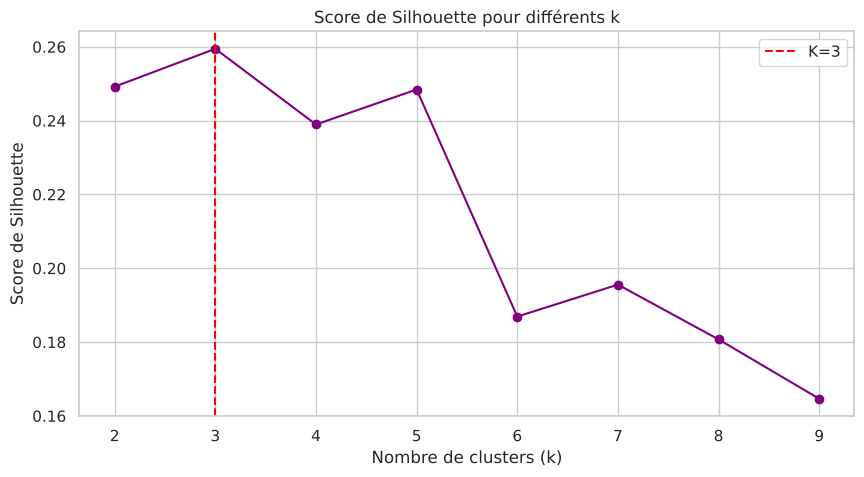

Score pour K=3 : 0.259
Interpretation : La structure est présente mais les groupes se touchent un peu.


In [49]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
print("\n--- Calcul du Score de Silhouette ---")
silhouette_scores = []
K_range_sil = range(2, 10) # Silhouette n'existe pas pour K=1

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_projected[:, :n_components_80])
    score = silhouette_score(X_projected[:, :n_components_80], labels)
    silhouette_scores.append(score)

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(K_range_sil, silhouette_scores, 'bo-', color='purple')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette')
plt.title('Score de Silhouette pour différents k')
plt.grid(True)
plt.axvline(x=3, color='red', linestyle='--', label='K=3') # Pour montrer ton choix
plt.legend()
plt.show()

# Affichage du score précis pour K=3
print(f"Score pour K=3 : {silhouette_scores[1]:.3f}")
if silhouette_scores[1] > 0.5:
    print("Interpretation : La structure est solide et bien définie.")
elif silhouette_scores[1] > 0.25:
    print("Interpretation : La structure est présente mais les groupes se touchent un peu.")
else:
    print("Interpretation : Les groupes se chevauchent beaucoup.")


--- Visualisation des 6 premières itérations pour K=3 ---


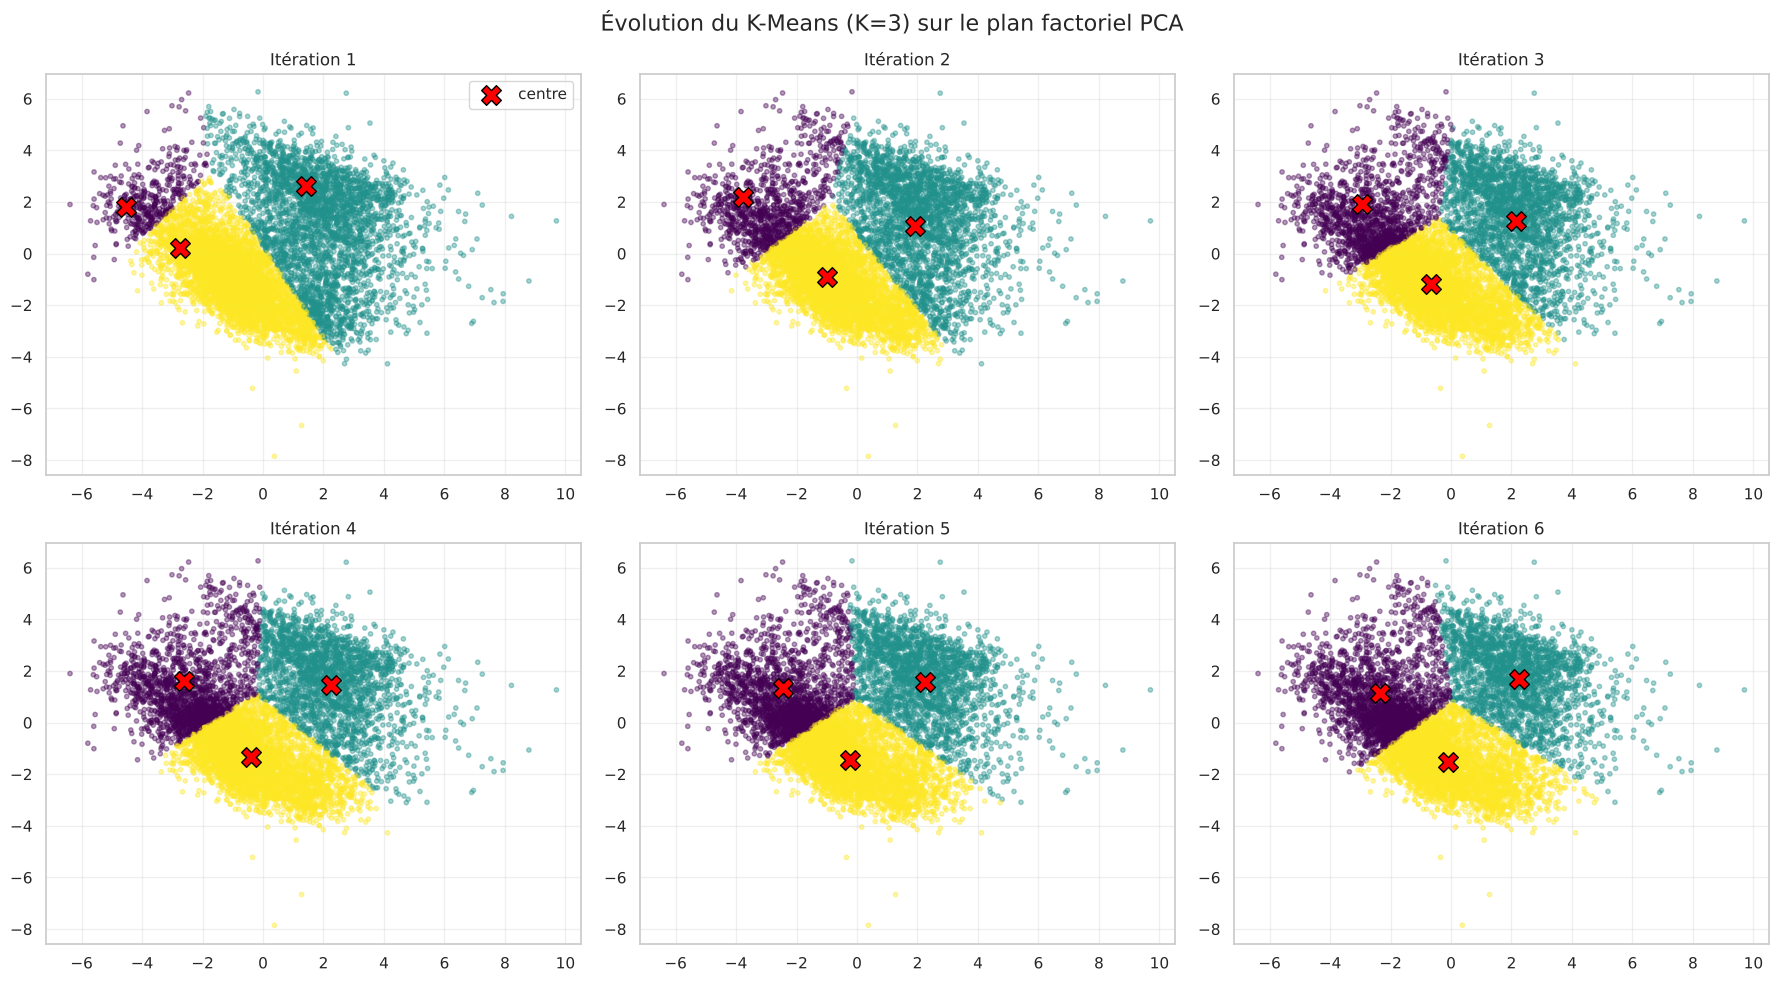


--- Résultat Final ---
Cluster
0    4376
1    1846
2    1772
Name: count, dtype: int64


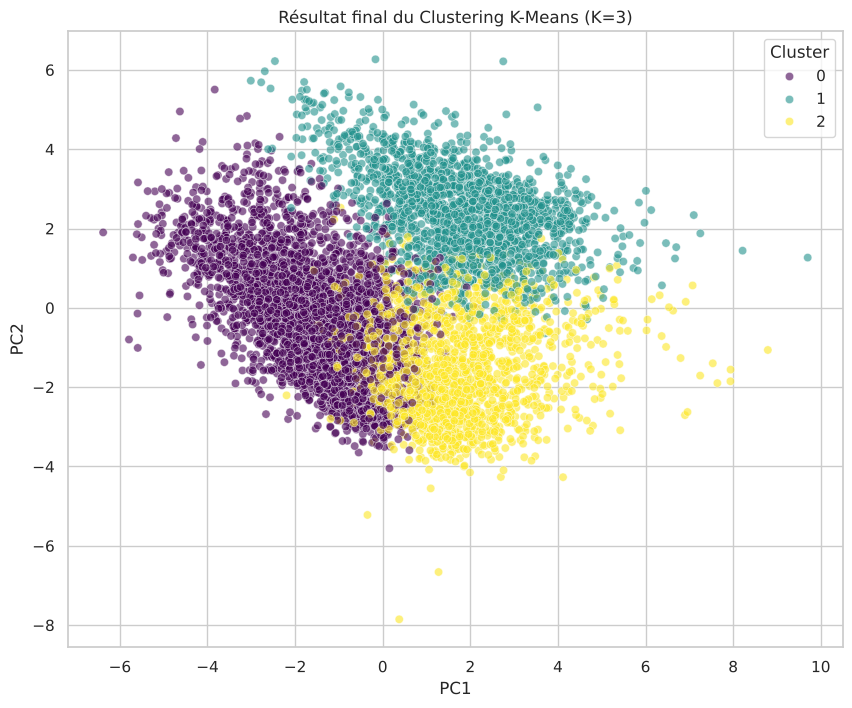

In [50]:
from scipy.spatial.distance import cdist

# On travaille sur les 2 premières composantes principales pour la visualisation 2D
X_pca = X_projected[:, :2]

# nombre de cluster déerminé juste avant
K = 3 
MAX_ITER = 6  # Nombre d'itérations à afficher

# Initialisation aléatoire des centre
np.random.seed(42)
idx = np.random.choice(len(X_pca), K, replace=False) #met les point de facon random
centroids = X_pca[idx, :]

# Préparation de la grille de graphiques
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

print(f"\n--- Visualisation des {MAX_ITER} premières itérations pour K={K} ---")

for i in range(MAX_ITER):
    # 1. Calcul des distances entre chaque point et les centre
    distances = cdist(X_pca, centroids, 'euclidean')
    
    # 2. Attribution des points au centre le plus proche (Labels)
    labels = np.argmin(distances, axis=1)
    
    # 3. Affichage
    ax = axes[i]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=10, cmap='viridis', alpha=0.4)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', edgecolors='black', label='centre')
    
    ax.set_title(f"Itération {i+1}")
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend()

    # 4. Mise à jour des centre (Calcul de la moyenne des points du cluster)
    new_centroids = []
    for k in range(K):
        # Si le cluster n'est pas vide, on prend la moyenne
        if np.sum(labels == k) > 0:
            new_centroids.append(X_pca[labels == k].mean(axis=0))
        else:
            # Si un cluster est vide (rare), on garde l'ancien centre
            new_centroids.append(centroids[k])
    
    new_centroids = np.array(new_centroids)
    
    # Vérification de convergence (si les centre ne bougent plus)
    if np.allclose(centroids, new_centroids):
        print(f"--> Convergence atteinte à l'itération {i+1} !")
        # On cache les graphiques vides restants si ça converge vite
        for j in range(i + 1, MAX_ITER):
            fig.delaxes(axes[j])
        break
        
    centroids = new_centroids

plt.suptitle(f'Évolution du K-Means (K={K}) sur le plan factoriel PCA', fontsize=16)
plt.tight_layout()
plt.show()

#modele final avec sklearn, le code avant ct pour voir les premières itérations
final_kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
df_final['Cluster'] = final_kmeans.fit_predict(X_projected[:, :n_components_80]) # On peut clusteriser sur toutes les PC retenues

print("\n--- Résultat Final ---")
print(df_final['Cluster'].value_counts())

# Visualisation finale propre
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_final, palette='viridis', alpha=0.6)
plt.title(f'Résultat final du Clustering K-Means (K={K})')
plt.show()


--- Comparaison Clusters vs Réalité ---
koi_disposition  CANDIDATE  CONFIRMED  FALSE POSITIVE
Cluster                                              
0                     1669       2222             485
1                       68         39            1739
2                       55         20            1697


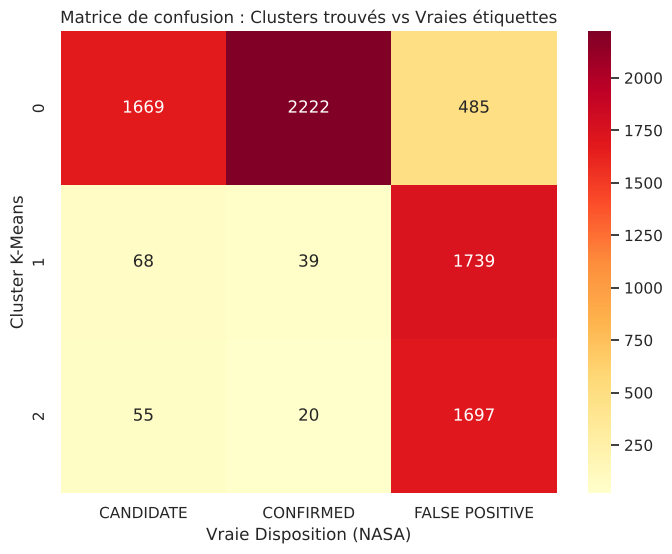

In [51]:
# Comparaison : Est-ce que les Clusters K-Means matchent les vraies catégories ?
print("\n--- Comparaison Clusters vs Réalité ---")
crosstab = pd.crosstab(df_final['Cluster'], df_final['koi_disposition'])
print(crosstab)

# Visualisation rapide
plt.figure(figsize=(8,6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Matrice de confusion : Clusters trouvés vs Vraies étiquettes')
plt.ylabel('Cluster K-Means')
plt.xlabel('Vraie Disposition (NASA)')
plt.show()

**-----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# **FCA**

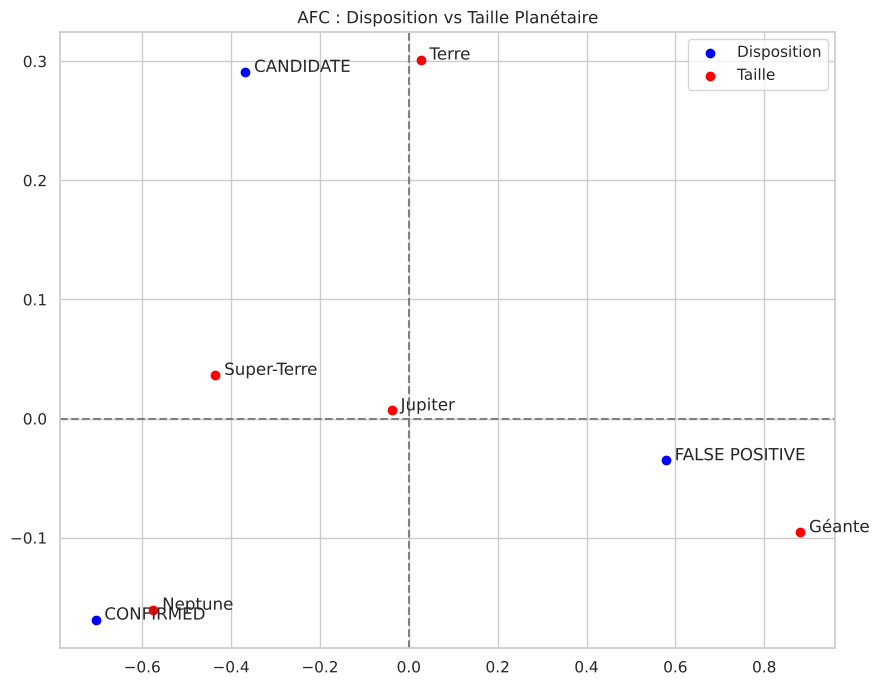

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Préparation
df = pd.read_csv('../data/cumulative_cleaned.csv')

# Création des catégories de taille (Discrétisation)
bins = [0, 1.25, 2, 6, 15, 100000]
labels = ['Terre', 'Super-Terre', 'Neptune', 'Jupiter', 'Géante']
df['Taille'] = pd.cut(df['koi_prad'], bins=bins, labels=labels)

# Tableau de Contingence
cont_table = pd.crosstab(df['koi_disposition'], df['Taille'])

# 2. Calcul Manuel de l'AFC (SVD sur les résidus standardisés)
N = cont_table.values
P = N / N.sum()
r = P.sum(axis=1)
c = P.sum(axis=0)
S = np.diag(1/np.sqrt(r)) @ (P - np.outer(r, c)) @ np.diag(1/np.sqrt(c))

U, s, Vt = np.linalg.svd(S, full_matrices=False)

# Coordonnées
row_coords = np.diag(1/np.sqrt(r)) @ U @ np.diag(s)
col_coords = np.diag(1/np.sqrt(c)) @ Vt.T @ np.diag(s)

# 3. Affichage
plt.figure(figsize=(10, 8))
plt.scatter(row_coords[:, 0], row_coords[:, 1], c='blue', label='Disposition')
plt.scatter(col_coords[:, 0], col_coords[:, 1], c='red', label='Taille')

for i, txt in enumerate(cont_table.index):
    plt.annotate(txt, (row_coords[i, 0]+0.02, row_coords[i, 1]))
for i, txt in enumerate(cont_table.columns):
    plt.annotate(txt, (col_coords[i, 0]+0.02, col_coords[i, 1]))

plt.title("AFC : Disposition vs Taille Planétaire")
plt.axhline(0, color='grey', ls='--')
plt.axvline(0, color='grey', ls='--')
plt.legend()
plt.show()

![image.png](attachment:image.png)

Interprétation du Graphique :

L'Axe Horizontal (Dimension 1 - 92.5%) :

Il sépare très nettement les FALSE POSITIVE (à droite) des CONFIRMED (à gauche).
La catégorie "Géante" est extrêmement proche de "FALSE POSITIVE". Cela confirme que les objets détectés comme "trop gros" (> 15 rayons terrestres) sont presque systématiquement des erreurs (probablement des étoiles binaires à éclipses).


L'Association Forte :

Les catégories "Super-Terre" et "Neptune" sont très proches du statut CONFIRMED. C'est dans cette gamme de taille que la mission Kepler a été la plus performante pour valider de vraies planètes.
Les planètes de taille "Terre" sont situées à mi-chemin entre Candidat et Faux Positif, reflétant la difficulté de confirmer les plus petits signaux (souvent noyés dans le bruit).


Cette analyse confirme visuellement que la taille de l'objet détecté est un excellent prédicteur de sa nature réelle (planète ou erreur).

L'analyse factorielle (AFC) croisant la Taille des planètes et la Disposition se révèle être la plus pertinente car elle met en évidence le discriminant physique le plus puissant de la mission Kepler, avec une inertie totale de 0.364 (bien supérieure aux autres variables). Cette performance s'explique par la nature même des méthodes de détection : le premier axe factoriel, qui capture 92,4 % de l'information, illustre une séparation quasi-parfaite entre les objets "Géants" (rayon > 15 R 
⊕
​	
 ), qui s'avèrent être majoritairement des Faux Positifs causés par des étoiles binaires à éclipses, et les objets de taille "Terre" ou "Neptune", qui constituent l'essentiel des planètes Confirmées. En somme, la taille est le filtre le plus efficace pour distinguer une erreur astrophysique d'une véritable exoplanète.

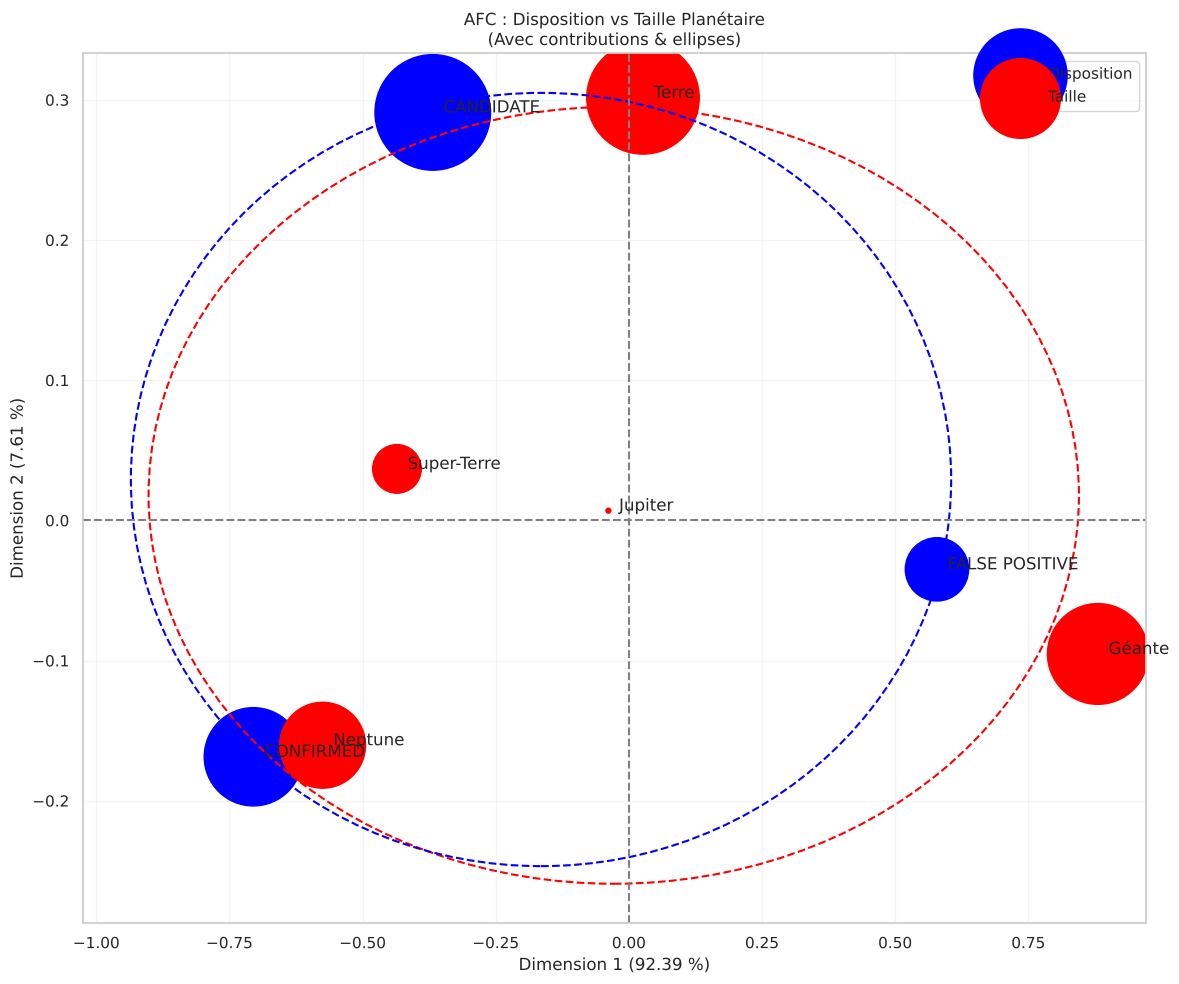

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# -------------------------------
# 1) Préparation des données
# -------------------------------

df = pd.read_csv('../data/cumulative_cleaned.csv')

# Discrétisation des tailles
bins = [0, 1.25, 2, 6, 15, 100000]
labels = ['Terre', 'Super-Terre', 'Neptune', 'Jupiter', 'Géante']
df['Taille'] = pd.cut(df['koi_prad'], bins=bins, labels=labels)

# Tableau de contingence
cont_table = pd.crosstab(df['koi_disposition'], df['Taille'])

# -------------------------------
# 2) AFC (SVD)
# -------------------------------

N = cont_table.values
P = N / N.sum()
r = P.sum(axis=1)
c = P.sum(axis=0)
S = np.diag(1 / np.sqrt(r)) @ (P - np.outer(r, c)) @ np.diag(1 / np.sqrt(c))

U, s, Vt = np.linalg.svd(S, full_matrices=False)

# Coordonnées
row_coords = np.diag(1 / np.sqrt(r)) @ U @ np.diag(s)
col_coords = np.diag(1 / np.sqrt(c)) @ Vt.T @ np.diag(s)

# Variance expliquée
eig = s**2
explained = eig / eig.sum() * 100
dim1, dim2 = explained[0], explained[1]

# Contributions (Option visuelle)
row_ctr = (row_coords[:, :2]**2 / eig[:2]).sum(axis=1)
col_ctr = (col_coords[:, :2]**2 / eig[:2]).sum(axis=1)

# -------------------------------
# 3) Tracé graphique
# -------------------------------

plt.figure(figsize=(12, 10))

# Points des dispositions (bleu)
plt.scatter(row_coords[:, 0], row_coords[:, 1], s=row_ctr*2000, c='blue', label="Disposition")

# Points tailles (rouge)
plt.scatter(col_coords[:, 0], col_coords[:, 1], s=col_ctr*2000, c='red', label="Taille")

# -------------------------------
# Ellipses d'aide à la lecture
# -------------------------------
def draw_ellipse(x, y, color):
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=np.ptp(x)*1.2,
        height=np.ptp(y)*1.2,
        edgecolor=color,
        facecolor='none',
        linestyle='--',
        linewidth=1.5
    )
    plt.gca().add_patch(ellipse)

# Ellipse catégories de taille
draw_ellipse(col_coords[:, 0], col_coords[:, 1], "red")
# Ellipse catégories de disposition
draw_ellipse(row_coords[:, 0], row_coords[:, 1], "blue")

# -------------------------------
# Labels
# -------------------------------
for i, txt in enumerate(cont_table.index):
    plt.annotate(txt, (row_coords[i, 0] + 0.02, row_coords[i, 1]))

for i, txt in enumerate(cont_table.columns):
    plt.annotate(txt, (col_coords[i, 0] + 0.02, col_coords[i, 1]))

# Axes et titre
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel(f"Dimension 1 ({dim1:.2f} %)")
plt.ylabel(f"Dimension 2 ({dim2:.2f} %)")
plt.title("AFC : Disposition vs Taille Planétaire\n(Avec contributions & ellipses)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


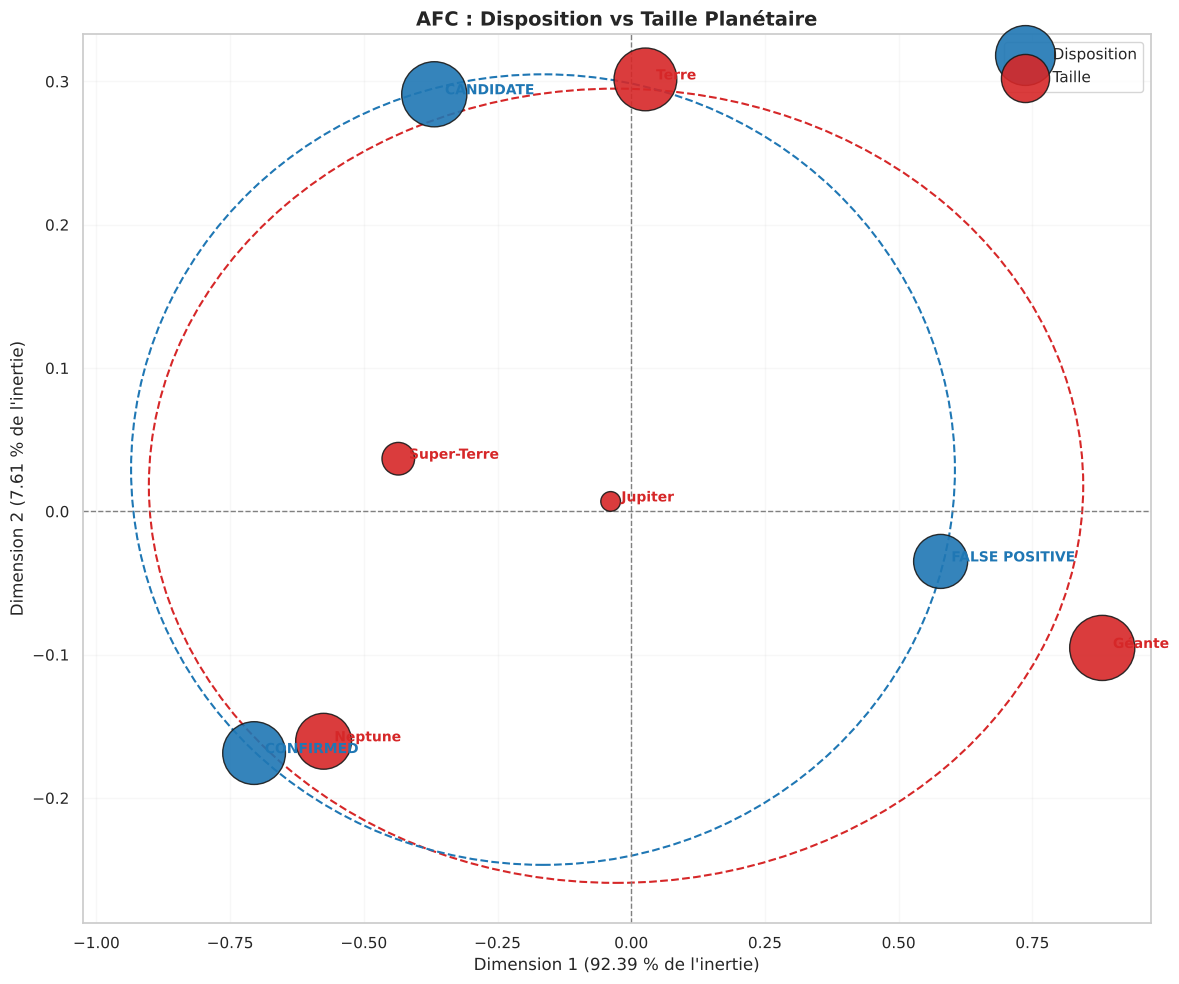

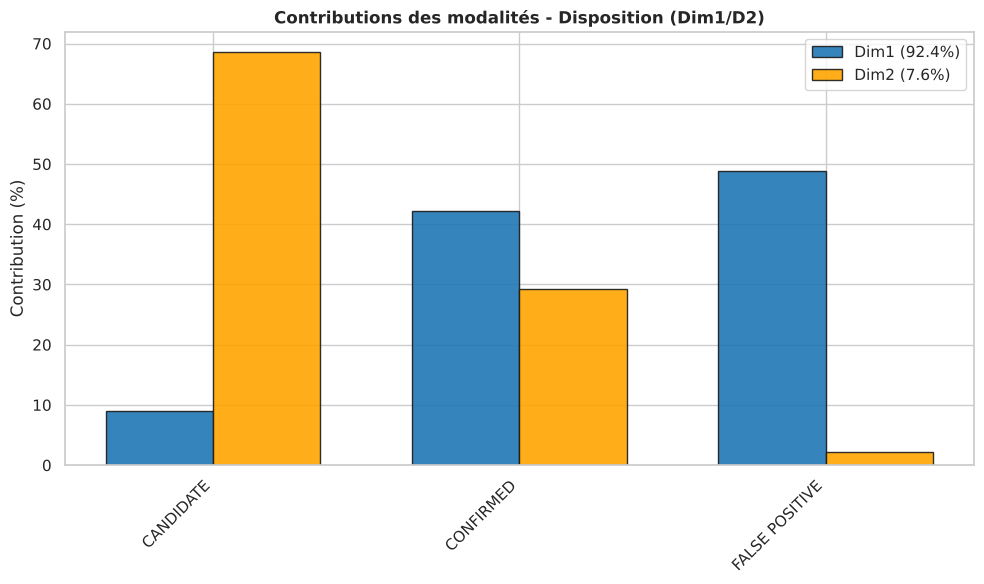

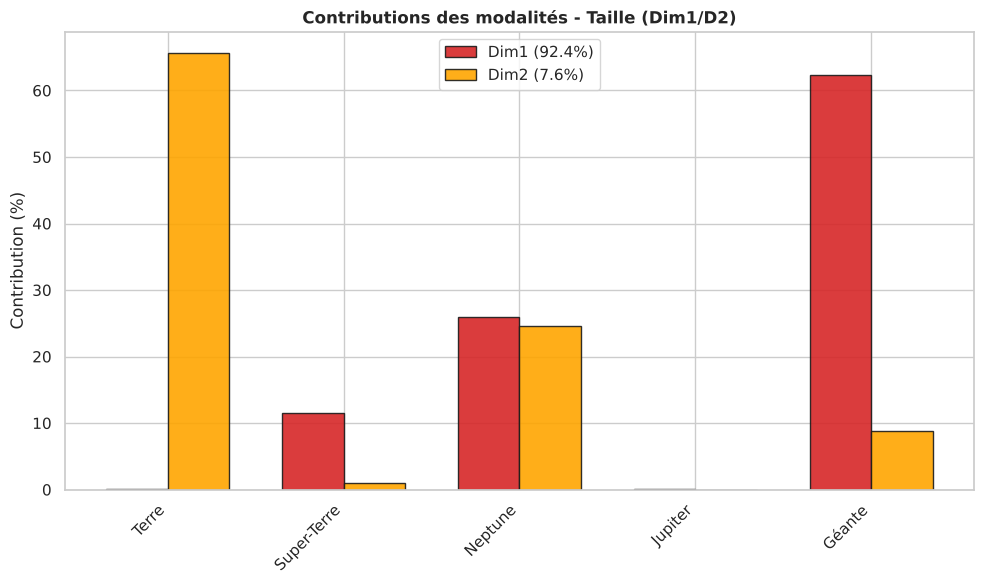

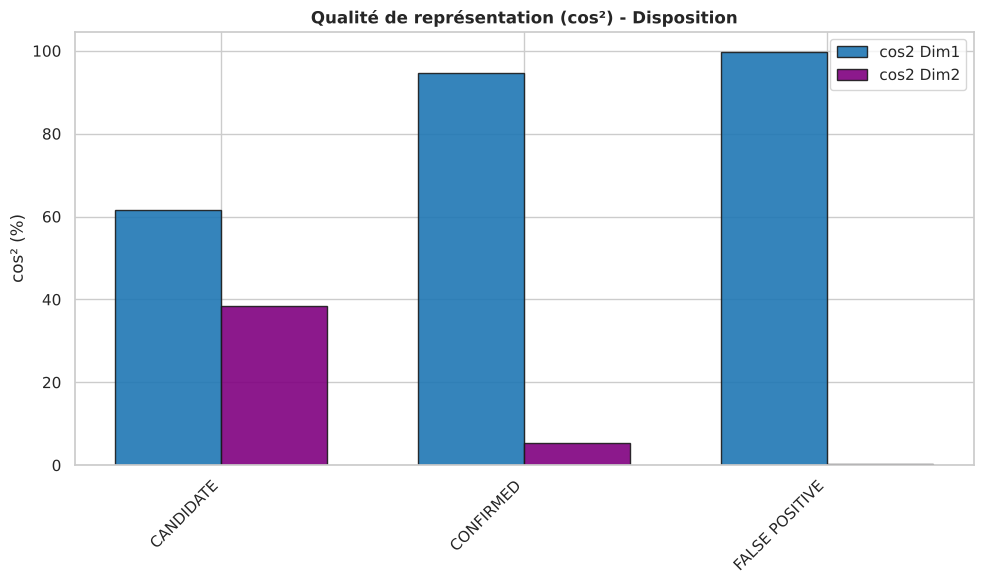

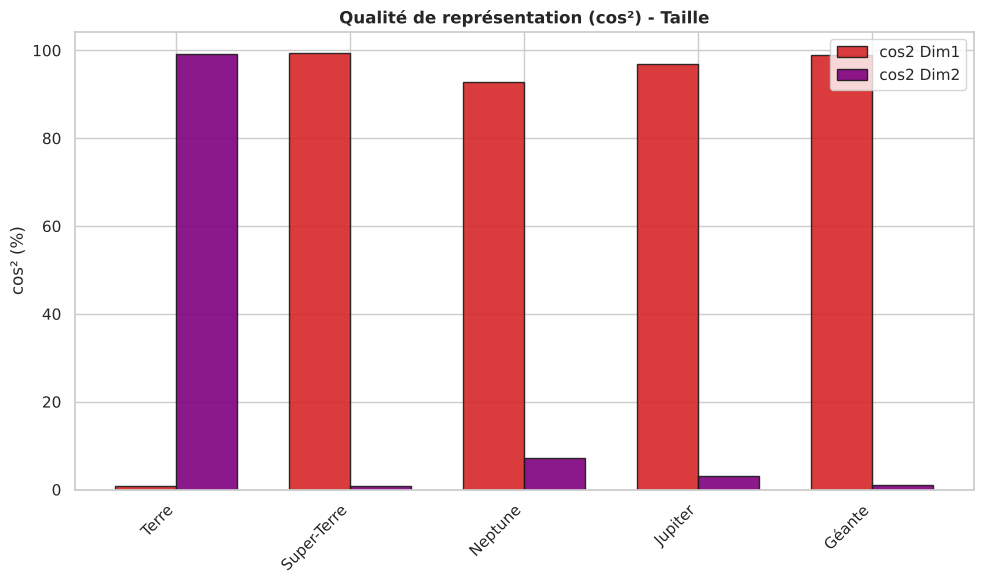

=== Terminé ===
Fichiers sauvegardés dans : ../output/afc_results
Exemples de fichiers : afc_biplot_styleB.png, contrib_disposition.png, contrib_taille.png, cos2_disposition.png, interpretation_disposition_to_taille.csv


In [54]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# === Paramètres ===
INPUT_CSV = '../data/cumulative_cleaned.csv'
OUT_DIR = '../output/afc_results'
os.makedirs(OUT_DIR, exist_ok=True)
DPI = 300

# === 1) Préparation ===
df = pd.read_csv(INPUT_CSV)

# Discrétisation des tailles
bins = [0, 1.25, 2, 6, 15, 100000]
labels = ['Terre', 'Super-Terre', 'Neptune', 'Jupiter', 'Géante']
df['Taille'] = pd.cut(df['koi_prad'], bins=bins, labels=labels)

# Table de contingence
cont_table = pd.crosstab(df['koi_disposition'], df['Taille'])

# === 2) AFC (SVD sur résidus standardisés) ===
N = cont_table.values.astype(float)
P = N / N.sum()
r = P.sum(axis=1)           # masses lignes
c = P.sum(axis=0)           # masses colonnes

# matrice des résidus standardisés
S = np.diag(1/np.sqrt(r)) @ (P - np.outer(r, c)) @ np.diag(1/np.sqrt(c))

U, s, Vt = np.linalg.svd(S, full_matrices=False)

# coordonnées principales (axes factoriels)
row_coords = np.diag(1/np.sqrt(r)) @ U @ np.diag(s)
col_coords = np.diag(1/np.sqrt(c)) @ Vt.T @ np.diag(s)

# inerties et variance expliquée
eig = s**2
explained = eig / eig.sum() * 100
dim1, dim2 = explained[0], explained[1]

# === 3) Contributions (contrib) et cos2 (qualités) ===
# Contributions: pour une modalité j sur axe k -> (masse_j * coord_jk^2) / eig_k
# cos2: pour une modalité j sur axe k -> coord_jk^2 / (sum_l coord_jl^2)

# Lignes (Disposition)
row_sq = row_coords[:, :2] ** 2
row_dist2 = (row_coords[:, :2] ** 2).sum(axis=1)
# éviter division par 0
row_dist2[row_dist2 == 0] = 1e-12
row_cos2 = row_sq / row_dist2[:, None]   # cos2 sur dim1/dim2
row_contrib = np.zeros_like(row_coords[:, :2])
for k in range(2):
    row_contrib[:, k] = (r * (row_coords[:, k] ** 2)) / eig[k]

# Colonnes (Taille)
col_sq = col_coords[:, :2] ** 2
col_dist2 = (col_coords[:, :2] ** 2).sum(axis=1)
col_dist2[col_dist2 == 0] = 1e-12
col_cos2 = col_sq / col_dist2[:, None]
col_contrib = np.zeros_like(col_coords[:, :2])
for k in range(2):
    col_contrib[:, k] = (c * (col_coords[:, k] ** 2)) / eig[k]

# === 4) Table d'interprétation simple (proximité euclidienne sur 2 dims) ===
# Pour chaque disposition -> colonne la plus proche et distance
row_names = cont_table.index.tolist()
col_names = cont_table.columns.tolist()

interpret_rows = []
for i, name in enumerate(row_names):
    dists = np.linalg.norm(row_coords[i, :2] - col_coords[:, :2], axis=1)
    jmin = np.argmin(dists)
    interpret_rows.append({
        'Disposition': name,
        'Nearest_Taille': col_names[jmin],
        'Distance': float(dists[jmin])
    })

interpret_cols = []
for j, name in enumerate(col_names):
    dists = np.linalg.norm(col_coords[j, :2] - row_coords[:, :2], axis=1)
    imin = np.argmin(dists)
    interpret_cols.append({
        'Taille': name,
        'Nearest_Disposition': row_names[imin],
        'Distance': float(dists[imin])
    })

df_interpret_rows = pd.DataFrame(interpret_rows).sort_values('Distance')
df_interpret_cols = pd.DataFrame(interpret_cols).sort_values('Distance')

# Sauvegarde des tableaux
df_interpret_rows.to_csv(os.path.join(OUT_DIR, 'interpretation_disposition_to_taille.csv'), index=False)
df_interpret_cols.to_csv(os.path.join(OUT_DIR, 'interpretation_taille_to_disposition.csv'), index=False)

# === 5) Tracé principal (biplot) - style B (vif) ===
plt.figure(figsize=(12, 10))
ax = plt.gca()

# couleurs vives
color_rows = '#1f77b4'   # bleu
color_cols = '#d62728'   # rouge vif
alpha = 0.9

# tailles des points basées sur la contribution totale sur les 2 axes
row_size = row_contrib.sum(axis=1)
col_size = col_contrib.sum(axis=1)

# normaliser tailles pour l'affichage
row_size_scaled = 2000 * (row_size / row_size.max() + 0.1)
col_size_scaled = 2000 * (col_size / col_size.max() + 0.1)

# scatter
sc_r = ax.scatter(row_coords[:, 0], row_coords[:, 1], s=row_size_scaled, c=color_rows, label='Disposition', edgecolor='k', zorder=3, alpha=alpha)
sc_c = ax.scatter(col_coords[:, 0], col_coords[:, 1], s=col_size_scaled, c=color_cols, label='Taille', edgecolor='k', zorder=3, alpha=alpha)

# annotations (décalées pour lisibilité)
for i, txt in enumerate(row_names):
    ax.annotate(txt, (row_coords[i, 0] + 0.02, row_coords[i, 1]), fontsize=10, color=color_rows, weight='bold')

for i, txt in enumerate(col_names):
    ax.annotate(txt, (col_coords[i, 0] + 0.02, col_coords[i, 1]), fontsize=10, color=color_cols, weight='bold')

# ellipses (aide visuelle)
def draw_ellipse(x, y, color):
    center = (np.mean(x), np.mean(y))
    width = np.ptp(x) * 1.2 if np.ptp(x) > 0 else 0.1
    height = np.ptp(y) * 1.2 if np.ptp(y) > 0 else 0.1
    e = Ellipse(xy=center, width=width, height=height,
                edgecolor=color, facecolor='none', linestyle='--', linewidth=1.5, zorder=2)
    ax.add_patch(e)

draw_ellipse(col_coords[:, 0], col_coords[:, 1], color_cols)
draw_ellipse(row_coords[:, 0], row_coords[:, 1], color_rows)

# lignes axes
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)

# labels axes avec variance expliquée
ax.set_xlabel(f"Dimension 1 ({dim1:.2f} % de l'inertie)")
ax.set_ylabel(f"Dimension 2 ({dim2:.2f} % de l'inertie)")
ax.set_title("AFC : Disposition vs Taille Planétaire", fontsize=14, weight='bold')

ax.legend(frameon=True)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'afc_biplot_styleB.png'), dpi=DPI)
plt.show()

# === 6) Plots contributions (barplots) ===
# On représente contribution par modalité sur les deux axes (somme ou séparé par axe)
def plot_contrib(names, contrib_matrix, title, filename, color):
    # contrib_matrix shape = (n_modalities, 2) for dim1/dim2
    ind = np.arange(len(names))
    width = 0.35

    plt.figure(figsize=(10, 6))
    # dim1
    plt.bar(ind - width/2, contrib_matrix[:, 0]*100, width, label=f'Dim1 ({explained[0]:.1f}%)', color=color, alpha=0.9, edgecolor='k')
    # dim2
    plt.bar(ind + width/2, contrib_matrix[:, 1]*100, width, label=f'Dim2 ({explained[1]:.1f}%)', color='orange', alpha=0.9, edgecolor='k')

    plt.xticks(ind, names, rotation=45, ha='right')
    plt.ylabel('Contribution (%)')
    plt.title(title, fontsize=12, weight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=DPI)
    plt.show()

plot_contrib(row_names, row_contrib, 'Contributions des modalités - Disposition (Dim1/D2)', 'contrib_disposition.png', color_rows)
plot_contrib(col_names, col_contrib, 'Contributions des modalités - Taille (Dim1/D2)', 'contrib_taille.png', color_cols)

# === 7) Plots cos2 (qualités de représentation) ===
def plot_cos2(names, cos2_matrix, title, filename, color):
    # cos2_matrix shape = (n_modalities, 2)
    ind = np.arange(len(names))
    width = 0.35
    plt.figure(figsize=(10, 6))
    plt.bar(ind - width/2, cos2_matrix[:, 0]*100, width, label='cos2 Dim1', color=color, edgecolor='k', alpha=0.9)
    plt.bar(ind + width/2, cos2_matrix[:, 1]*100, width, label='cos2 Dim2', color='purple', edgecolor='k', alpha=0.9)
    plt.xticks(ind, names, rotation=45, ha='right')
    plt.ylabel('cos² (%)')
    plt.title(title, fontsize=12, weight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=DPI)
    plt.show()

plot_cos2(row_names, row_cos2, 'Qualité de représentation (cos²) - Disposition', 'cos2_disposition.png', color_rows)
plot_cos2(col_names, col_cos2, 'Qualité de représentation (cos²) - Taille', 'cos2_taille.png', color_cols)

# === 8) Sauvegarde des matrices / résultats numériques utiles ===
# DataFrames pour sauvegarde
df_row_coords = pd.DataFrame(row_coords[:, :2], columns=['Dim1', 'Dim2'], index=row_names)
df_row_coords['mass'] = r
df_row_coords['contrib_dim1'] = row_contrib[:, 0]
df_row_coords['contrib_dim2'] = row_contrib[:, 1]
df_row_coords['cos2_dim1'] = row_cos2[:, 0]
df_row_coords['cos2_dim2'] = row_cos2[:, 1]

df_col_coords = pd.DataFrame(col_coords[:, :2], columns=['Dim1', 'Dim2'], index=col_names)
df_col_coords['mass'] = c
df_col_coords['contrib_dim1'] = col_contrib[:, 0]
df_col_coords['contrib_dim2'] = col_contrib[:, 1]
df_col_coords['cos2_dim1'] = col_cos2[:, 0]
df_col_coords['cos2_dim2'] = col_cos2[:, 1]

df_row_coords.to_csv(os.path.join(OUT_DIR, 'row_coords_and_stats.csv'))
df_col_coords.to_csv(os.path.join(OUT_DIR, 'col_coords_and_stats.csv'))

# On a déjà sauvegardé les tables d'interprétation plus haut.

print("=== Terminé ===")
print(f"Fichiers sauvegardés dans : {OUT_DIR}")
print("Exemples de fichiers : afc_biplot_styleB.png, contrib_disposition.png, contrib_taille.png, cos2_disposition.png, interpretation_disposition_to_taille.csv")



Les histogrammes de contribution permettent d’identifier quelles modalités influencent le plus la construction des deux premiers axes factoriels. On observe que certaines catégories tirent fortement la structure du plan, notamment False Positive et Confirmed du côté des dispositions, ainsi que les classes Géante et Neptune du côté des tailles planétaires. Ces modalités possèdent un profil statistique très différent des autres, ce qui explique leur contribution élevée. À l’inverse, les modalités plus centrales, comme Super-Terre ou parfois Candidate, impactent moins la géométrie du nuage, car elles se rapprochent davantage de la moyenne globale.

Les graphiques de cos² indiquent à quel point chaque modalité est bien représentée sur le plan formé par les dimensions 1 et 2. Plus le cos² est élevé, plus la position de la modalité sur le graphique est fiable pour l’interprétation. On constate que les extrémités comme False Positive et Géante ont des cos² élevés, ce qui est cohérent avec le fait qu’elles soient situées loin du centre : ces modalités expriment donc clairement leur profil sur ces deux dimensions. Au contraire, Super-Terre et Jupiter présentent un cos² plus faible, suggérant qu’une part de leur information statistique se trouve dans des dimensions non affichées.

Les tableaux d’interprétation renseignent les associations les plus fortes entre modalités des deux variables. Par exemple, les dispositions Candidate sont spatialement les plus proches des planètes de type Terre, révélant que ces candidats sont majoritairement de petite taille ou associées à des signaux faibles. À l’opposé, les False Positive se rapprochent des Géantes, ce qui illustre un effet de signal trop fort ou parasité conduisant à des fausses détections. Ces rapprochements géométriques confirment visuellement des tendances astrophysiques connues dans la détection d’exoplanètes.

**-----------------------------------------------------------------------------------------------------------------------------------------------------------------**

# **CCA**